# Internship report figures — *Financial contagion in networks*

A **clean, self-contained** notebook that (re)generates every report figure in **high resolution**
(vector PDF for LaTeX + 300 dpi PNG for preview), saved into `Fig/rapport/`.

It relies on the `code/` package (loading, crisis detection, SIS fits — all cached in `cache/`),
so execution is near-instant.

| § report | Figure | File |
|----------|--------|------|
| 1.1 | Correlation heatmap (ordered by sector) | `fig_1_1_heatmap_correlations` |
| 1.1 | Variant: all asset classes (stocks + crypto + ETF) | `fig_1_1_heatmap_correlations_multi` |
| 1.2 | Scale-free network: degree distribution (crisis vs calm) | `fig_1_2_scalefree_degres` |
| 2.1 | VAR(1) matrices: real vs nulls (i.i.d., phase-randomized) | `fig_2_1_matrices_var` |
| 2.1 | Eigenvalue distribution of the VAR(1) matrices | `fig_2_1_eigenvalues` |
| 2.1 | R² of the different models (real vs nulls) | `fig_2_1_R2_modeles` |
| 2.2 | Lag selection: BIC and in-sample R² | `fig_2_2_bic_lag` |
| 2.2 | VAR link stability over time (recurrence vs chance) | `fig_2_8_stabilite_var` |
| 2.2 | VAR(13) contagion matrices per sub-period (mosaic) | `fig_2_9_matrices_var_chunks` |
| 2.2 | Per-asset stability: node roles persist | `fig_2_10_stabilite_roles`, `tab_2_10_stabilite_roles` |
| 2.4 | Lag interpretation: sectors (30 min) vs geography (1 day) | `fig_2_4_lag_communautes` |
| 2.4 | VAR network on the whole series | `fig_2_5_var_net` |
| 2.4 | Recurrent VAR links (lag 13, lag 1) | `fig_2_6_liens_recurrents`, `fig_2_7_liens_recurrents_lag1` |
| 3   | Crisis detection (windows on the mean correlation) | `fig_2_0_crisis_detection` |
| 3   | SIS model: predicted x_i vs empirical E_i (4 methods) | `fig_3_sis_scatter` |
| 3   | SIS model: median trajectories E_i / x_i | `fig_3_sis_trajectoires` |
| 3   | (B, R) scan: aggregated R² | `fig_3_br_scan_r2agg` |
| 4.1 | Average clustering over time (scale-free threshold) | `fig_4_1_clustering_crises`, `tab_4_1_clustering_periods` |
| 4.2 | Network signals vs mean return | `fig_4_2_network_signals` |
| 4.3 | (B, R) grid: aggregated R² of the selected fits | `fig_4_3_br_grid_methods` |
| 4.4 | Off-crisis null: SIS outside collective crises | `fig_4_4_sis_off_crisis`, `fig_4_4b_r2_hist_offcrisis`, `tab_4_4_sis_off_crisis` |
| 4.5 | Assets retained per method × period, agreement | `fig_4_5_method_agreement`, `tab_4_5_method_agreement` |
| 4.6 | Louvain communities: are crisis assets grouped? | `fig_4_6_community_crisis_ratio`, `fig_4_7_community_graphs`, `tab_4_6_communities` |
| 4.7 | Endo/exo score per period (branching ratio) | `fig_4_8_endo_exo`, `tab_4_8_endo_exo`, `fig_4_8c_n_vs_sis_crisis` |
| 4.8 | Falsifiability tests A / B / C | `fig_4_9_falsifiability_testA`, `fig_4_10_falsifiability_testB`, `fig_4_11_testC_counts`, `fig_4_11_testC_meanR2`, `tab_4_9_testA`, `tab_4_10_testB`, `tab_4_11_testC` |
| 4.9 | Null: crisis-asset swap (derangement) | `fig_4_12_null_swap`, `tab_4_12_null_swap` |
| A | Sparse VAR: edge activation frequency across chunks | `fig_A1_sparse_var_activation` |


## 0. Setup — loading, HD style, save helper

In [1]:
import sys, warnings
sys.path.insert(0, 'code')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import linregress

# ── "Publication" style: readable font, clean vector output ───────────────────
plt.rcParams.update({
    'figure.dpi': 110,            # on-screen preview
    'savefig.dpi': 300,           # high-resolution PNG
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,           # editable (TrueType) fonts in the PDF
    'ps.fonttype': 42,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.constrained_layout.use': False,
})

# ── Output folder + dual-format save ──────────────────────────────────────────
RAPPORT_DIR = Path('Fig') / 'rapport'
RAPPORT_DIR.mkdir(parents=True, exist_ok=True)
_saved = []

def save(fig, name):
    """Save `fig` as PDF (vector) and 300 dpi PNG into Fig/rapport/."""
    for ext in ('pdf', 'png'):
        p = RAPPORT_DIR / f'{name}.{ext}'
        fig.savefig(p, dpi=300, bbox_inches='tight')
    _saved.append(name)
    print(f'  done {name}.pdf  +  {name}.png')

print('Output:', RAPPORT_DIR.resolve())


Output: /home/farmachidi/projects/contagion_stock_markets/Fig/rapport


In [2]:
# ── Data + pipeline (cached) ──────────────────────────────────────────────────
from data import build_context
import pipeline, selection, config

ctx = build_context()                       # returns + A matrices + caches
real = ctx.data                             # same DataFrame (T x N), sorted by sector
asset_names = ctx.asset_names
N = ctx.N
arr = real.values

# Sectors (the data is already sorted by sector)
sectors_df = pd.read_excel('data/stock_category.xlsx')
sector_map = sectors_df.set_index('Stocks')['Sectors'].to_dict()
sector_arr = np.array([sector_map.get(a, 'other') for a in asset_names])

# Geographic zones (taken from validation.ipynb)
GEO_MAP = {
    **{t: 'United States' for t in [
        'AMZN','BKNG','COST','DIS','HD','IDEX','LOW','MCD','NKE','NVR','SBUX','TJX','TSLA',
        'EL','GE','HON','ITW','KO','MDLZ','MO','PEP','PG','PM','WMT',
        'BKR','COP','CVX','EOG','SLB','XOM',
        'AXP','BAC','BLK','BX','C','CB','GS','JPM','MC','MMC','MS','SCHW','WFC',
        'ABBV','ABT','AMGN','BDX','BMY','BSX','CI','CVS','DHR','ELV','GILD',
        'HCA','ISRG','JNJ','LLY','MDT','MRK','PFE','SYK','TMO','UNH','VRTX','ZTS',
        'BA','CAT','DE','ETN','LMT','PYPL','UNP','UPS',
        'AAPL','ACN','ADBE','ADI','ADP','AMAT','AMD','AVGO','CMCSA','CRM','CSCO',
        'GOOG','IBM','INTC','INTU','LRCX','MA','META','MSFT','MU','NFLX','NOW',
        'NVDA','ORCL','PANW','QCOM','T','TMUS','TXN','V','VZ',
        'LIN','AMT','PLD','DTE','NEE','SO']},
    **{t: 'Japan' for t in ['TM', 'SONY', 'MUFG']},
    **{t: 'Europe' for t in [
        'AZN','BP','SHEL','UL','DEO','HSBC','BTI',
        'ALV','NVS','ABB','TTE','SNY','NVO','EQNR','ASML','SAP','AIR','BUD','CFR']},
    **{t: 'Asia-Pacific' for t in ['TSM','ASX','IBN','HDB','BABA','PDD','BHP','CSL']},
    **{t: 'Americas' for t in ['TD','CNI','CP','SHOP','PBR']},
}
geo_arr = np.array([GEO_MAP.get(a, 'United States') for a in asset_names])

GEO_COLORS = {'United States':'#4292c6','Europe':'#41ab5d','Japan':'#d62728',
              'Asia-Pacific':'#ff7f0e','Americas':'#9467bd'}

# Per-sector colors (stable qualitative palette)
_secs = sorted(set(sector_arr))
SECTOR_COLORS = {s: c for s, c in zip(_secs, sns.color_palette('tab20', len(_secs)))}

print(f'{N} assets, {len(real)} obs, {len(_secs)} sectors, {len(set(geo_arr))} geo zones.')


N = 146 actifs, T = 13360 obs ; 2019-04-01 10:00:00 -> 2023-05-03 15:30:00
[cache] OK  base
1031 jours ; <|C_ij|> moyen = 0.4686
146 assets, 13360 obs, 10 sectors, 5 geo zones.


## 1.1 — Correlation heatmap

Pearson correlation of the log-returns over the whole period, **assets ordered by sector**.
The diagonal blocks reveal that assets in the same sector co-move (high intra-sector correlation).

  done fig_1_1_heatmap_correlations.pdf  +  fig_1_1_heatmap_correlations.png


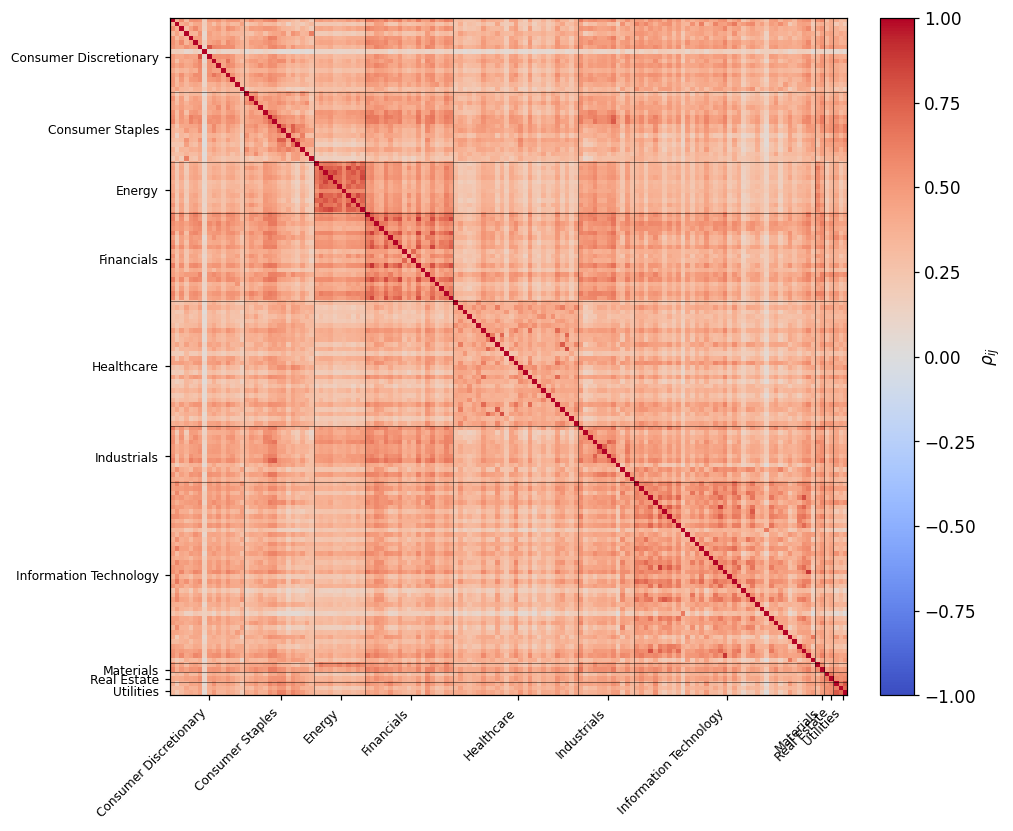

=== CAPTION [fig_1_1_heatmap_correlations] ===
Log-return correlations (146 stocks, ordered by sector)


In [3]:
C_signed = np.corrcoef(arr.T)          # signed full-period correlation

# Sector boundaries (columns are already sorted by sector)
bounds, labels, mids = [0], [], []
for i in range(1, N + 1):
    if i == N or sector_arr[i] != sector_arr[i - 1]:
        labels.append(sector_arr[i - 1]); mids.append((bounds[-1] + i) / 2); bounds.append(i)

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(C_signed, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
for b in bounds[1:-1]:
    ax.axhline(b - 0.5, color='k', lw=0.6, alpha=0.5)
    ax.axvline(b - 0.5, color='k', lw=0.6, alpha=0.5)
ax.set_xticks(mids); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(mids); ax.set_yticklabels(labels, fontsize=8)
ax.set_title(f'Log-return correlations ({N} stocks, ordered by sector)')
ax.grid(False)
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label(r'$\rho_{ij}$')
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_1_1_heatmap_correlations'); plt.show()
if _capt:
    print('=== CAPTION [fig_1_1_heatmap_correlations] ==='); print('\n'.join(_capt))


### Variant: all asset classes (stocks + crypto + ETF)

Same heatmap but **without sector grouping**, adding the **cryptocurrencies** and the **ETFs**
(merged on the common timestamps). Assets are grouped by class. Cryptos form a block strongly
correlated among themselves but weakly coupled to stocks, while ETFs (baskets of stocks) are
highly correlated with the stock block.

  done fig_1_1_heatmap_correlations_multi.pdf  +  fig_1_1_heatmap_correlations_multi.png


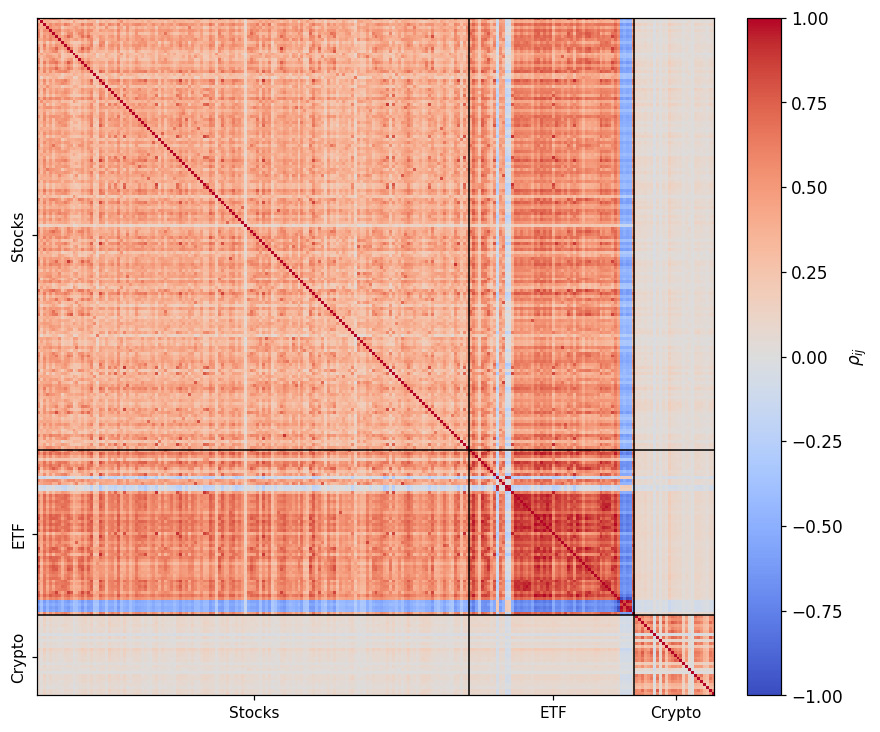

In [4]:
# Merge the three asset classes on the common timestamps (order: Stocks, ETF, Crypto)
ORDER = [('stock', 'Stocks'), ('etfs', 'ETF'), ('crypto', 'Crypto')]
_frames = {}
for cls, _ in ORDER:
    d = pd.read_csv(f'data/{cls}_filled.csv', parse_dates=['date'])
    d = d.drop(columns=[c for c in d.columns if c.startswith('Unnamed')])
    _frames[cls] = d
multi = _frames[ORDER[0][0]]
for cls, _ in ORDER[1:]:
    multi = multi.merge(_frames[cls], on='date', how='inner')
multi = multi.set_index('date')

# Class of each column (same order), no sector sorting
class_of, class_sizes = [], {}
for cls, lab in ORDER:
    cols = [c for c in _frames[cls].columns if c != 'date']
    class_of += [lab] * len(cols); class_sizes[lab] = len(cols)
class_of = np.array(class_of)

# Log-returns + correlation
ret = np.log(multi / multi.shift(1)).dropna()
C_multi = np.corrcoef(ret.values.T)
Nm = C_multi.shape[0]

# Per-class boundaries / labels
mb, mlabels, mmids = [0], [], []
for i in range(1, Nm + 1):
    if i == Nm or class_of[i] != class_of[i - 1]:
        mlabels.append(class_of[i - 1]); mmids.append((mb[-1] + i) / 2); mb.append(i)

fig, ax = plt.subplots(figsize=(9.5, 8))
im = ax.imshow(C_multi, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
for b in mb[1:-1]:
    ax.axhline(b - 0.5, color='k', lw=1.0); ax.axvline(b - 0.5, color='k', lw=1.0)
ax.set_xticks(mmids); ax.set_xticklabels(mlabels, fontsize=10)
ax.set_yticks(mmids); ax.set_yticklabels(mlabels, rotation=90, va='center', fontsize=10)
ax.grid(False)   # no title: caption handled in LaTeX
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04); cb.set_label(r'$\rho_{ij}$')
save(fig, 'fig_1_1_heatmap_correlations_multi'); plt.show()


## 1.2 — Scale-free network: degree distribution

We threshold the |C| matrix at a level ρc chosen to make the degree distribution convex
(*power-law* proxy, Achitouv's method). During a crisis (COVID) the thresholded network is
much denser and the tail of the distribution lengthens (hubs appear) compared to a calm period.

  done fig_1_2_scalefree_degres.pdf  +  fig_1_2_scalefree_degres.png


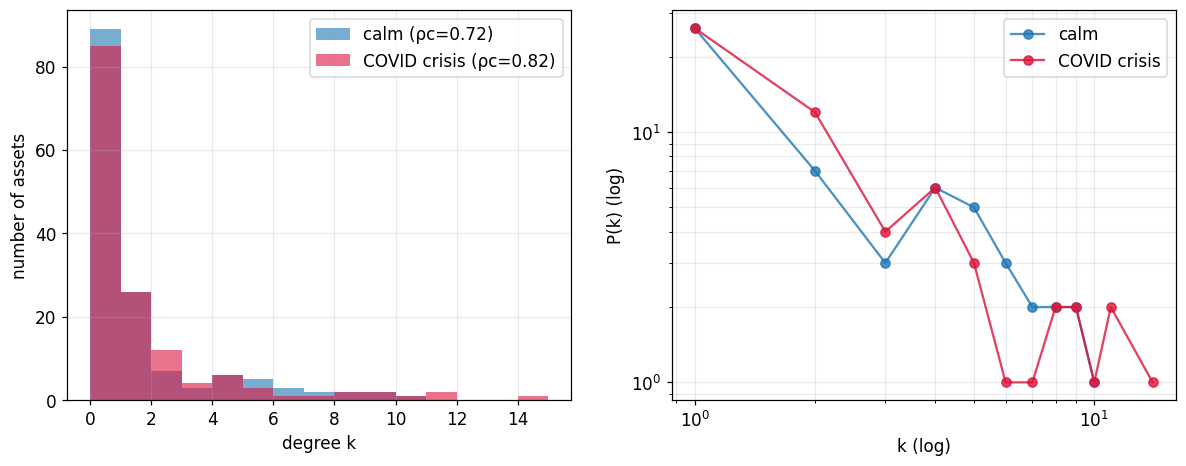

=== CAPTION [fig_1_2_scalefree_degres] ===
(a) Degree distribution at the scale-free threshold
(b) Degrees in log-log (power-law test)


In [5]:
def scale_free_threshold(C, start=0.5, step=0.01, cap=0.95):
    """Minimal ρc threshold making the degree distribution convex (Achitouv)."""
    rc = start
    while rc <= cap:
        A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); deg = A.sum(1)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9))
        if (kmax < 2) or np.all(np.diff(counts[:kmax + 1], 2) >= 0):
            return round(rc, 2)
        rc = round(rc + step, 2)
    return cap

idx = real.index
def corr_window(d0, d1):
    obs = (idx >= d0) & (idx <= d1)
    return np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T))

# COVID window (crash) vs calm 2021 window
C_crisis = corr_window(pd.Timestamp('2020-02-20'), pd.Timestamp('2020-04-15'))
C_calm   = corr_window(pd.Timestamp('2021-06-15'), pd.Timestamp('2021-07-25'))
rc_cr, rc_ca = scale_free_threshold(C_crisis), scale_free_threshold(C_calm)
def degrees(C, rc):
    A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); return A.sum(1)
d_cr, d_ca = degrees(C_crisis, rc_cr), degrees(C_calm, rc_ca)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.arange(0, max(d_cr.max(), d_ca.max()) + 2)
axL.hist(d_ca, bins=bins, alpha=0.6, color='tab:blue',  label=f'calm (ρc={rc_ca})')
axL.hist(d_cr, bins=bins, alpha=0.6, color='crimson',   label=f'COVID crisis (ρc={rc_cr})')
axL.set_xlabel('degree k'); axL.set_ylabel('number of assets')
axL.set_title('(a) Degree distribution at the scale-free threshold'); axL.legend()
for d, c, lab in [(d_ca, 'tab:blue', 'calm'), (d_cr, 'crimson', 'COVID crisis')]:
    cnt = np.bincount(d); k = np.nonzero(cnt)[0]; k = k[k > 0]
    axR.loglog(k, cnt[k], 'o-', color=c, alpha=0.8, ms=6, label=lab)
axR.set_xlabel('k (log)'); axR.set_ylabel('P(k) (log)')
axR.set_title('(b) Degrees in log-log (power-law test)'); axR.legend(); axR.grid(alpha=0.25, which='both')
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_1_2_scalefree_degres'); plt.show()
if _capt:
    print('=== CAPTION [fig_1_2_scalefree_degres] ==='); print('\n'.join(_capt))


## 2.1 — VAR validity: matrices and R² (real vs null models)

We compare the VAR(1) contagion matrix estimated on the **real** data with the one estimated on two
null models: i.i.d. Gaussian noise and a *phase-randomized* version of the series (preserves
autocorrelation, breaks cross-correlation). A credible contagion matrix must stand out from the nulls.

  done fig_2_1_matrices_var.pdf  +  fig_2_1_matrices_var.png


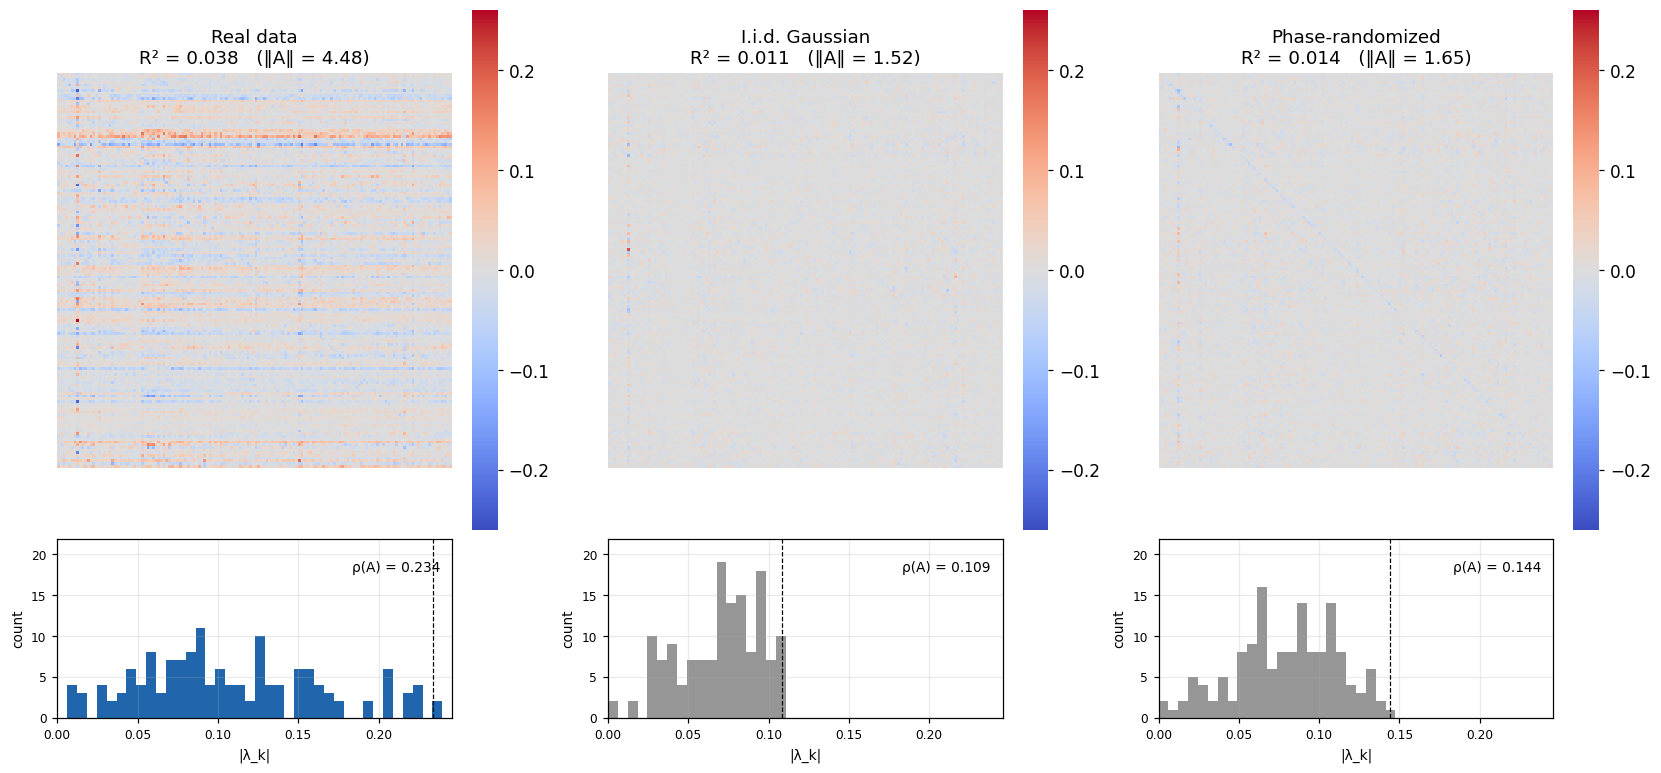

=== CAPTION [fig_2_1_matrices_var] ===
VAR(1) matrix: entry (i,j) = coefficient of asset_i(t-1) → asset_j(t); below each matrix, distribution of the eigenvalue moduli |λ_k| (shared bins), dashed line = spectral radius ρ(A)


In [6]:
rng = np.random.default_rng(42)

def fit_subset_var(data, lags):
    """Subset VAR: r_t = c + sum_k A_k r_{t-k} + eps. Returns (A_blocks, resid, Y)."""
    a = data.values if hasattr(data, 'values') else data
    T_, N_ = a.shape; p = max(lags); n = T_ - p
    X = np.empty((n, len(lags) * N_ + 1)); X[:, 0] = 1.0
    for i, k in enumerate(lags):
        X[:, 1 + i*N_: 1 + (i+1)*N_] = a[p-k: T_-k]
    Y = a[p:]
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    resid = Y - X @ B
    return {k: B[1+i*N_:1+(i+1)*N_] for i, k in enumerate(lags)}, resid, Y

def gen_iid(real, rng):
    return pd.DataFrame(rng.standard_normal(real.shape) * real.std(0).values,
                        index=real.index, columns=real.columns)
def gen_phase(real, rng):
    a = real.values; T_, N_ = a.shape; out = np.empty_like(a)
    for j in range(N_):
        F = np.fft.rfft(a[:, j]); ph = rng.uniform(0, 2*np.pi, F.shape); ph[0] = 0
        if T_ % 2 == 0: ph[-1] = 0
        out[:, j] = np.fft.irfft(np.abs(F) * np.exp(1j*ph), n=T_)
    return pd.DataFrame(out, index=real.index, columns=real.columns)

datasets = {'real': real, 'i.i.d.': gen_iid(real, rng),
            'phase-rand': gen_phase(real, rng)}

fits = {}
for name, d in datasets.items():
    A_blocks, resid, Y = fit_subset_var(d, [1]); A = A_blocks[1]
    r2 = 1 - (resid**2).sum(0) / ((Y - Y.mean(0))**2).sum(0)
    fits[name] = {'A': A, 'r2': r2}

MODEL_LABELS = {'real': 'Real data', 'i.i.d.': 'I.i.d. Gaussian',
                'phase-rand': 'Phase-randomized'}

# ── Matrices (heatmaps) + distribution des coefficients hors-diagonale dessous ─
fig = plt.figure(figsize=(15, 7), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[3.2, 1.1])
vmax = max(np.abs(fits[n]['A']).max() for n in fits)
eigmods = {n: np.abs(np.linalg.eigvals(f['A'])) for n, f in fits.items()}
emax = max(v.max() for v in eigmods.values())
ecmax = max(np.histogram(v, bins=40, range=(0, emax * 1.05))[0].max() for v in eigmods.values())
for c, (name, f) in enumerate(fits.items()):
    ax = fig.add_subplot(gs[0, c])
    sns.heatmap(f['A'], cmap='coolwarm', center=0, vmin=-vmax, vmax=vmax, ax=ax,
                cbar=True, square=True, xticklabels=False, yticklabels=False)
    ax.set_title(f'{MODEL_LABELS.get(name, name)}\nR² = {f["r2"].mean():.3f}   (‖A‖ = {np.linalg.norm(f["A"]):.2f})')
    # distribution des modules des valeurs propres sous la matrice, bornes communes
    axh = fig.add_subplot(gs[1, c])
    col = '#2166ac' if name == 'real' else '#969696'
    mods = eigmods[name]
    axh.hist(mods, bins=40, range=(0, emax * 1.05), color=col, edgecolor='none')
    axh.axvline(mods.max(), color='k', lw=0.8, ls='--')
    axh.set_xlim(0, emax * 1.05); axh.set_ylim(0, ecmax * 1.15)
    axh.set_xlabel('|λ_k|', fontsize=9); axh.set_ylabel('count', fontsize=9)
    axh.tick_params(labelsize=8)
    axh.text(0.97, 0.88, f'ρ(A) = {mods.max():.3f}', transform=axh.transAxes,
             ha='right', va='top', fontsize=9)
fig.suptitle('VAR(1) matrix: entry (i,j) = coefficient of asset_i(t-1) → asset_j(t); '
             'below each matrix, distribution of the eigenvalue moduli |λ_k| '
             '(shared bins), dashed line = spectral radius ρ(A)',
             fontsize=13)
_sup = getattr(fig, '_suptitle', None)
# sous-titres (méthode + R²) conservés SUR la figure ; seule la suptitle part en caption
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_2_1_matrices_var'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_1_matrices_var] ==='); print('\n'.join(_capt))

  done fig_2_1_eigenvalues.pdf  +  fig_2_1_eigenvalues.png


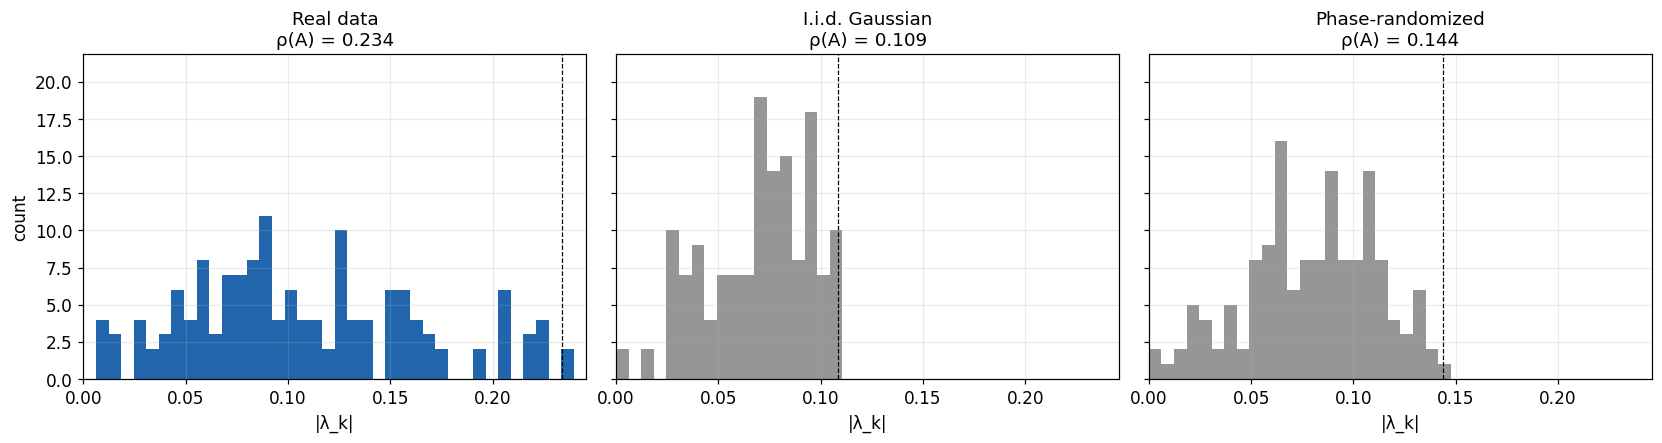

=== CAPTION [fig_2_1_eigenvalues] ===
Distribution of the eigenvalue moduli |λ_k| of the VAR(1) matrix (shared bins), dashed line = spectral radius ρ(A)


In [7]:
# ── Distribution des valeurs propres de chaque matrice VAR(1) (sans les heatmaps) ─
eigvals = {n: np.linalg.eigvals(f['A']) for n, f in fits.items()}
emax = max(np.abs(v).max() for v in eigvals.values())
ecmax = max(np.histogram(np.abs(v), bins=40, range=(0, emax * 1.05))[0].max()
            for v in eigvals.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True, sharey=True)
for ax, (name, f) in zip(axes, fits.items()):
    col = '#2166ac' if name == 'real' else '#969696'
    mods = np.abs(eigvals[name])
    ax.hist(mods, bins=40, range=(0, emax * 1.05), color=col, edgecolor='none')
    ax.axvline(mods.max(), color='k', lw=0.8, ls='--')
    ax.set_xlim(0, emax * 1.05); ax.set_ylim(0, ecmax * 1.15)
    ax.set_xlabel('|λ_k|')
    ax.set_title(f'{MODEL_LABELS.get(name, name)}\nρ(A) = {mods.max():.3f}')
axes[0].set_ylabel('count')
fig.suptitle('Distribution of the eigenvalue moduli |λ_k| of the VAR(1) matrix '
             '(shared bins), dashed line = spectral radius ρ(A)', fontsize=13)
_sup = getattr(fig, '_suptitle', None)
# sous-titres (méthode + ρ) conservés SUR la figure ; seule la suptitle part en caption
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_2_1_eigenvalues'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_1_eigenvalues] ==='); print('\n'.join(_capt))

  done fig_2_1_R2_modeles.pdf  +  fig_2_1_R2_modeles.png


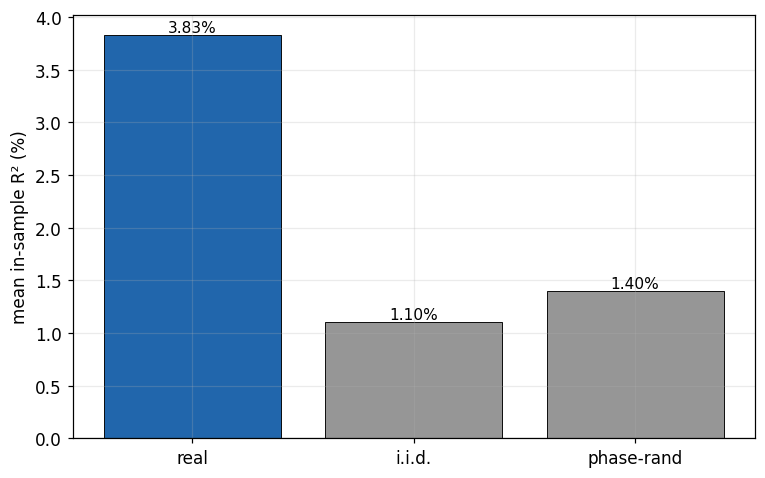

=== CAPTION [fig_2_1_R2_modeles] ===
VAR(1): R² of the real data vs null models


In [8]:
# Mean in-sample R² per model (the "R² of the different models" figure)
names = list(fits.keys())
r2_means = [fits[n]['r2'].mean() * 100 for n in names]
cols = ['#2166ac' if n == 'real' else '#969696' for n in names]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, r2_means, color=cols, edgecolor='black', lw=0.6)
for b, v in zip(bars, r2_means):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('mean in-sample R² (%)')
ax.set_title('VAR(1): R² of the real data vs null models')
ax.axhline(0, color='k', lw=0.7)
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_2_1_R2_modeles'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_1_R2_modeles] ==='); print('\n'.join(_capt))


## 2.2 — Lag selection: BIC and in-sample R²

The NYSE is open 9:30–16:00 = **13 thirty-minute bars per day**, so lag = 13 ≈ 1 day. We compare
**single-lag subset-VARs** (same number of parameters, 1 + N): BIC = n·ln(σ̂²) + k·ln(n).
The BIC minimum falls on **lag = 13** (daily seasonality), confirmed by the jump in R².

  done fig_2_2_bic_lag.pdf  +  fig_2_2_bic_lag.png


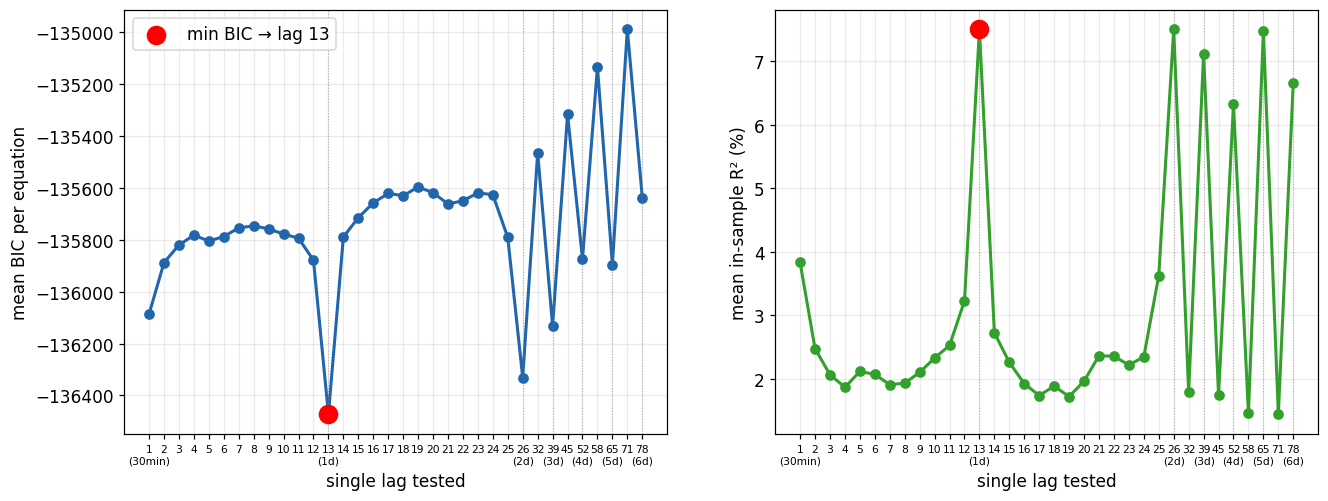

=== CAPTION [fig_2_2_bic_lag] ===
(a) BIC (lower = better)
(b) In-sample R² (jump at lag 13)


In [9]:
# Lags testés : 1 → 26 en entier, puis 1 point intermédiaire entre chaque multiple de 13.
lags_single = list(range(1, 27)) + [32, 39, 45, 52, 58, 65, 71, 78]

def _lag_label(lag):
    if lag % 13 == 0:                       # multiples de 13 = jours entiers
        return f'{lag}\n({lag // 13}d)'
    if lag == 1:
        return '1\n(30min)'
    return str(lag)
labels = [_lag_label(l) for l in lags_single]
mult13 = [i for i, l in enumerate(lags_single) if l % 13 == 0]   # repères jours

bic, r2m = [], []
for lag in lags_single:
    _, resid, Y = fit_subset_var(real, [lag])
    n_eff = resid.shape[0]; k = 1 + N
    rss = (resid**2).sum(0); sigma2 = rss / n_eff
    bic.append((n_eff*np.log(sigma2) + k*np.log(n_eff)).mean())
    r2m.append((1 - rss / ((Y - Y.mean(0))**2).sum(0)).mean() * 100)
bic, r2m = np.array(bic), np.array(r2m)
best = bic.argmin()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(lags_single))
axL.plot(x, bic, 'o-', color='#2166ac', lw=2.0, ms=6)
axL.scatter([best], [bic[best]], color='red', s=140, zorder=5,
            label=f'min BIC → lag {lags_single[best]}')
for i in mult13:
    axL.axvline(i, color='gray', ls=':', lw=0.7, alpha=0.6)
axL.set_xticks(x); axL.set_xticklabels(labels, fontsize=7)
axL.set_xlabel('single lag tested'); axL.set_ylabel('mean BIC per equation')
axL.set_title('(a) BIC (lower = better)'); axL.legend()

axR.plot(x, r2m, 'o-', color='#33a02c', lw=2.0, ms=6)
axR.scatter([best], [r2m[best]], color='red', s=140, zorder=5)
for i in mult13:
    axR.axvline(i, color='gray', ls=':', lw=0.7, alpha=0.6)
axR.set_xticks(x); axR.set_xticklabels(labels, fontsize=7)
axR.set_xlabel('single lag tested'); axR.set_ylabel('mean in-sample R² (%)')
axR.set_title('(b) In-sample R² (jump at lag 13)')
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_2_2_bic_lag'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_2_bic_lag] ==='); print('\n'.join(_capt))

## 2.4 — Lag interpretation: sectors (30 min) vs geography (1 day)

The network built on the **short-lag (30 min) correlation** brings out the **sectors**
(assets in the same sector react together within the day). The **1-day lag (13 bars)** network
instead brings out **geographic** groupings (time-zone offsets between marketplaces).
Each network is thresholded to keep its strongest links; the ForceAtlas2 layout pulls linked nodes together.

### 2.4 bis — Réseau VAR (sur toute la série)

Variante **VAR** de la fig. 2.4 (qui, elle, est une corrélation laggée + MST). On ajuste **un seul VAR sur
l'ensemble des données** au lag voulu : la matrice de coefficients `A[i,j]` mesure l'effet de
`asset_i(t−lag)` sur `asset_j(t)` (réseau **orienté** i→j). On ne garde que les **liens les plus forts**
(top-K en `|A|`), ForceAtlas2, couleur = secteur (lag 30 min) / géographie (lag 1 j), taille = force totale
`Σ|A|`, épaisseur = `|coef|`.

  done fig_2_6_liens_recurrents.pdf  +  fig_2_6_liens_recurrents.png


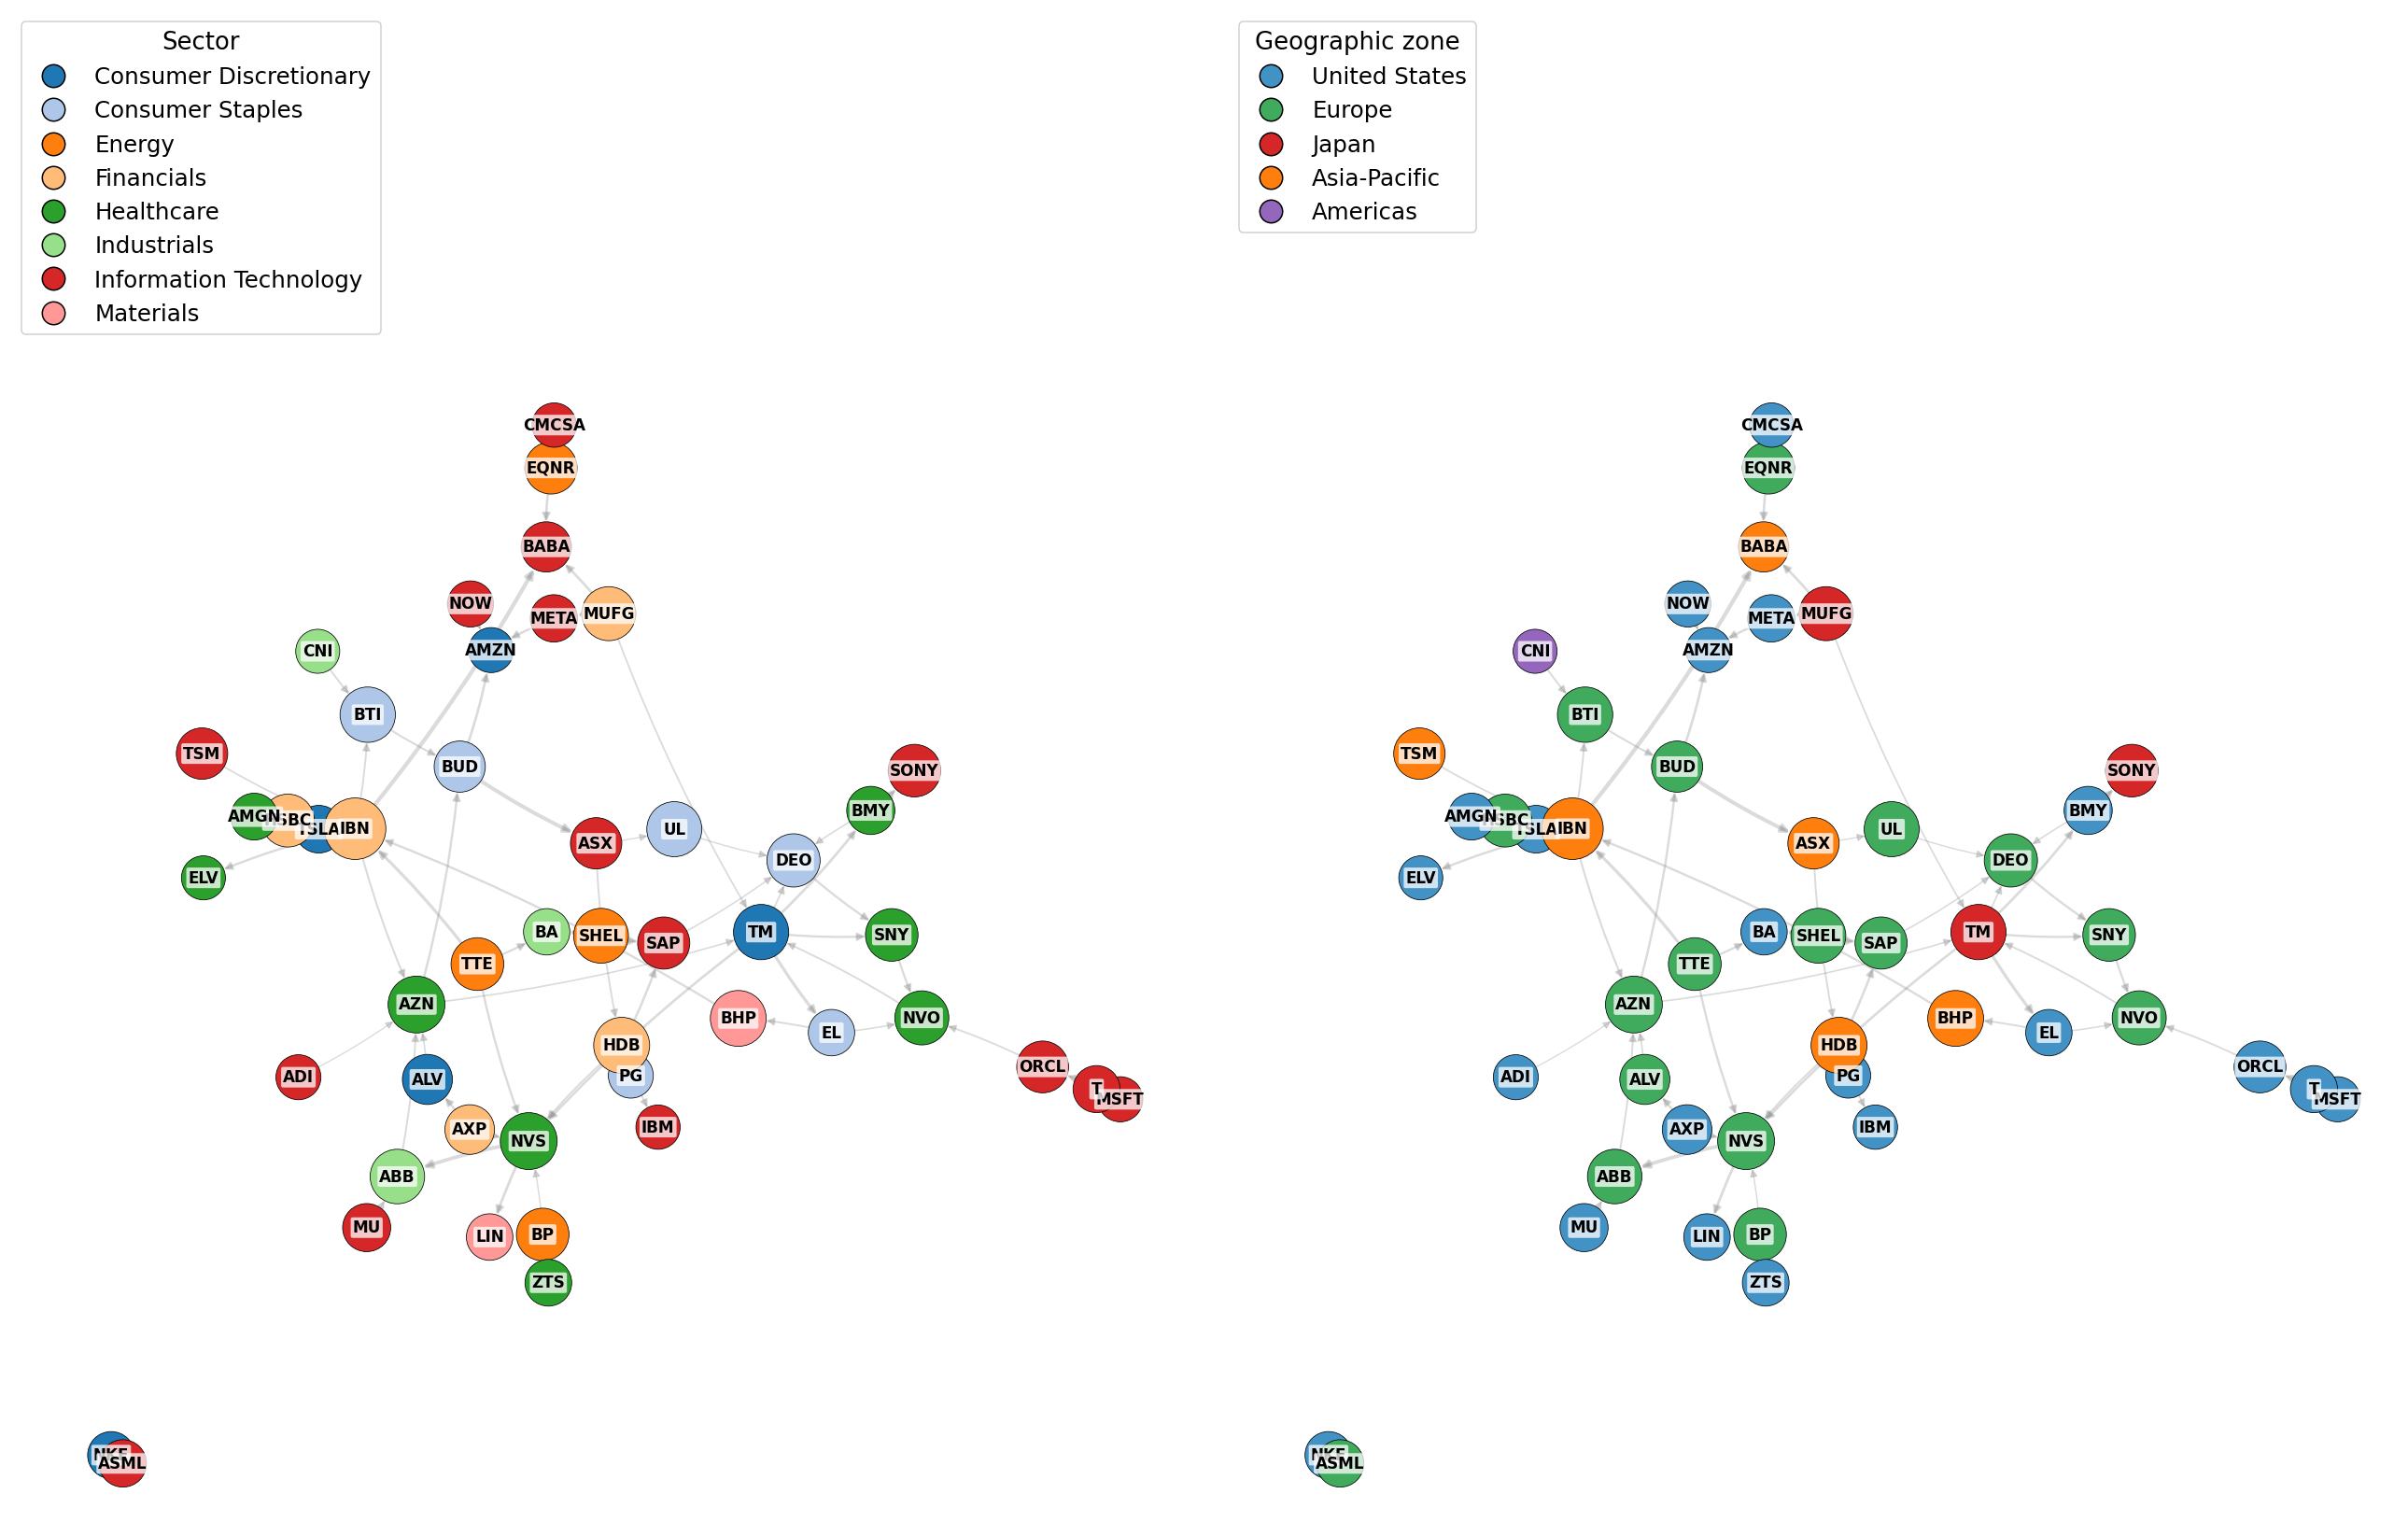

=== CAPTION [fig_2_6_liens_recurrents] ===
Recurrent-link network — sparse VAR lag-13 (1 day), 30 chunks, q=0.9, F>0.2 — top-45 links  |  arrow i→j: i predicts j  |  node size = recurrence, edge width = mean |coef|
(a) color = sector
(b) color = geographic zone
1018 liens récurrents (F>0.2). Les 15 plus récurrents :


,de,vers,zone_de,zone_vers,secteur_de,secteur_vers,récurrence_F,|coef|_moyen
0,TM,NVS,Japan,Europe,Consumer Discretionary,Healthcare,0.47,0.1638
1,AZN,TM,Europe,Japan,Healthcare,Consumer Discretionary,0.47,0.0889
2,META,AMZN,United States,United States,Information Technology,Consumer Discretionary,0.40,0.1467
3,TTE,NVS,Europe,Europe,Energy,Healthcare,0.40,0.1437
4,ABB,AZN,Europe,Europe,Industrials,Healthcare,0.40,0.1128
5,TTE,IBN,Europe,Asia-Pacific,Energy,Financials,0.37,0.2018
6,TM,EL,Japan,United States,Consumer Discretionary,Consumer Staples,0.37,0.2017
7,BMY,SONY,United States,Japan,Healthcare,Information Technology,0.37,0.1631
8,AXP,ALV,United States,Europe,Financials,Consumer Discretionary,0.37,0.1440
9,TM,SNY,Japan,Europe,Consumer Discretionary,Healthcare,0.37,0.1390


In [10]:
# ── Liens les plus RÉCURRENTS (sparse VAR par chunk, façon validation.ipynb §7) ──
# On découpe la série en n_chunks morceaux ; dans chacun on ajuste un sparse VAR
# (top-(1-q) de |C_lag|, OLS). F[i,j] = fraction de chunks où l'arête i->j est active.
# Les liens persistants (F élevé) = vraies relations récurrentes, pas du bruit d'un chunk.
import networkx as nx
from fa2_modified import ForceAtlas2

LAG_P, N_CHUNKS_P, Q_P, SEUIL_F = 13, 30, 0.90, 0.20     # 1 jour (seuil bas + top-K, comme lag 1)

def _corr_lag(a, lag):
    x, y = a[:-lag], a[lag:]
    xc = x - x.mean(0); yc = y - y.mean(0)
    return (xc.T @ yc / len(xc)) / np.outer(xc.std(0), yc.std(0))

def _fit_sparse_chunk(a, lag, q):
    n = len(a) - lag; X, Y = a[:-lag], a[lag:]
    C = _corr_lag(a, lag); mask = np.abs(C) > np.quantile(np.abs(C), q)
    A = np.zeros((a.shape[1], a.shape[1]))
    for j in range(a.shape[1]):
        act = np.where(mask[:, j])[0]
        if act.size:
            b, *_ = np.linalg.lstsq(np.column_stack([np.ones(n), X[:, act]]), Y[:, j], rcond=None)
            A[act, j] = b[1:]
    return A

chunks = [c for c in np.array_split(real.values, N_CHUNKS_P) if len(c) > LAG_P + 5]
As   = np.stack([_fit_sparse_chunk(c, LAG_P, Q_P) for c in chunks])
cnt  = (As != 0).sum(0)
F    = cnt / len(chunks)                                  # fréquence d'activation (récurrence)
Amw  = np.where(cnt > 0, np.abs(As).sum(0) / np.maximum(cnt, 1), 0.0)   # |coef| moyen
np.fill_diagonal(F, 0.0); np.fill_diagonal(Amw, 0.0)

# ── Réseau orienté : top-K liens les plus récurrents ─────────────────────────
TOP_K = 45                                                # même nb de liens que la figure lag-1
_M = F.copy(); np.fill_diagonal(_M, 0.0); _cand = _M > SEUIL_F
if _cand.sum() > TOP_K:
    _thr = np.partition(_M[_cand], -TOP_K)[-TOP_K]; _cand = _M >= _thr
adj = _cand.astype(int); np.fill_diagonal(adj, 0)
idxmap = {n: i for i, n in enumerate(asset_names)}
G = nx.relabel_nodes(nx.from_numpy_array(adj, create_using=nx.DiGraph), dict(enumerate(asset_names)))
for u, v in G.edges():
    G[u][v]['weight'] = Amw[idxmap[u], idxmap[v]]
G.remove_nodes_from([n for n in G.nodes() if G.degree(n) == 0])
freq = F.sum(1) + F.sum(0)

# layout commun, étalé (mêmes réglages que la figure lag-1)
fa2P = ForceAtlas2(outboundAttractionDistribution=True, edgeWeightInfluence=1.0,
                   barnesHutOptimize=True, scalingRatio=9.0, gravity=0.12, verbose=False)
pos   = fa2P.forceatlas2_networkx_layout(G.to_undirected(), pos=None, iterations=1000)
# rapprocher les petites communautés détachées du blob principal
_comps = sorted(nx.connected_components(G.to_undirected()), key=len, reverse=True)
if len(_comps) > 1:
    _P = np.array([pos[n] for n in _comps[0]]); _cen = _P.mean(0)
    _rad = np.linalg.norm(_P - _cen, axis=1).max()
    for _comp in _comps[1:]:
        _ccen = np.array([pos[n] for n in _comp]).mean(0)
        _d = _ccen - _cen; _dist = np.linalg.norm(_d)
        if _dist > 1e-9:
            _shift = (_cen + _d / _dist * (_rad * 1.15)) - _ccen
            for _n in _comp:
                pos[_n] = pos[_n] + _shift
sizes = [160 + 1700 * (freq[idxmap[n]] / freq.max()) for n in G.nodes()]
w = np.array([G[u][v]['weight'] for u, v in G.edges()])
wid = 0.3 + 2.5 * (w / w.max()) if w.size and w.max() > 0 else 0.5

# headroom en haut : réserve une bande vide pour la légende (elle mordait sur les nœuds)
_P = np.array([pos[n] for n in G.nodes()]); _xmin, _ymin = _P.min(0); _xmax, _ymax = _P.max(0)
_w = _xmax - _xmin; _h = _ymax - _ymin
XLIM = (_xmin - 0.10 * _w, _xmax + 0.06 * _w); YLIM = (_ymin - 0.06 * _h, _ymax + 0.40 * _h)

def _draw_panel(ax, color_map, color_dict, legend_title, subtitle):
    nx.draw_networkx_edges(G, pos, ax=ax, width=wid, alpha=0.30, edge_color='#888888', arrows=True,
                           arrowstyle='-|>', arrowsize=11, connectionstyle='arc3,rad=0.05', node_size=sizes)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes,
                           node_color=[color_dict[color_map[idxmap[n]]] for n in G.nodes()],
                           edgecolors='black', linewidths=0.5)
    lbl = nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_weight='bold')
    for t in lbl.values():
        t.set_bbox(dict(boxstyle='round,pad=0.12', fc='white', ec='none', alpha=0.75))
    present = [k for k in color_dict if any(color_map[idxmap[n]] == k for n in G.nodes())]
    ax.legend(handles=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=color_dict[k],
              markeredgecolor='black',markersize=16,label=k) for k in present],
              loc='upper left', fontsize=16, title=legend_title, title_fontsize=17, framealpha=0.9)
    ax.set_title(subtitle, fontsize=12); ax.axis('off')
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(30, 18))
_draw_panel(axL, sector_arr, SECTOR_COLORS, 'Sector', '(a) color = sector')
_draw_panel(axR, geo_arr, GEO_COLORS, 'Geographic zone', '(b) color = geographic zone')
fig.suptitle(f'Recurrent-link network — sparse VAR lag-{LAG_P} (1 day), {len(chunks)} chunks, q={Q_P}, '
             f'F>{SEUIL_F} — top-{TOP_K} links  |  arrow i→j: i predicts j  |  node size = recurrence, edge width = mean |coef|',
             fontsize=12)
fig.subplots_adjust(wspace=0.04, top=0.93)
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_2_6_liens_recurrents'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_6_liens_recurrents] ==='); print('\n'.join(_capt))

# ── Classement des liens les plus RÉCURRENTS (F le plus élevé) ───────────────
ii, jj = np.where(F > SEUIL_F)
links = pd.DataFrame({
    'de': [asset_names[i] for i in ii], 'vers': [asset_names[j] for j in jj],
    'zone_de': [geo_arr[i] for i in ii], 'zone_vers': [geo_arr[j] for j in jj],
    'secteur_de': [sector_arr[i] for i in ii], 'secteur_vers': [sector_arr[j] for j in jj],
    'récurrence_F': F[ii, jj].round(2), '|coef|_moyen': Amw[ii, jj].round(4),
}).sort_values(['récurrence_F', '|coef|_moyen'], ascending=False).reset_index(drop=True)
print(f'{len(links)} liens récurrents (F>{SEUIL_F}). Les 15 plus récurrents :')
display(links.head(15))

  done fig_2_7_liens_recurrents_lag1.pdf  +  fig_2_7_liens_recurrents_lag1.png


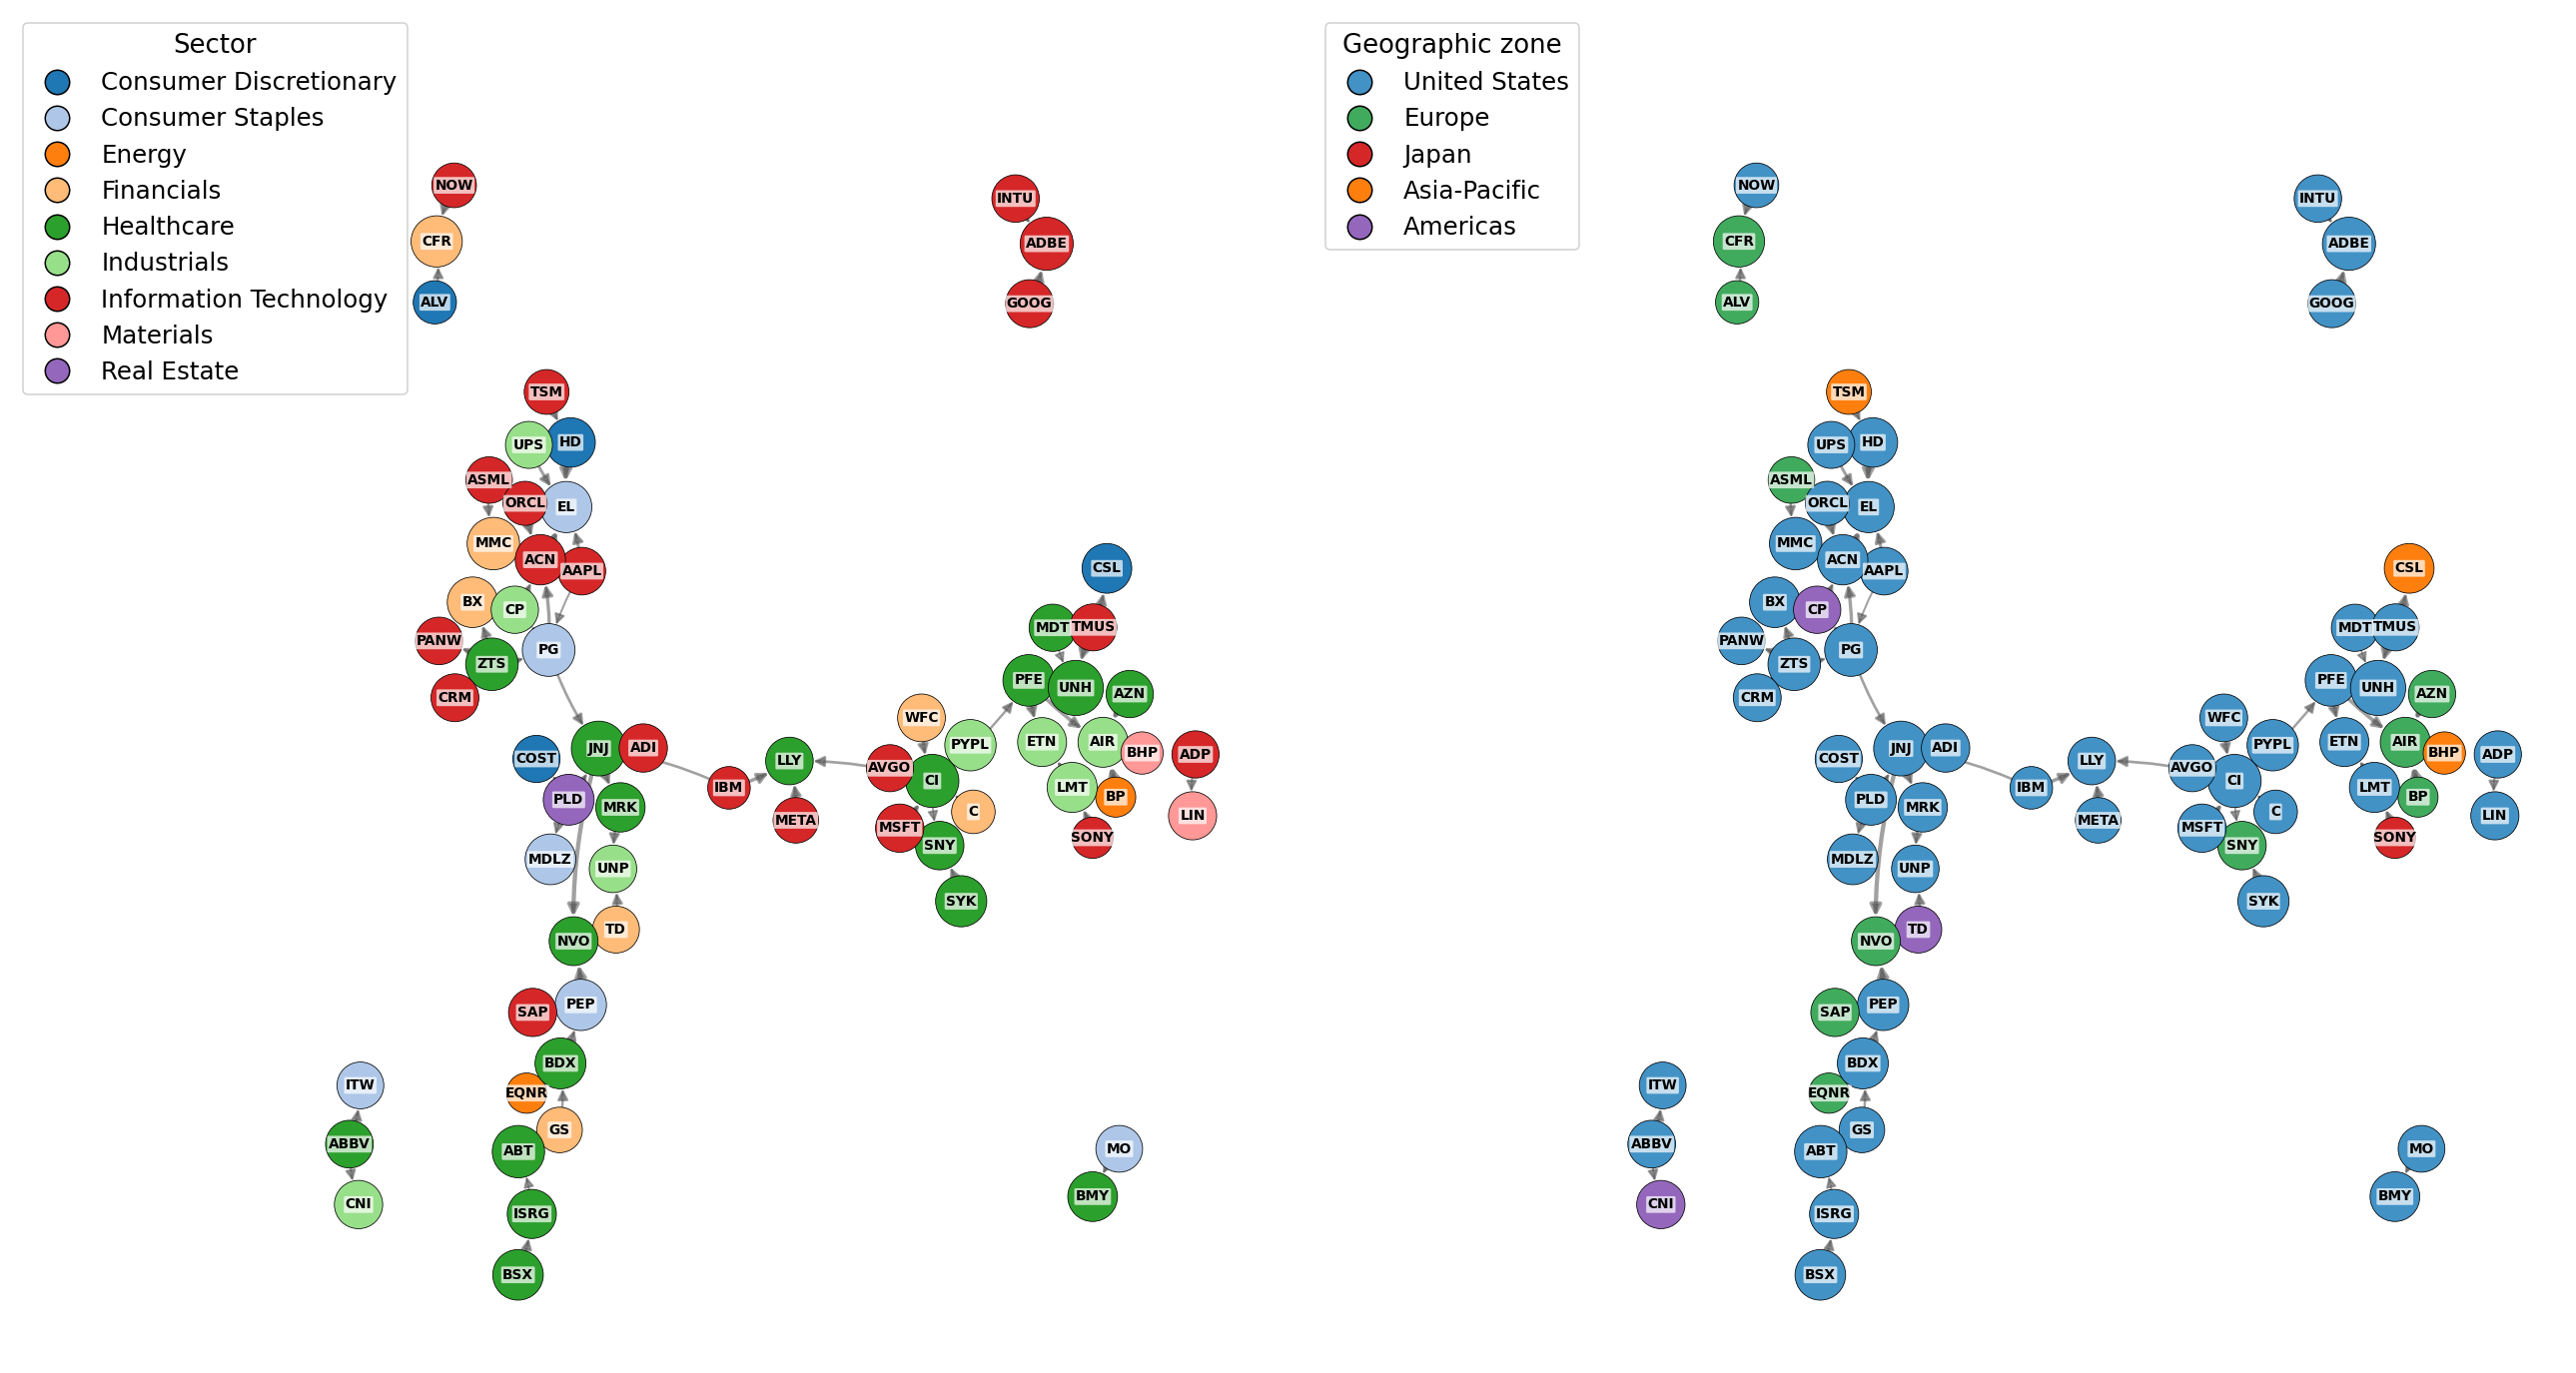

=== CAPTION [fig_2_7_liens_recurrents_lag1] ===
Recurrent-link network — sparse VAR lag-1 (30 min), 30 chunks, q=0.9, F>0.2 — top-45 links  |  arrow i→j: i predicts j  |  node size = recurrence, edge width = mean |coef|
(a) color = sector
(b) color = geographic zone
719 liens récurrents lag-1 (F>0.2). Les 15 plus récurrents :


,de,vers,secteur_de,secteur_vers,zone_de,zone_vers,récurrence_F,|coef|_moyen
0,ABBV,CNI,Healthcare,Industrials,United States,Americas,0.43,0.0439
1,BHP,AIR,Materials,Industrials,Asia-Pacific,Europe,0.37,0.1586
2,PG,ACN,Consumer Staples,Information Technology,United States,United States,0.33,0.0919
3,PFE,ETN,Healthcare,Industrials,United States,United States,0.33,0.0772
4,UPS,EL,Industrials,Consumer Staples,United States,United States,0.33,0.0743
5,ZTS,BX,Healthcare,Financials,United States,United States,0.33,0.0703
6,ORCL,ACN,Information Technology,Information Technology,United States,United States,0.33,0.0703
7,PG,CP,Consumer Staples,Industrials,United States,Americas,0.33,0.0685
8,NOW,CFR,Information Technology,Financials,United States,Europe,0.33,0.0649
9,CI,LLY,Healthcare,Healthcare,United States,United States,0.33,0.0634


In [11]:
# ── Liens récurrents LAG 1 (30 min) — 2 panneaux : secteur | géographie ──────
# (réutilise _fit_sparse_chunk défini plus haut). Même réseau, même disposition,
# seule la couleur change : (a) secteur, (b) zone géographique.
LAG_P1, N_CHUNKS_P1, Q_P1, SEUIL_F1 = 1, 30, 0.90, 0.20   # seuil abaissé (lag 30 min peu récurrent)
idxmap = {n: i for i, n in enumerate(asset_names)}

chunks1 = [c for c in np.array_split(real.values, N_CHUNKS_P1) if len(c) > LAG_P1 + 5]
As1  = np.stack([_fit_sparse_chunk(c, LAG_P1, Q_P1) for c in chunks1])
cnt1 = (As1 != 0).sum(0)
F1   = cnt1 / len(chunks1)
Amw1 = np.where(cnt1 > 0, np.abs(As1).sum(0) / np.maximum(cnt1, 1), 0.0)
np.fill_diagonal(F1, 0.0); np.fill_diagonal(Amw1, 0.0)

TOP_K1 = 45                                               # on ne dessine que les liens les + récurrents
_M = F1.copy(); np.fill_diagonal(_M, 0.0); _cand = _M > SEUIL_F1
if _cand.sum() > TOP_K1:
    _thr = np.partition(_M[_cand], -TOP_K1)[-TOP_K1]; _cand = _M >= _thr
adj1 = _cand.astype(int); np.fill_diagonal(adj1, 0)
G1 = nx.relabel_nodes(nx.from_numpy_array(adj1, create_using=nx.DiGraph), dict(enumerate(asset_names)))
for u, v in G1.edges():
    G1[u][v]['weight'] = Amw1[idxmap[u], idxmap[v]]
G1.remove_nodes_from([n for n in G1.nodes() if G1.degree(n) == 0])
freq1 = F1.sum(1) + F1.sum(0)

# layout commun, plus étalé (scalingRatio haut, gravité basse) -> nœuds espacés
fa2P1 = ForceAtlas2(outboundAttractionDistribution=True, edgeWeightInfluence=0.2,
                    barnesHutOptimize=True, scalingRatio=18.0, gravity=0.05, verbose=False)
pos1   = fa2P1.forceatlas2_networkx_layout(G1.to_undirected(), pos=None, iterations=1500)
# rapprocher les petites communautés détachées du blob principal
_comps = sorted(nx.connected_components(G1.to_undirected()), key=len, reverse=True)
if len(_comps) > 1:
    _P = np.array([pos1[n] for n in _comps[0]]); _cen = _P.mean(0)
    _rad = np.linalg.norm(_P - _cen, axis=1).max()
    for _comp in _comps[1:]:
        _ccen = np.array([pos1[n] for n in _comp]).mean(0)
        _d = _ccen - _cen; _dist = np.linalg.norm(_d)
        if _dist > 1e-9:
            _shift = (_cen + _d / _dist * (_rad * 1.15)) - _ccen
            for _n in _comp:
                pos1[_n] = pos1[_n] + _shift

nodes1 = list(G1.nodes())
sizes1 = np.array([110 + 1200 * (freq1[idxmap[n]] / freq1.max()) for n in nodes1])

# ── anti-chevauchement : écarte les nœuds dont les disques se recouvrent ──────
# ForceAtlas2 ignore le rayon des nœuds -> dans les clusters denses les disques
# s'empilent et les étiquettes deviennent illisibles. On relaxe les positions a
# posteriori : tant que deux disques (rayon ∝ √taille) se recouvrent, on les
# repousse le long de leur axe. La topologie (qui pointe vers qui) est conservée.
def _prevent_overlap(pos, names, sizes, pad_frac=0.018, k=1.08, iters=400):
    P = np.array([pos[n] for n in names], float)
    r = np.sqrt(sizes); r = r / r.mean()
    span = float(np.linalg.norm(P.max(0) - P.min(0)))
    r = r * span * pad_frac * k                          # rayon "de sécurité" par nœud
    for _ in range(iters):
        moved = 0.0
        for i in range(len(P)):
            d = P - P[i]; dist = np.hypot(d[:, 0], d[:, 1]); dist[i] = np.inf
            over = (r + r[i]) - dist; msk = over > 0      # paires qui se chevauchent
            if msk.any():
                dv = d[msk] / dist[msk][:, None]
                shift = (0.5 * over[msk][:, None] * dv).sum(0)
                P[i] -= shift; moved += np.hypot(*shift)
        if moved < span * 1e-4:                           # convergence
            break
    return {nm: P[i] for i, nm in enumerate(names)}

pos1 = _prevent_overlap(pos1, nodes1, sizes1)
sz1  = {n: s for n, s in zip(nodes1, sizes1)}

w1 = np.array([G1[u][v]['weight'] for u, v in G1.edges()])
wid1 = 0.8 + 3.0 * (w1 / w1.max()) if w1.size and w1.max() > 0 else 0.8

# limites communes aux 2 panneaux, avec gouttière haut-gauche réservée à la légende
_P = np.array([pos1[n] for n in nodes1]); _xmin, _ymin = _P.min(0); _xmax, _ymax = _P.max(0)
_w = _xmax - _xmin; _h = _ymax - _ymin
XLIM1 = (_xmin - 0.40 * _w, _xmax + 0.08 * _w); YLIM1 = (_ymin - 0.08 * _h, _ymax + 0.16 * _h)

def _draw_panel(ax, color_map, color_dict, legend_title, subtitle):
    nsz = [sz1[n] for n in G1.nodes()]
    nx.draw_networkx_edges(G1, pos1, ax=ax, width=wid1, alpha=0.55, edge_color='#555555', arrows=True,
                           arrowstyle='-|>', arrowsize=14, connectionstyle='arc3,rad=0.08', node_size=nsz)
    nx.draw_networkx_nodes(G1, pos1, ax=ax, node_size=nsz,
                           node_color=[color_dict[color_map[idxmap[n]]] for n in G1.nodes()],
                           edgecolors='black', linewidths=0.5)
    lbl = nx.draw_networkx_labels(G1, pos1, ax=ax, font_size=9, font_weight='bold')
    for t in lbl.values():
        t.set_bbox(dict(boxstyle='round,pad=0.10', fc='white', ec='none', alpha=0.7))
    present = [k for k in color_dict if any(color_map[idxmap[n]] == k for n in G1.nodes())]
    ax.legend(handles=[plt.Line2D([0],[0],marker='o',color='w',markerfacecolor=color_dict[k],
              markeredgecolor='black',markersize=16,label=k) for k in present],
              loc='upper left', fontsize=16, title=legend_title, title_fontsize=17, framealpha=0.9)
    ax.set_title(subtitle, fontsize=12); ax.axis('off')
    ax.set_xlim(*XLIM1); ax.set_ylim(*YLIM1)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(30, 15))
_draw_panel(axL, sector_arr, SECTOR_COLORS, 'Sector', '(a) color = sector')
_draw_panel(axR, geo_arr, GEO_COLORS, 'Geographic zone', '(b) color = geographic zone')
fig.suptitle(f'Recurrent-link network — sparse VAR lag-{LAG_P1} (30 min), {len(chunks1)} chunks, q={Q_P1}, '
             f'F>{SEUIL_F1} — top-{TOP_K1} links  |  arrow i→j: i predicts j  |  node size = recurrence, edge width = mean |coef|',
             fontsize=12)
fig.subplots_adjust(wspace=0.04, top=0.93)
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_2_7_liens_recurrents_lag1'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_7_liens_recurrents_lag1] ==='); print('\n'.join(_capt))

# ── Classement des liens les plus récurrents (lag 1) ─────────────────────────
ii, jj = np.where(F1 > SEUIL_F1)
links1 = pd.DataFrame({
    'de': [asset_names[i] for i in ii], 'vers': [asset_names[j] for j in jj],
    'secteur_de': [sector_arr[i] for i in ii], 'secteur_vers': [sector_arr[j] for j in jj],
    'zone_de': [geo_arr[i] for i in ii], 'zone_vers': [geo_arr[j] for j in jj],
    'récurrence_F': F1[ii, jj].round(2), '|coef|_moyen': Amw1[ii, jj].round(4),
}).sort_values(['récurrence_F', '|coef|_moyen'], ascending=False).reset_index(drop=True)
print(f'{len(links1)} liens récurrents lag-1 (F>{SEUIL_F1}). Les 15 plus récurrents :')
display(links1.head(15))

### 2.2 ter — VAR link stability over time (recurrence vs chance)

Même méthodologie que les liens récurrents ci-dessus (sparse VAR par chunk, K=30, q=0.90) : si les
coefficients du VAR étaient **stationnaires**, les liens actifs se répéteraient de chunk en chunk.
On compare au null « sans mémoire » où le support (~10 % des liens, densité p imposée par le seuil q)
est **re-tiré au hasard à chaque chunk** :

- **(a)** nombre de liens actifs dans ≥ k chunks, contre la binomiale Bin(K, p) ;
- **(b)** similarité de Jaccard moyenne entre les jeux de liens de deux chunks, selon leur écart
  temporel, contre le niveau de chance p/(2−p).

Si les deux courbes collent au null → le support du VAR est re-tiré à chaque période : **pas de
redondance temporelle des liens**, seule une petite queue (les top-45 des figures précédentes)
dépasse le hasard.

  done fig_2_8_stabilite_var.pdf  +  fig_2_8_stabilite_var.png


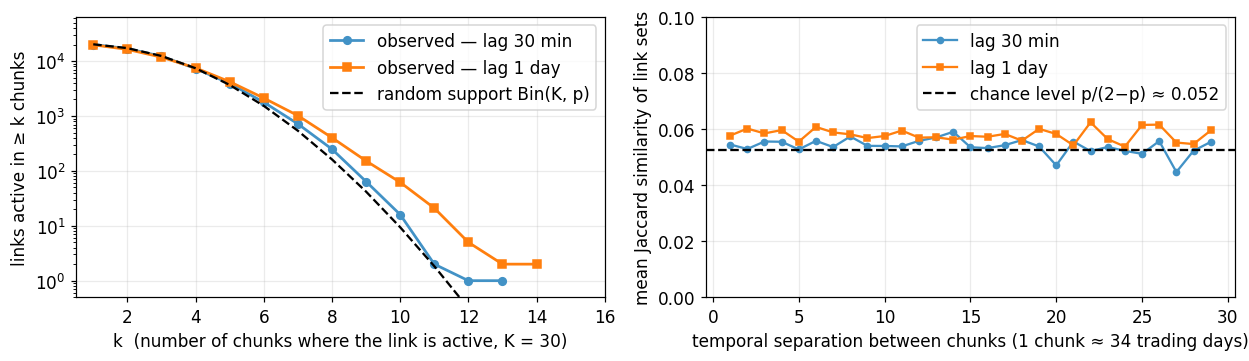

=== CAPTION [fig_2_8_stabilite_var] ===
Temporal stability of the VAR links — sparse VAR per chunk (K=30 chunks, q=0.90), lag 30 min vs 1 day
(a) Link recurrence: the bulk follows the random-support binomial;
only a tiny tail of links exceeds chance
(b) Overlap between the link sets of two chunks:
at chance level and flat in time — no persistence, no slow decay
lag 30 min: actifs ≥1 fois 20080/21170 (95%) ; ≥10 chunks: 16 obs vs 9.4 attendus ; F max = 13/30 ; Jaccard moyen 0.0539 vs chance 0.0525
lag 1 day : actifs ≥1 fois 19817/21170 (94%) ; ≥10 chunks: 62 obs vs 9.6 attendus ; F max = 14/30 ; Jaccard moyen 0.0579 vs chance 0.0526


In [12]:
# ── Stabilité temporelle des liens VAR : récurrence observée vs hasard pur ────
# Réutilise les VAR sparse par chunk (As = lag 13, As1 = lag 1). Null "sans
# mémoire" : support de densité p re-tiré au hasard à chaque chunk, d'où
#   (a) nb de liens actifs dans >= k chunks ~ Bin(K, p) ;
#   (b) Jaccard entre les jeux de liens de 2 chunks ~ p/(2-p), quel que soit l'écart.
from scipy.stats import binom

def _stab(As_):
    B = (As_ != 0); Kc = len(B)
    off = ~np.eye(B.shape[1], dtype=bool)
    flat = B[:, off]                                   # (K, N(N-1)) liens hors diagonale
    p, L = flat.mean(), flat.shape[1]
    ks = np.arange(1, Kc + 1)
    surv_obs  = np.array([(flat.sum(0) >= k).sum() for k in ks])
    surv_null = binom.sf(ks - 1, Kc, p) * L
    jac = {}                                           # Jaccard par écart temporel
    for i in range(Kc):
        for j in range(i + 1, Kc):
            inter = (flat[i] & flat[j]).sum(); union = (flat[i] | flat[j]).sum()
            jac.setdefault(j - i, []).append(inter / union)
    seps = np.array(sorted(jac)); jmean = np.array([np.mean(jac[d]) for d in seps])
    return dict(Kc=Kc, p=p, L=L, ks=ks, obs=surv_obs, null=surv_null, seps=seps, jac=jmean)

S1, S13 = _stab(As1), _stab(As)
COL = {'30 min': '#4292c6', '1 day': '#ff7f0e'}
bars_per_chunk = len(real) // len(chunks)              # ~445 barres ~ 34 jours de bourse

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) fonction de survie de la récurrence, échelle log
for S, lab, mk in ((S1, '30 min', 'o'), (S13, '1 day', 's')):
    m = S['obs'] > 0
    axA.plot(S['ks'][m], S['obs'][m], mk + '-', ms=5, lw=1.8, color=COL[lab],
             label=f'observed — lag {lab}')
axA.plot(S1['ks'], S1['null'], 'k--', lw=1.5, label='random support Bin(K, p)')
axA.set_yscale('log'); axA.set_ylim(0.5, S1['L'] * 3); axA.set_xlim(0.5, 16)
axA.set_xlabel(f"k  (number of chunks where the link is active, K = {S1['Kc']})")
axA.set_ylabel('links active in ≥ k chunks')
axA.set_title('(a) Link recurrence: the bulk follows the random-support binomial;\n'
              'only a tiny tail of links exceeds chance')
axA.legend(frameon=True)

# (b) Jaccard entre chunks selon l'écart temporel
for S, lab, mk in ((S1, '30 min', 'o'), (S13, '1 day', 's')):
    axB.plot(S['seps'], S['jac'], mk + '-', ms=4, lw=1.5, color=COL[lab], label=f'lag {lab}')
chance = S1['p'] / (2 - S1['p'])
axB.axhline(chance, color='k', ls='--', lw=1.5, label=f'chance level p/(2−p) ≈ {chance:.3f}')
axB.set_ylim(0, 0.10)
axB.set_xlabel(f'temporal separation between chunks (1 chunk ≈ {bars_per_chunk // 13} trading days)')
axB.set_ylabel('mean Jaccard similarity of link sets')
axB.set_title('(b) Overlap between the link sets of two chunks:\n'
              'at chance level and flat in time — no persistence, no slow decay')
axB.legend(frameon=True, loc='upper right')

fig.suptitle(f"Temporal stability of the VAR links — sparse VAR per chunk "
             f"(K={S1['Kc']} chunks, q=0.90), lag 30 min vs 1 day", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
_sup = getattr(fig, '_suptitle', None)
_capt = ([_sup.get_text()] if _sup and _sup.get_text() else []) + [a.get_title() for a in fig.axes if a.get_title()]
if _sup: _sup.set_text('')
for a in fig.axes: a.set_title('')
save(fig, 'fig_2_8_stabilite_var'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_8_stabilite_var] ==='); print('\n'.join(_capt))

# chiffres pour le texte du rapport
for S, lab in ((S1, 'lag 30 min'), (S13, 'lag 1 day ')):
    print(f"{lab}: actifs ≥1 fois {S['obs'][0]}/{S['L']} ({S['obs'][0]/S['L']:.0%}) ; "
          f"≥10 chunks: {S['obs'][9]} obs vs {S['null'][9]:.1f} attendus ; "
          f"F max = {S['ks'][S['obs']>0].max()}/{S['Kc']} ; "
          f"Jaccard moyen {S['jac'].mean():.4f} vs chance {S['p']/(2-S['p']):.4f}")

#### Mosaïque des matrices de contagion par période (façon validation.ipynb §7.1)

Les matrices VAR(13) complètes estimées sur K=5 sous-périodes, même échelle de couleur.
**Attention à la lecture** : le test split-half ci-dessous montre que deux moitiés d'une *même*
période donnent des coefficients aussi décorrélés (r ≈ 0.02) que deux périodes différentes
(r ≈ 0.01) — au niveau des entrées individuelles, les différences visuelles sont dominées par le
bruit d'estimation. La mosaïque *illustre* le propos ; la démonstration rigoureuse de la
non-stationnarité est la figure de récurrence (`fig_2_8_stabilite_var`), qui travaille au niveau
des liens forts avec un null de chance.

  done fig_2_9_matrices_var_chunks.pdf  +  fig_2_9_matrices_var_chunks.png


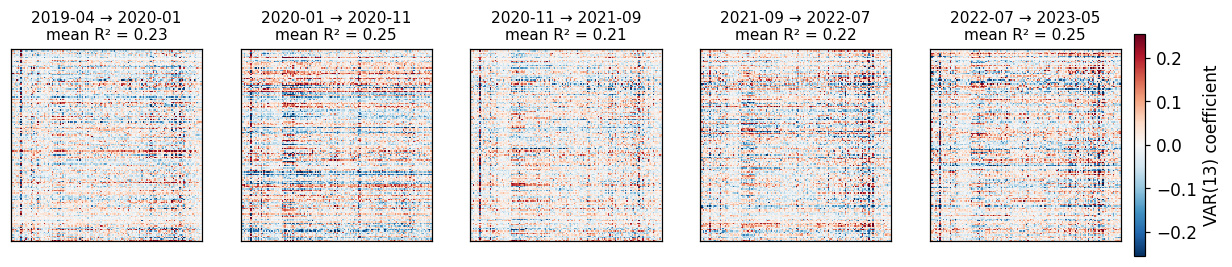

=== CAPTION [fig_2_9_matrices_var_chunks] ===
Full VAR(13) contagion matrix re-estimated on K=5 sub-periods (entry (i, j): asset i(t−13) → asset j(t), shared colour scale)
corr(vec A_p, vec A_q) hors diagonale entre les 5 périodes :
       0      1      2      3      4
0  1.000 -0.005  0.014  0.032  0.036
1 -0.005  1.000 -0.010  0.076 -0.030
2  0.014 -0.010  1.000  0.054 -0.002
3  0.032  0.076  0.054  1.000  0.076
4  0.036 -0.030 -0.002  0.076  1.000
split-half : corr INTRA-période 0.022  vs  INTER-périodes 0.007  ->  les coefficients individuels sont dominés par le bruit d'estimation ; la stabilité se juge au niveau des liens récurrents (fig_2_8).


In [13]:
# ── Mosaïque : matrices VAR(13) par sous-période + test split-half ────────────
K_MOS, LAG_MOS = 5, 13

def _fit_var_full(a, lag):
    X, Y = a[:-lag], a[lag:]
    Xc = np.column_stack([np.ones(len(X)), X])
    B, *_ = np.linalg.lstsq(Xc, Y, rcond=None)
    resid = Y - Xc @ B
    r2 = 1 - (resid ** 2).sum(0) / ((Y - Y.mean(0)) ** 2).sum(0)
    return B[1:], float(r2.mean())

bounds = np.linspace(0, len(real), K_MOS + 1).astype(int)
chunks_mos = [real.iloc[a:b] for a, b in zip(bounds[:-1], bounds[1:])]
fits_mos = [_fit_var_full(c.values, LAG_MOS) for c in chunks_mos]

vmax = np.percentile(np.abs(np.stack([A for A, _ in fits_mos])), 99)
fig, axes = plt.subplots(1, K_MOS, figsize=(3.1 * K_MOS, 3.5))
for ax, (A, r2), c in zip(axes, fits_mos, chunks_mos):
    im = ax.imshow(A, cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{c.index[0]:%Y-%m} → {c.index[-1]:%Y-%m}\nmean R² = {r2:.2f}", fontsize=10)
fig.colorbar(im, ax=axes, shrink=0.75, label='VAR(13) coefficient', pad=0.01)
fig.suptitle(f'Full VAR(13) contagion matrix re-estimated on K={K_MOS} sub-periods '
             f'(entry (i, j): asset i(t−13) → asset j(t), shared colour scale)', fontsize=12)
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_2_9_matrices_var_chunks'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_9_matrices_var_chunks] ==='); print(' | '.join(_capt))

# corrélation des coefficients hors diagonale entre périodes
off = ~np.eye(N, dtype=bool)
V = np.stack([A[off] for A, _ in fits_mos])
print('corr(vec A_p, vec A_q) hors diagonale entre les 5 périodes :')
print(pd.DataFrame(np.round(np.corrcoef(V), 3)).to_string())

# test split-half : le bruit d'estimation domine-t-il ? (2 moitiés par période)
halves = [h for a, b in zip(bounds[:-1], bounds[1:])
          for h in (real.iloc[a:(a + b) // 2].values, real.iloc[(a + b) // 2:b].values)]
Vh = np.stack([_fit_var_full(h, LAG_MOS)[0][off] for h in halves])
Ch = np.corrcoef(Vh)
within = np.mean([Ch[2 * i, 2 * i + 1] for i in range(K_MOS)])
across = np.mean([Ch[i, j] for i in range(2 * K_MOS) for j in range(i + 1, 2 * K_MOS)
                  if j != i + 1 or i % 2 == 1])
print(f'split-half : corr INTRA-période {within:.3f}  vs  INTER-périodes {across:.3f}'
      f'  ->  les coefficients individuels sont dominés par le bruit d\'estimation ;'
      f' la stabilité se juge au niveau des liens récurrents (fig_2_8).')

## 3 — SIS model: prediction x_i vs empirical exposure E_i

For each crisis rise (detected from the peaks of ⟨|C|⟩) and each asset in crisis, we integrate the
SIS dynamics on the contagion network and compare the predicted trajectory x_i to the empirical
exposure E_i = Σ_j ρ_ij. We show the aggregated cloud (x_i vs E_i) for the four networks, then the
median trajectories.

[cache] OK  crisis_map
[cache] OK  peak_period_data


  done fig_3_sis_scatter.pdf  +  fig_3_sis_scatter.png


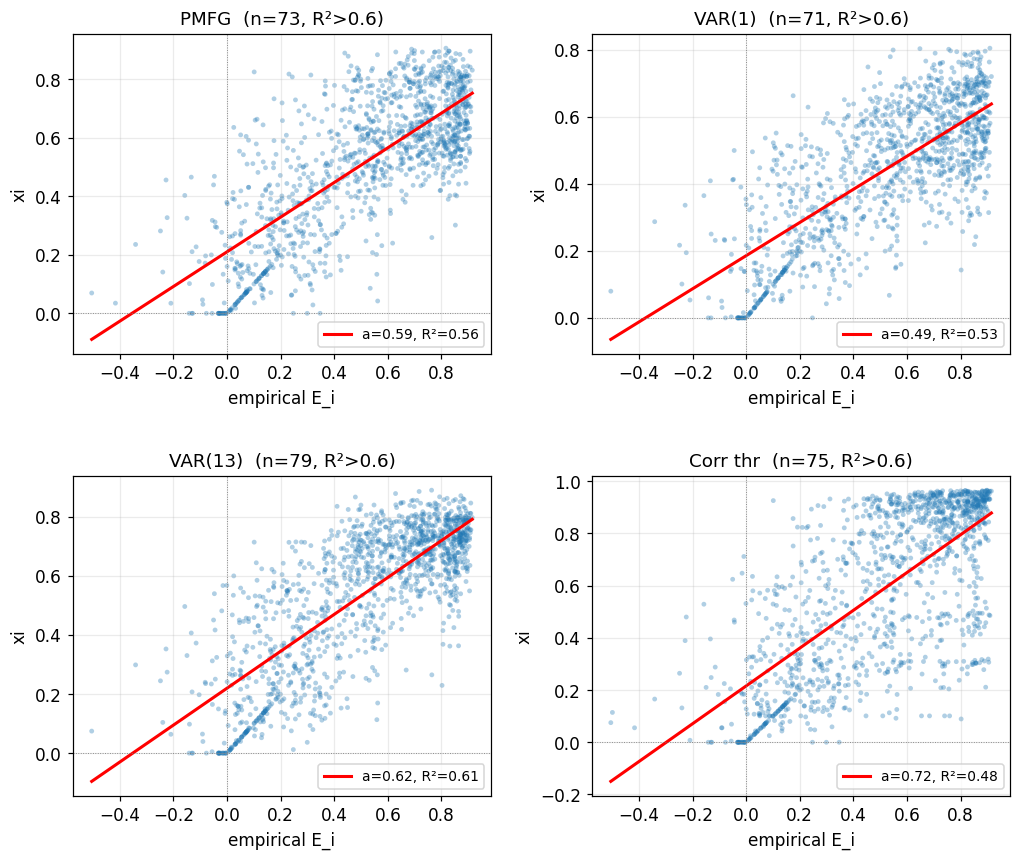

=== CAPTION [fig_3_sis_scatter] ===
SIS: predicted x_i vs empirical E_i (crisis rises, fits R² > threshold)


In [14]:
P  = pipeline.load_periods(ctx)
PK = pipeline.fit_peaks(ctx, P['crisis_map'])
coll = selection.collect_by_method(PK['peak_pd'], PK['peak_rises'])
models = config.SIS_MODELS

def _med(series):
    if not series: return np.array([])
    L = max(len(v) for v in series); M = np.full((len(series), L), np.nan)
    for r, v in enumerate(series): M[r, :len(v)] = v
    return np.nanmedian(M, axis=0)

# (a) Aggregated scatter x_i vs E_i, one column per method
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, m in zip(axes.ravel(), models):
    c = coll[m]
    if c['E_all']:
        Ec, Xc = np.concatenate(c['E_all']), np.concatenate(c['X_all'])
        ax.scatter(Ec, Xc, s=10, color='#1f77b4', alpha=0.35, edgecolors='none')
        f = linregress(Ec, Xc); xs = np.linspace(Ec.min(), Ec.max(), 50)
        ax.plot(xs, f.slope*xs + f.intercept, color='red', lw=2,
                label=f'a={f.slope:.2f}, R²={f.rvalue**2:.2f}')
        ax.legend(fontsize=9)
    ax.axhline(0, color='gray', lw=0.6, ls=':'); ax.axvline(0, color='gray', lw=0.6, ls=':')
    ax.set_xlabel('empirical E_i'); ax.set_ylabel('xi')
    ax.set_title(f'{m}  (n={len(coll[m]["r2s"])}, R²>{config.R2_SEUIL})')
fig.suptitle('SIS: predicted x_i vs empirical E_i (crisis rises, fits R² > threshold)', fontsize=13)
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []   # on garde les titres de méthode, seul le suptitre part en caption
if _sup: _sup.set_text('')
fig.subplots_adjust(hspace=0.38, wspace=0.24)
save(fig, 'fig_3_sis_scatter'); plt.show()
if _capt:
    print('=== CAPTION [fig_3_sis_scatter] ==='); print('\n'.join(_capt))


  done fig_2_0_crisis_detection.pdf  +  fig_2_0_crisis_detection.png


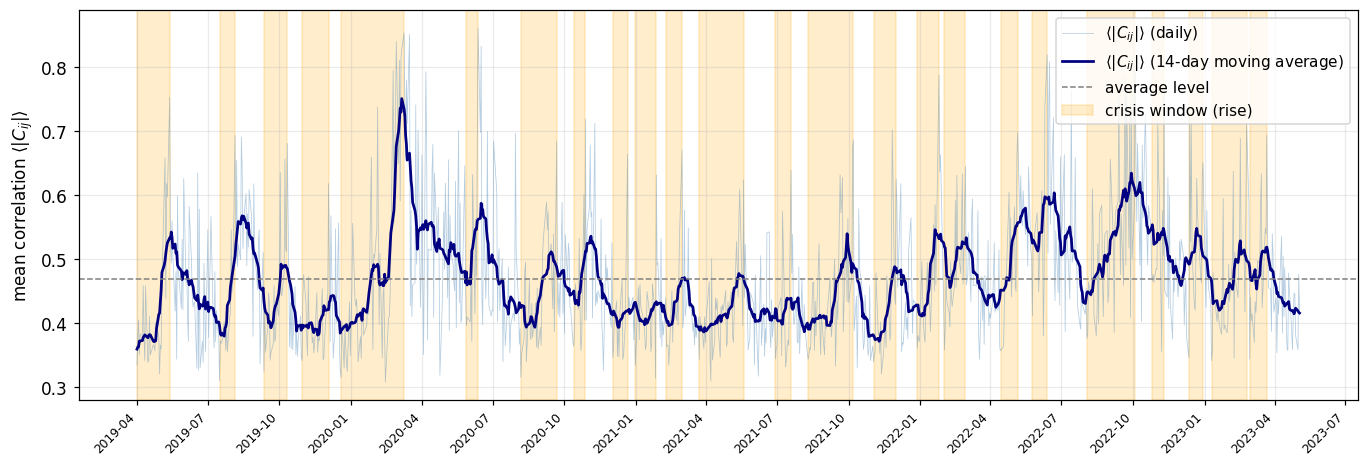

=== CAPTION [fig_2_0_crisis_detection] ===
Crisis detection. Daily average absolute correlation among assets, raw (light) and smoothed with a 14-day moving average (dark). Shaded bands mark the 24 detected crises: contiguous windows where the smoothed correlation rises for at least 12 days and exceeds the average level.


In [15]:
# ── Crisis detection (loop 1): increasing windows of the daily mean correlation ──
import matplotlib.dates as mdates
mc      = np.asarray(ctx.mc_all)               # daily <|C_ij|>
mc_sm   = np.asarray(P['mc_smooth'])           # smoothed (14-day moving average)
days    = pd.to_datetime(ctx.all_days)
iv      = P['intervals_chrono']                # crisis windows (loop 1)
mean_mc = float(ctx.mean_mc)

fig, ax = plt.subplots(figsize=(15, 4.6))
ax.plot(days, mc,    color='steelblue', lw=0.5, alpha=0.4, label=r'$\langle|C_{ij}|\rangle$ (daily)')
ax.plot(days, mc_sm, color='navy',      lw=1.8,            label=r'$\langle|C_{ij}|\rangle$ (14-day moving average)')
ax.axhline(mean_mc, color='gray', ls='--', lw=1, label='average level')
for k, (a, b) in enumerate(iv):
    ax.axvspan(days[a], days[b], color='orange', alpha=0.20,
               label='crisis window (rise)' if k == 0 else None)
ax.set_ylabel(r'mean correlation $\langle|C_{ij}|\rangle$'); ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=10, loc='upper right')
ax.set_title('Crisis detection (loop 1): rising windows of the daily mean correlation', fontsize=12)

ax.set_title('')                              # title removed (goes in the caption, printed below)
save(fig, 'fig_2_0_crisis_detection'); plt.show()
print('=== CAPTION [fig_2_0_crisis_detection] ===')
print(f'Crisis detection. Daily average absolute correlation among assets, raw (light) and smoothed '
      f'with a 14-day moving average (dark). Shaded bands mark the {len(iv)} detected crises: contiguous '
      f'windows where the smoothed correlation rises for at least 12 days and exceeds the average level.')

  done fig_3_sis_trajectoires.pdf  +  fig_3_sis_trajectoires.png


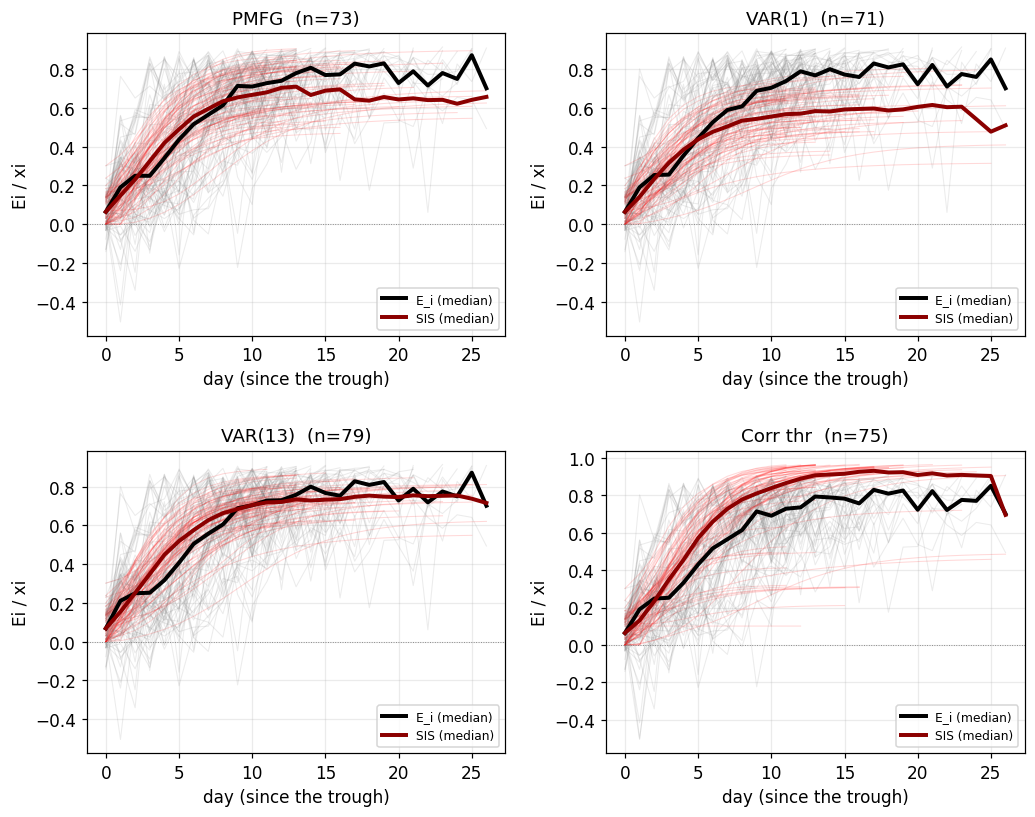

=== CAPTION [fig_3_sis_trajectoires] ===
SIS: E_i (black) and predicted x_i (red) trajectories — medians


In [16]:
# (b) Median E_i / x_i trajectories, one column per method
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
for ax, m in zip(axes.ravel(), models):
    c = coll[m]
    for E_i, x_traj in zip(c['Es'], c['Xs']):
        ok = ~np.isnan(E_i)
        ax.plot(np.arange(len(E_i))[ok], E_i[ok], color='gray', alpha=0.15, lw=0.7)
        ax.plot(np.arange(len(x_traj)), x_traj, color='red', alpha=0.15, lw=0.7)
    mE, mX = _med(c['Es']), _med(c['Xs'])
    if len(mE):
        ax.plot(np.arange(len(mE)), mE, color='black', lw=2.6, label='E_i (median)')
        ax.plot(np.arange(len(mX)), mX, color='darkred', lw=2.6, label='SIS (median)')
        ax.legend(fontsize=8)
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_xlabel('day (since the trough)'); ax.set_ylabel('Ei / xi')
    ax.set_title(f'{m}  (n={len(c["r2s"])})')
fig.suptitle('SIS: E_i (black) and predicted x_i (red) trajectories — medians', fontsize=13)
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []   # on garde les titres de méthode, seul le suptitre part en caption
if _sup: _sup.set_text('')
fig.subplots_adjust(hspace=0.38, wspace=0.24)
save(fig, 'fig_3_sis_trajectoires'); plt.show()
if _capt:
    print('=== CAPTION [fig_3_sis_trajectoires] ==='); print('\n'.join(_capt))


[cache] OK  period_data
[cache] OK  br_scan
  done fig_3_br_scan_r2agg.pdf  +  fig_3_br_scan_r2agg.png


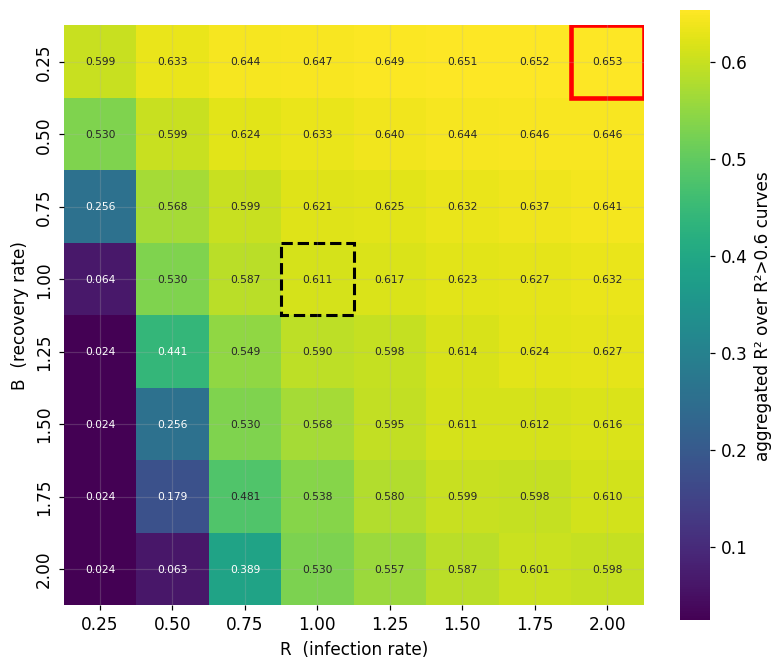

=== CAPTION [fig_3_br_scan_r2agg] ===
VAR(13) — aggregated R² of R²>0.6 curves over the (B, R) grid
max = 0.653 @ B=0.25, R=2.00 (red)   |   ref B=R=1 = 0.611 (black dashed)


In [17]:
# ── Balayage (B, R) : R² agrégé (courbes R²>0.6) pour UNE méthode ─────────────
# pipeline.run_br_scan (caché) calcule, par couple (B, R) et par méthode :
#   agg_r2_sel = R² de la régression agrégée sur le nuage poolé E_i ↔ x_i des
#                SEULES courbes bien ajustées (R² individuel > R2_SEUIL = 0.6).
# On isole UNE méthode et on cartographie une grille B×R étendue et plus fine.
BR_METHOD = 'VAR(13)'                              # méthode (parmi config.SIS_MODELS)
BR_METRIC = 'agg_r2_sel'                           # agrégé sur les courbes R²>0.6
BR_G      = np.round(np.arange(0.25, 2.01, 0.25), 2) # grille large+grossière (0.25→2.0, pas 0.25) : teste le plafond

_bpd  = pipeline.fit_main(ctx, P['intervals_chrono'], P['crisis_map'])['period_data']
_scan = pipeline.run_br_scan(ctx, P['intervals_chrono'], P['crisis_map'], _bpd, BR_G, BR_G)

Bg = Rg = BR_G
Z = np.array([[_scan[(round(float(B), 2), round(float(R), 2))][BR_METHOD][BR_METRIC]
               for R in Rg] for B in Bg])            # Z[i, j] : ligne = B, colonne = R
iB, jR = np.unravel_index(np.nanargmax(Z), Z.shape)
Bstar, Rstar, r2star = float(Bg[iB]), float(Rg[jR]), float(Z[iB, jR])
_has1 = (1.0 in set(np.round(Bg, 2))) and (1.0 in set(np.round(Rg, 2)))
if _has1:
    _i1 = int(np.where(np.round(Bg, 2) == 1.0)[0][0]); _j1 = int(np.where(np.round(Rg, 2) == 1.0)[0][0])

fig, ax = plt.subplots(figsize=(8.5, 7.2))
_annot = len(Bg) <= 8                                # annotations lisibles seulement si grille petite
sns.heatmap(Z, ax=ax, cmap='viridis', annot=_annot, fmt='.3f', square=True,
            annot_kws={'fontsize': 7},
            xticklabels=[f'{r:.2f}' for r in Rg], yticklabels=[f'{b:.2f}' for b in Bg],
            cbar_kws={'label': f'aggregated R² over R²>0.6 curves'})
ax.add_patch(plt.Rectangle((jR, iB), 1, 1, fill=False, edgecolor='red', lw=3))          # max
if _has1:
    ax.add_patch(plt.Rectangle((_j1, _i1), 1, 1, fill=False, edgecolor='black', lw=2, ls='--'))  # réf B=R=1
ax.set_xlabel("R  (infection rate)"); ax.set_ylabel("B  (recovery rate)")
ax.set_title(f'{BR_METHOD} — aggregated R² of R²>0.6 curves over the (B, R) grid\n'
             f'max = {r2star:.3f} @ B={Bstar:.2f}, R={Rstar:.2f} (red)'
             + (f'   |   ref B=R=1 = {Z[_i1, _j1]:.3f} (black dashed)' if _has1 else ''))
# titre retiré de la figure (il ira dans le \caption) ; sorti en légende imprimée
_capt = [a.get_title() for a in fig.axes if a.get_title()]
for a in fig.axes: a.set_title('')
save(fig, 'fig_3_br_scan_r2agg'); plt.show()
if _capt:
    print('=== CAPTION [fig_3_br_scan_r2agg] ==='); print(''.join(_capt))

## 4 — SIS validation & falsification (from `synthese.ipynb`)

Report outputs for the `synthese.ipynb` analyses that were still missing from `Fig/rapport/`.
Figures are saved as PDF + 300 dpi PNG; tables are exported as **LaTeX (`.tex`) + `.csv`**.

| § | Output | Files |
|---|--------|-------|
| 4.1 | Average clustering over time (scale-free threshold) | `fig_4_1_clustering_crises`, `tab_4_1_clustering_periods` |
| 4.2 | Network signals λ_max/⟨λ⟩, ⟨\|C\|⟩, clustering vs mean return | `fig_4_2_network_signals` |
| 4.3 | (B, R) grid: aggregated R² of selected fits, 4 methods | `fig_4_3_br_grid_methods` |
| 4.4 | SIS in vs out of collective crises (off-crisis null) | `fig_4_4_sis_off_crisis`, `tab_4_4_sis_off_crisis` |
| 4.4 | Full R² distributions in vs out of collective crises | `fig_4_4b_r2_hist_offcrisis` |
| 4.5 | Assets retained per method × period + agreement | `fig_4_5_method_agreement`, `tab_4_5_method_agreement` |
| 4.6 | Louvain communities: crisis ratio per community | `fig_4_6_community_crisis_ratio`, `tab_4_6_communities` |
| 4.6 | Period networks (ForceAtlas2), crisis assets as stars | `fig_4_7_community_graphs` |
| 4.7 | Endo/exo score (branching ratio n) per period | `fig_4_8_endo_exo`, `tab_4_8_endo_exo` |
| 4.8 | Falsifiability — test A: fit blind to topology | `fig_4_9_falsifiability_testA`, `tab_4_9_testA` |
| 4.8 | Falsifiability — test B: local vs global transmission | `fig_4_10_falsifiability_testB`, `tab_4_10_testB` |
| 4.8 | Falsifiability — test C: reduced network | `fig_4_11_falsifiability_testC`, `tab_4_11_testC` |

All heavy computations are read from `cache/` (same signatures as `synthese.ipynb`).

In [18]:
# ── Part 4 · shared context (same objects as synthese.ipynb, all cached) ──────
import warnings
import matplotlib.dates as mdates
from cache import disk_cache, sig_of
import sis

peak_rises = PK['peak_rises']                  # 17 trough->peak crisis rises
peak_pd    = PK['peak_pd']                     # cached SIS fits per rise
crisis_map = P['crisis_map']
SP   = pipeline.spectral(ctx)
diag = SP['diag']
all_days = pd.to_datetime(ctx.all_days)
# the trailing spectral window (WINDOW_SPEC) is stamped at its end -> recentre it
_endpos = np.arange(len(diag)) * config.STEP_SPEC + config.WINDOW_SPEC - 1
diag_x  = ctx.data.index[_endpos - (config.WINDOW_SPEC - 1) // 2]
idx_t   = real.index

_saved_tables = []
def save_table(df, name, index=False):
    """Export a report table as LaTeX + CSV into Fig/rapport/."""
    (RAPPORT_DIR / f'{name}.csv').write_text(df.to_csv(index=index))
    (RAPPORT_DIR / f'{name}.tex').write_text(
        df.to_latex(index=index, escape=True, float_format=lambda v: f'{v:g}'))
    _saved_tables.append(name)
    print(f'  done {name}.tex  +  {name}.csv')

print(f'{len(peak_rises)} crisis rises, diag: {len(diag)} points')

[cache] OK  spectral_diag
17 crisis rises, diag: 1007 points


### 4.1 — Average clustering over time (scale-free threshold)

For each 1-day window (13 bars) we pick the minimal threshold ρc making the degree
distribution convex (scale-free proxy), then measure the average weighted clustering of the
thresholded graph. Clustering spikes line up with the crisis rises.

[cache] OK  clustering_curve
  done fig_4_1_clustering_crises.pdf  +  fig_4_1_clustering_crises.png


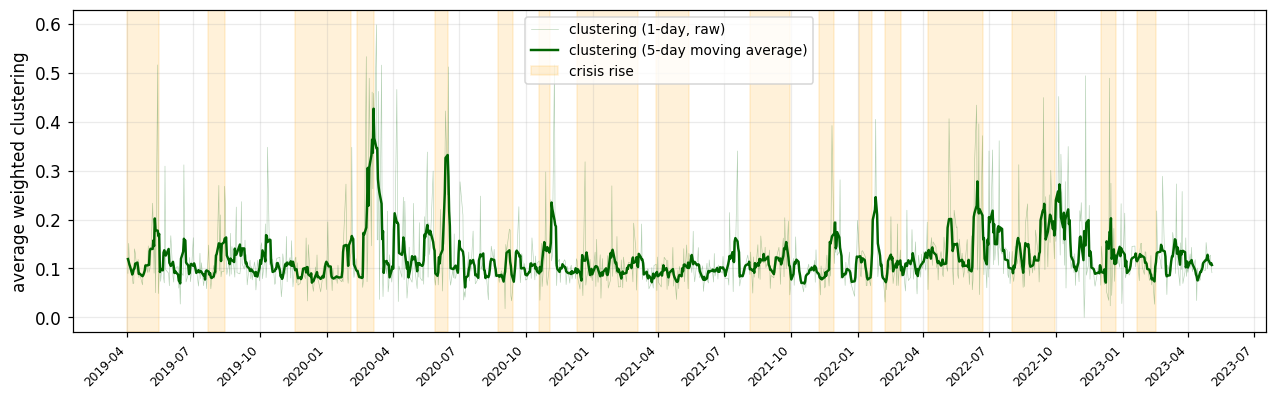

=== CAPTION [fig_4_1_clustering_crises] ===
Average weighted clustering of the correlation network thresholded at the minimal scale-free threshold rho_c, computed on 1-day windows (light: raw; dark: 5-day moving average). Orange bands mark the 17 crisis rises: clustering spikes during collective crises.


In [19]:
# ── 4.1 · clustering curve (1-day windows, scale-free threshold) — cached ─────
def scale_free_threshold(C, start=0.5, step=0.01, cap=0.95):
    """Minimal threshold rho_c making the degree distribution convex."""
    rc = start
    while rc <= cap:
        A = (np.abs(C) >= rc).astype(int); np.fill_diagonal(A, 0); deg = A.sum(1)
        counts = np.bincount(deg, minlength=int(deg.max()) + 1).astype(float)
        kmax = int(np.quantile(deg, 0.9))
        if (kmax < 2) or np.all(np.diff(counts[:kmax + 1], 2) >= 0):
            return rc
        rc = round(rc + step, 2)
    return cap

def clustering_at_sft(C):
    """(rho_c, average weighted clustering) of the graph thresholded at the scale-free threshold."""
    rc = scale_free_threshold(C)
    Wt = np.abs(C) * (np.abs(C) >= rc); np.fill_diagonal(Wt, 0.0)
    return rc, nx.average_clustering(nx.from_numpy_array(Wt), weight='weight')

SHORT = 13                                       # 1 trading day of 30-min bars
def _clustering_curve():
    cl, cd = [], []
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        for i in range(len(arr) // SHORT):
            sub = arr[i * SHORT:(i + 1) * SHORT]
            _, c = clustering_at_sft(np.nan_to_num(np.corrcoef(sub.T)))
            cl.append(c); cd.append(idx_t[(i + 1) * SHORT - 1])
    return np.array(cl), pd.to_datetime(cd)

clus, cdates = disk_cache('clustering_curve', sig_of(str(N), str(len(arr)), str(SHORT), 'v1'),
                          _clustering_curve)
clus_disp = pd.Series(clus).rolling(5, center=True, min_periods=1).mean().values  # display only

fig, ax = plt.subplots(figsize=(14, 3.8))
ax.plot(cdates, clus, color='darkgreen', lw=0.4, alpha=0.3, label='clustering (1-day, raw)')
ax.plot(cdates, clus_disp, color='darkgreen', lw=1.6, label='clustering (5-day moving average)')
for k, (pa, pb) in enumerate(peak_rises):
    ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.15,
               label='crisis rise' if k == 0 else None)
ax.set_ylabel('average weighted clustering'); ax.grid(alpha=0.25); ax.legend(fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
save(fig, 'fig_4_1_clustering_crises'); plt.show()
print('=== CAPTION [fig_4_1_clustering_crises] ===')
print('Average weighted clustering of the correlation network thresholded at the minimal scale-free '
      'threshold rho_c, computed on 1-day windows (light: raw; dark: 5-day moving average). '
      f'Orange bands mark the {len(peak_rises)} crisis rises: clustering spikes during collective crises.')

In [20]:
# ── 4.1 · table: rho_c and clustering per crisis rise ─────────────────────────
rows = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for (pa, pb) in peak_rises:
        d0, d1 = all_days[pa], all_days[pb]
        obs = (idx_t >= d0) & (idx_t <= d1)
        rc, clp = clustering_at_sft(np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T)))
        inwin = (cdates >= d0) & (cdates <= d1)
        cmin = float(clus[inwin].min()) if inwin.any() else np.nan
        rows.append({'start': str(d0)[:10], 'end': str(d1)[:10],
                     'n crisis assets': len(peak_pd[(pa, pb)][0]), 'rho_c': rc,
                     'clustering (period)': round(clp, 3),
                     'clustering min (window)': round(cmin, 3)})
tab41 = pd.DataFrame(rows)
display(tab41)
save_table(tab41, 'tab_4_1_clustering_periods')

,start,end,n crisis assets,rho_c,clustering (period),clustering min (window)
0,2019-04-01,2019-05-15,73,0.69,0.154,0.049
1,2019-07-22,2019-08-14,38,0.79,0.111,0.058
2,2019-11-19,2020-02-04,19,0.62,0.102,0.034
3,2020-02-11,2020-03-06,139,0.89,0.111,0.061
4,2020-05-29,2020-06-16,94,0.88,0.106,0.054
5,2020-08-24,2020-09-14,5,0.76,0.154,0.018
6,2020-10-19,2020-11-04,25,0.80,0.132,0.035
7,2020-12-10,2021-03-04,6,0.61,0.124,0.039
8,2021-03-29,2021-05-13,8,0.69,0.126,0.037
9,2021-08-05,2021-09-29,37,0.74,0.096,0.050


  done tab_4_1_clustering_periods.tex  +  tab_4_1_clustering_periods.csv


### 4.2 — Network signals vs mean return

λ_max/⟨λ⟩, ⟨|C_ij|⟩ and the clustering curve, each overlaid with the mean return ⟨r⟩
(right axis). R = Pearson correlation between the signal and ⟨r⟩ (series realigned by interpolation).

  done fig_4_2_network_signals.pdf  +  fig_4_2_network_signals.png


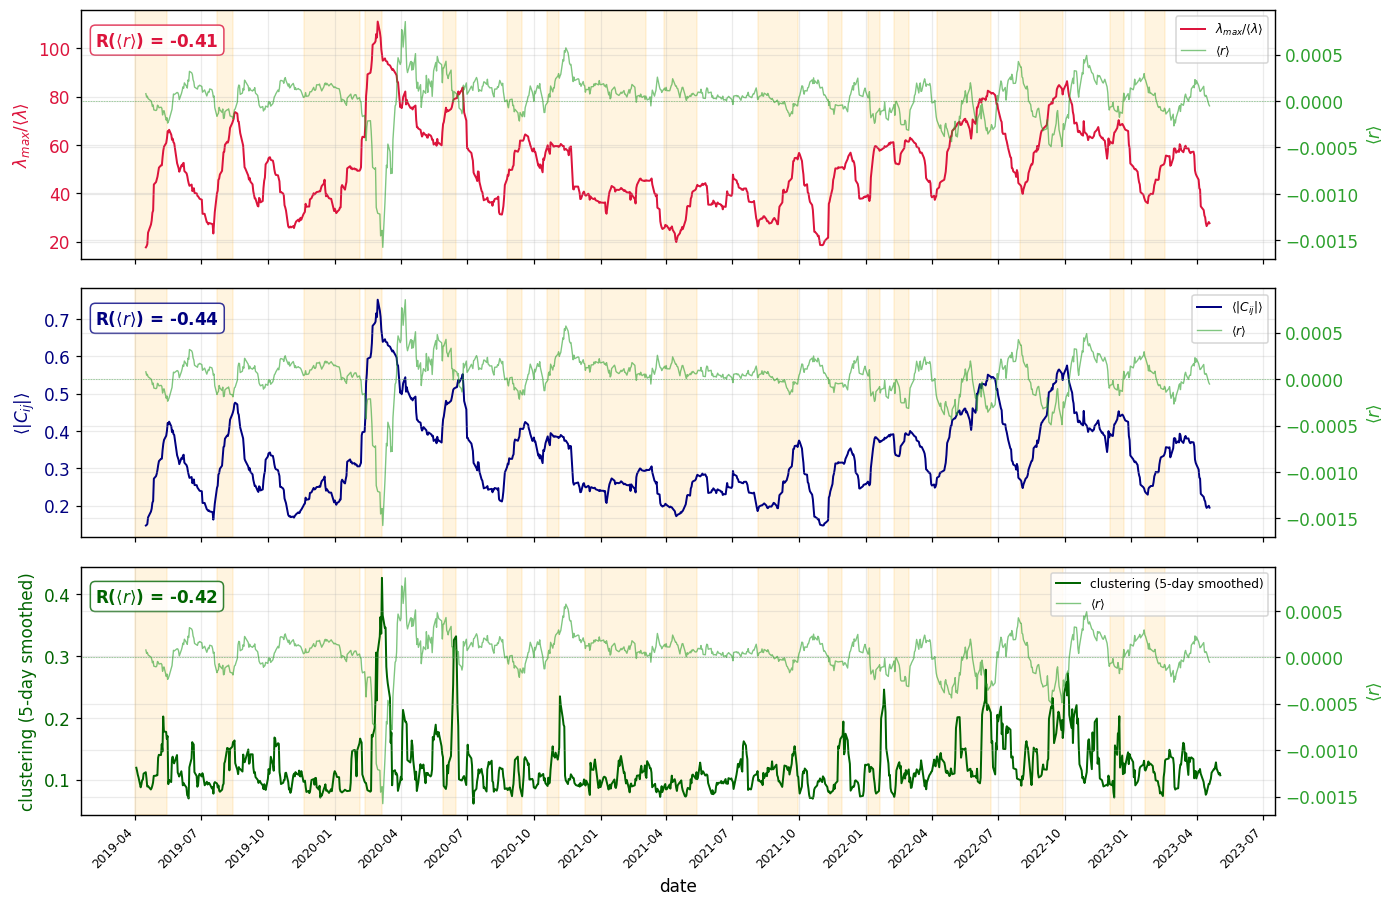

=== CAPTION [fig_4_2_network_signals] ===
Network signals over time, each overlaid with the mean return <r> (right axis, green): (top) spectral ratio lambda_max/<lambda>, (middle) mean absolute correlation <|C_ij|>, (bottom) average clustering at the scale-free threshold (5-day smoothed). R = Pearson correlation between each signal and <r>; orange bands = crisis rises. All three network signals are anticorrelated with the mean return: they rise when the market falls.


In [21]:
# ── 4.2 · three network signals, each vs the mean return ──────────────────────
def _pearsonR(x_sig, y_sig, x_r, y_r):
    """Pearson R between a signal and <r>, realigned by interpolation."""
    xs = mdates.date2num(np.asarray(x_sig)); xr = mdates.date2num(np.asarray(x_r))
    yr = np.interp(xs, xr, y_r)
    m = np.isfinite(y_sig) & np.isfinite(yr)
    return np.corrcoef(np.asarray(y_sig)[m], yr[m])[0, 1] if m.sum() > 2 else np.nan

R_eig  = _pearsonR(diag_x, diag['ratio_eig'], diag_x, diag['mean_return'])
R_corr = _pearsonR(diag_x, diag['mean_corr'], diag_x, diag['mean_return'])
R_clus = _pearsonR(cdates, clus_disp,        diag_x, diag['mean_return'])

panels = [
    (diag_x, diag['ratio_eig'], 'crimson',   r'$\lambda_{max}/\langle\lambda\rangle$', R_eig),
    (diag_x, diag['mean_corr'], 'navy',      r'$\langle|C_{ij}|\rangle$',              R_corr),
    (cdates, clus_disp,         'darkgreen', 'clustering (5-day smoothed)',            R_clus),
]
fig, axes = plt.subplots(3, 1, figsize=(14, 9.5), sharex=True)
for ax, (x, y, color, lab, R) in zip(axes, panels):
    ax.plot(x, y, color=color, lw=1.3, label=lab)
    ax.set_ylabel(lab, color=color); ax.tick_params(axis='y', labelcolor=color)
    ax.grid(alpha=0.25)
    ax.text(0.012, 0.92, f'R($\\langle r\\rangle$) = {R:+.2f}', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color=color, va='top',
            bbox=dict(boxstyle='round', fc='white', ec=color, alpha=0.8))
    axb = ax.twinx()
    axb.plot(diag_x, diag['mean_return'], color='tab:green', lw=0.9, alpha=0.6, label=r'$\langle r\rangle$')
    axb.axhline(0, color='tab:green', lw=0.4, ls=':'); axb.set_ylabel(r'$\langle r\rangle$', color='tab:green')
    axb.tick_params(axis='y', labelcolor='tab:green')
    for (pa, pb) in peak_rises:
        ax.axvspan(all_days[pa], all_days[pb], color='orange', alpha=0.12)
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper right')
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[-1].set_xlabel('date')
fig.subplots_adjust(hspace=0.12)
save(fig, 'fig_4_2_network_signals'); plt.show()
print('=== CAPTION [fig_4_2_network_signals] ===')
print('Network signals over time, each overlaid with the mean return <r> (right axis, green): '
      '(top) spectral ratio lambda_max/<lambda>, (middle) mean absolute correlation <|C_ij|>, '
      '(bottom) average clustering at the scale-free threshold (5-day smoothed). '
      'R = Pearson correlation between each signal and <r>; orange bands = crisis rises. '
      'All three network signals are anticorrelated with the mean return: they rise when the market falls.')

### 4.3 — (B, R) grid: aggregated R² of the selected fits

`agg_r2_sel` = R² of the pooled E_i ↔ x_i cloud restricted to fits with individual R² > 0.6,
on an extended (B, R) grid, per contagion network. The maximum is a degenerate low-B / high-R
corner: the ratio-invariant `agg_r2_all` barely moves, so **B = R = 1 remains the canonical choice**.

[cache] OK  br_grid2d_pk


  done fig_4_3_br_grid_methods.pdf  +  fig_4_3_br_grid_methods.png


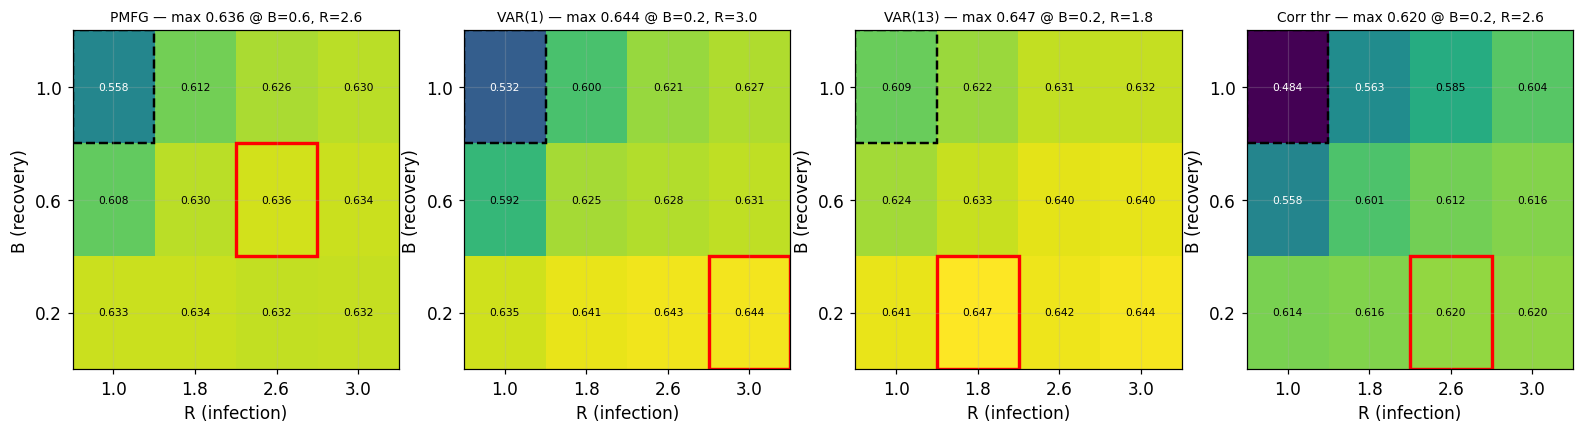

=== CAPTION [fig_4_3_br_grid_methods] ===
Aggregated R² of the pooled E_i vs x_i cloud restricted to selected fits (individual R²>0.6) on the (B, R) grid, one panel per contagion network. Red square = maximum, black dashed = reference B=R=1. The optimum is a degenerate low-B / high-R corner: the invariant aggregated R² over ALL fits barely moves with the ratio (checked on the diagonal to ~3e-4), so the gain is an artefact of the moving selected subset and B=R=1 remains the canonical choice.


In [22]:
# ── 4.3 · (B, R) grid, aggregated R² of selected fits (cached: br_grid2d_pk) ──
import os
from joblib import Parallel, delayed
from matplotlib.patches import Rectangle
from scipy.stats import linregress

B_GRID = [0.2, 0.6, 1.0]
R_GRID = [1.0, 1.8, 2.6, 3.0]
PTS = [(round(b, 2), round(r, 2)) for b in B_GRID for r in R_GRID] + [(0.8, 0.8), (1.2, 1.2)]

def _grid_one(cache, B, R):
    """Per method/window: pooled (E,x) over all fits, over selected fits, and the R²>thr set."""
    out = {m: ([], [], [], [], set()) for m in config.SIS_MODELS}
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 3:
            continue
        for m in config.SIS_MODELS:
            xt = sis.integrate_fast(d, gi, ctx.A_sis[m], B=B, R=R)
            E, X = E_i[ok], xt[ok]
            Ea, Xa, Es, Xs, S = out[m]
            Ea.append(E); Xa.append(X)
            if linregress(E, X).rvalue ** 2 > config.R2_SEUIL:
                Es.append(E); Xs.append(X); S.add(gi)
    return out

def _agg(Ed, Xd):
    return float(linregress(np.concatenate(Ed), np.concatenate(Xd)).rvalue ** 2) if Ed else np.nan

def _compute_grid():
    tasks = [(p, (pa, pb)) for p in PTS for (pa, pb) in peak_rises]
    parts = Parallel(n_jobs=min(len(tasks), os.cpu_count()))(
        delayed(_grid_one)(peak_pd[(pa, pb)][0], *p) for (p, (pa, pb)) in tasks)
    sets = {p: {m: set() for m in config.SIS_MODELS} for p in PTS}
    poolA = {p: {m: ([], []) for m in config.SIS_MODELS} for p in PTS}
    poolS = {p: {m: ([], []) for m in config.SIS_MODELS} for p in PTS}
    for (p, _), part in zip(tasks, parts):
        for m in config.SIS_MODELS:
            Ea, Xa, Es, Xs, S = part[m]
            poolA[p][m][0].extend(Ea); poolA[p][m][1].extend(Xa)
            poolS[p][m][0].extend(Es); poolS[p][m][1].extend(Xs); sets[p][m] |= S
    agg_all = {p: {m: _agg(*poolA[p][m]) for m in config.SIS_MODELS} for p in PTS}
    agg_sel = {p: {m: _agg(*poolS[p][m]) for m in config.SIS_MODELS} for p in PTS}
    return dict(agg_all=agg_all, agg_sel=agg_sel, sets=sets)

_sig = 'brgrid2d_' + sig_of(repr(sorted(peak_rises)), repr(PTS), str(config.R2_SEUIL))
GRID = disk_cache('br_grid2d_pk', _sig, _compute_grid)
agg_all, agg_sel, br_sets = GRID['agg_all'], GRID['agg_sel'], GRID['sets']

vmin = min(agg_sel[(b, r)][m] for b in B_GRID for r in R_GRID for m in config.SIS_MODELS)
vmax = max(agg_sel[(b, r)][m] for b in B_GRID for r in R_GRID for m in config.SIS_MODELS)
bi1, rj1 = B_GRID.index(1.0), R_GRID.index(1.0)
fig, axes = plt.subplots(1, len(config.SIS_MODELS), figsize=(4.4 * len(config.SIS_MODELS), 4.0))
for ax, m in zip(np.atleast_1d(axes), config.SIS_MODELS):
    M = np.array([[agg_sel[(b, r)][m] for r in R_GRID] for b in B_GRID])   # rows=B, cols=R
    im = ax.imshow(M, origin='lower', aspect='auto', cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(R_GRID))); ax.set_xticklabels(R_GRID)
    ax.set_yticks(range(len(B_GRID))); ax.set_yticklabels(B_GRID)
    ax.set_xlabel('R (infection)'); ax.set_ylabel('B (recovery)')
    for i in range(len(B_GRID)):
        for j in range(len(R_GRID)):
            ax.text(j, i, f'{M[i, j]:.3f}', ha='center', va='center', fontsize=7,
                    color='white' if M[i, j] < (vmin + vmax) / 2 else 'black')
    bi, rj = np.unravel_index(np.argmax(M), M.shape)
    ax.add_patch(Rectangle((rj - 0.5, bi - 0.5), 1, 1, fill=False, edgecolor='red', lw=2.2))
    ax.add_patch(Rectangle((rj1 - 0.5, bi1 - 0.5), 1, 1, fill=False, edgecolor='black', lw=1.6, ls='--'))
    ax.set_title(f'{m} — max {M.max():.3f} @ B={B_GRID[bi]}, R={R_GRID[rj]}', fontsize=9)
save(fig, 'fig_4_3_br_grid_methods'); plt.show()
print('=== CAPTION [fig_4_3_br_grid_methods] ===')
print('Aggregated R² of the pooled E_i vs x_i cloud restricted to selected fits (individual R²>0.6) '
      'on the (B, R) grid, one panel per contagion network. Red square = maximum, black dashed = '
      'reference B=R=1. The optimum is a degenerate low-B / high-R corner: the invariant aggregated '
      'R² over ALL fits barely moves with the ratio (checked on the diagonal to ~3e-4), so the gain '
      'is an artefact of the moving selected subset and B=R=1 remains the canonical choice.')

In [23]:
# ── 4.3 · optimal (B, R) per method + per-period retained sets (cached) ───────
opt_br = {m: max((p for p in PTS if not np.isnan(agg_sel[p][m])), key=lambda p: agg_sel[p][m])
          for m in config.SIS_MODELS}
print('optimal (B, R) per method (argmax agg_r2_sel):', opt_br)

def _ret_pm_br(cache, m, B, R):
    s = set()
    for gi, d in cache.items():
        E_i = d['E_i']; ok = ~np.isnan(E_i)
        if ok.sum() < 3:
            continue
        xt = sis.integrate_fast(d, gi, ctx.A_sis[m], B=B, R=R)
        if linregress(E_i[ok], xt[ok]).rvalue ** 2 > config.R2_SEUIL:
            s.add(gi)
    return s

def _compute_opt_sets():
    return {(pa, pb): {m: _ret_pm_br(peak_pd[(pa, pb)][0], m, *opt_br[m]) for m in config.SIS_MODELS}
            for (pa, pb) in peak_rises}

_sig = 'optsets_' + sig_of(repr(sorted(peak_rises)), repr(sorted(opt_br.items())), str(config.R2_SEUIL))
opt_sets_pm = disk_cache('opt_sets_pm', _sig, _compute_opt_sets)

optimal (B, R) per method (argmax agg_r2_sel): {'PMFG': (0.6, 2.6), 'VAR(1)': (0.2, 3.0), 'VAR(13)': (0.2, 1.8), 'Corr thr': (0.2, 2.6)}
[cache] OK  opt_sets_pm


### 4.4 — Off-crisis null: does the SIS fit individual rises outside collective crises?

For every asset retained in at least one collective crisis (R² > 0.6), we look for individual
rises of its E_i **outside** all collective crises (same detectors) and refit the SIS there.

[cache] OK  null_offcrisis
72 retained assets -> 35 individual off-crisis rises


,method,% R²>0.6 in crisis,% R²>0.6 off crisis,ratio (in/off),n (in),n (off),median R² (in),median R² (off)
0,PMFG,18.5,8.6,2.2,395,35,0.256,0.337
1,VAR(1),18.0,5.7,3.1,395,35,0.248,0.344
2,VAR(13),20.0,8.6,2.3,395,35,0.261,0.343
3,Corr thr,19.0,8.6,2.2,395,35,0.263,0.336


  done tab_4_4_sis_off_crisis.tex  +  tab_4_4_sis_off_crisis.csv
  done fig_4_4_sis_off_crisis.pdf  +  fig_4_4_sis_off_crisis.png


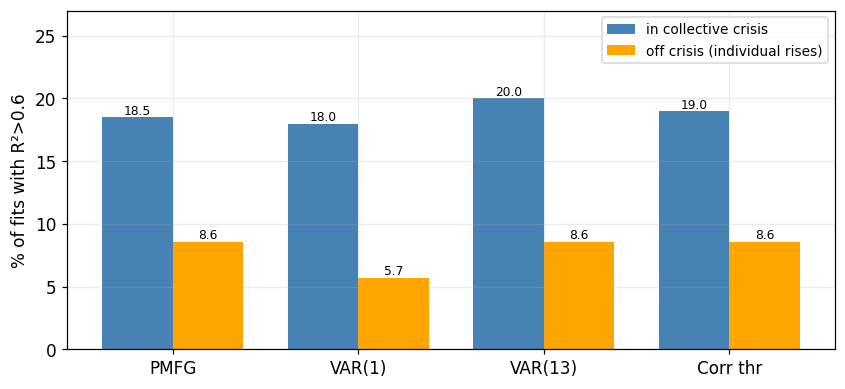

=== CAPTION [fig_4_4_sis_off_crisis] ===
Share of good SIS fits (R²>0.6) inside collective crises (blue) vs on individual E_i rises outside any collective crisis (orange), per contagion network. In crisis the share is 18-20% against 6-9% off crisis (~2-3x): the SIS fits collective crises markedly better, without being fully specific to them.


In [24]:
# ── 4.4 · off-crisis fits (cached: null_offcrisis) + table + bar chart ────────
from periods import asset_runs, strong_rise

def _build_entry(gi, a, b):
    # (E_i, x0, n_days) entry built exactly like cache_signed, on run (a, b) of asset gi
    res = strong_rise(ctx.E_daily_all[gi, a:b + 1])
    if res is None:
        return None
    A0, B0 = a + res[2], a + res[3]
    days_p = list(ctx.all_days[A0:B0 + 1])
    dp = ctx.data[np.isin(ctx.data.index.date, days_p)].copy(); dp['day'] = dp.index.date
    days_s = sorted(dp['day'].unique()); n_days = len(days_s)
    Es = np.full((N, n_days), np.nan)
    for k, d in enumerate(days_s):
        chunk = dp[dp['day'] == d].drop(columns=['day']).values
        if len(chunk) < 3:
            continue
        C = np.nan_to_num(np.corrcoef(chunk.T), nan=0.0); np.fill_diagonal(C, 0)
        Es[:, k] = C.sum(axis=1) / (N - 1)
    valid = np.where(np.any(~np.isnan(Es), axis=0))[0]
    if len(valid) == 0:
        return None
    return dict(E_i=Es[gi], x0=Es[:, valid[0]], n_days=n_days)

def _overlaps_collective(a, b):
    return any(a <= pb and b >= pa for (pa, pb) in peak_rises)

selected = set()
coll_r2 = {m: [] for m in config.SIS_MODELS}
for (pa, pb) in peak_rises:
    for m in config.SIS_MODELS:
        for gi, sl in peak_pd[(pa, pb)][1][m][1].items():
            if sl['r2'] > config.R2_SEUIL:
                selected.add(gi)
for (pa, pb) in peak_rises:
    for m in config.SIS_MODELS:
        for gi, sl in peak_pd[(pa, pb)][1][m][1].items():
            if gi in selected:
                coll_r2[m].append(sl['r2'])

def _compute_null():
    null_r2 = {m: [] for m in config.SIS_MODELS}; wins = []
    for gi in sorted(selected):
        for (a, b) in asset_runs(crisis_map[gi]):
            if _overlaps_collective(a, b):
                continue
            d = _build_entry(gi, a, b)
            if d is None:
                continue
            E_i = d['E_i']; ok = ~np.isnan(E_i)
            if ok.sum() < 3:
                continue
            wins.append((gi, a, b))
            for m in config.SIS_MODELS:
                xt = sis.integrate(d, gi, ctx.A_sis[m])
                null_r2[m].append(linregress(E_i[ok], xt[ok]).rvalue ** 2)
    return dict(null_r2=null_r2, wins=wins)

_sig = 'off_' + sig_of(repr(sorted(selected)), repr(sorted(peak_rises)), str(config.R2_SEUIL))
null = disk_cache('null_offcrisis', _sig, _compute_null)
null_r2 = null['null_r2']
print(f'{len(selected)} retained assets -> {len(null["wins"])} individual off-crisis rises')

rows = []
for m in config.SIS_MODELS:
    c = np.array(coll_r2[m]); nc = np.array(null_r2[m])
    pc, ph = 100 * np.mean(c > config.R2_SEUIL), 100 * np.mean(nc > config.R2_SEUIL)
    rows.append({'method': m,
                 '% R²>0.6 in crisis': round(pc, 1),
                 '% R²>0.6 off crisis': round(ph, 1),
                 'ratio (in/off)': round(pc / ph, 1) if ph else np.inf,
                 'n (in)': len(c), 'n (off)': len(nc),
                 'median R² (in)': round(float(np.median(c)), 3),
                 'median R² (off)': round(float(np.median(nc)), 3)})
tab44 = pd.DataFrame(rows)
display(tab44)
save_table(tab44, 'tab_4_4_sis_off_crisis')

allc = np.concatenate([np.array(coll_r2[m]) for m in config.SIS_MODELS])
alln = np.concatenate([np.array(null_r2[m]) for m in config.SIS_MODELS])
p_coll, p_off = 100 * np.mean(allc > config.R2_SEUIL), 100 * np.mean(alln > config.R2_SEUIL)

labels = config.SIS_MODELS
en  = [100 * np.mean(np.array(coll_r2[m]) > config.R2_SEUIL) for m in config.SIS_MODELS]
off = [100 * np.mean(np.array(null_r2[m]) > config.R2_SEUIL) for m in config.SIS_MODELS]
x = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - w/2, en,  w, color='steelblue', label='in collective crisis')
b2 = ax.bar(x + w/2, off, w, color='orange',    label='off crisis (individual rises)')
ax.bar_label(b1, fmt='%.1f', fontsize=8); ax.bar_label(b2, fmt='%.1f', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('% of fits with R²>0.6')
ax.set_ylim(0, max(en) * 1.35)
ax.legend(fontsize=9); ax.grid(alpha=0.25, axis='y')
save(fig, 'fig_4_4_sis_off_crisis'); plt.show()
print('=== CAPTION [fig_4_4_sis_off_crisis] ===')
print('Share of good SIS fits (R²>0.6) inside collective crises (blue) vs on individual E_i rises '
      'outside any collective crisis (orange), per contagion network. In crisis the share is '
      f'{min(en):.0f}-{max(en):.0f}% against {min(off):.0f}-{max(off):.0f}% off crisis (~2-3x): '
      'the SIS fits collective crises markedly better, without being fully specific to them.')

  done fig_4_4b_r2_hist_offcrisis.pdf  +  fig_4_4b_r2_hist_offcrisis.png


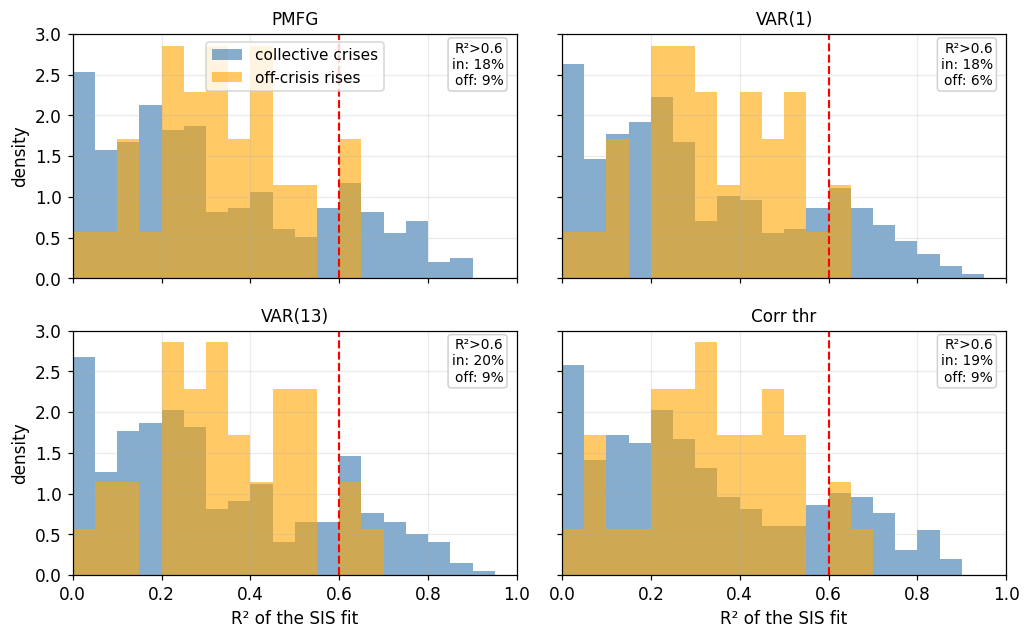

=== CAPTION [fig_4_4b_r2_hist_offcrisis] ===
SIS fit quality in vs out of collective crises — full R² distributions, red dashed line: selection threshold R² = 0.6


In [25]:
# ── 4.4 bis · distributions des R² : EN crise collective vs HORS crise ────────
# Histogrammes complets (pas seulement la part > 0.6) : le seuil R2_SEUIL = 0.6
# tombe là où la distribution hors-crise ne garde presque plus de masse alors
# que la distribution en-crise en garde une part substantielle.
bins = np.linspace(0, 1, 21)
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.6), sharex=True, sharey=True)
axes = axes.ravel()
for j, m in enumerate(config.SIS_MODELS):
    ax = axes[j]
    c, nc = np.array(coll_r2[m]), np.array(null_r2[m])
    ax.hist(c,  bins=bins, density=True, color='steelblue', alpha=0.65,
            label='collective crises')
    ax.hist(nc, bins=bins, density=True, color='orange', alpha=0.60,
            label='off-crisis rises')
    ax.axvline(config.R2_SEUIL, color='red', ls='--', lw=1.4)
    pc, ph = 100 * np.mean(c > config.R2_SEUIL), 100 * np.mean(nc > config.R2_SEUIL)
    ax.text(0.97, 0.97, f'R²>{config.R2_SEUIL}\nin: {pc:.0f}%\noff: {ph:.0f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#cccccc', alpha=0.9))
    ax.set_title(m, fontsize=11); ax.set_xlim(0, 1)
    if j % 2 == 0:
        ax.set_ylabel('density')
    if j >= 2:
        ax.set_xlabel('R² of the SIS fit')
    if j == 0:
        ax.legend(fontsize=10, loc='upper center')
fig.suptitle('SIS fit quality in vs out of collective crises — full R² distributions, '
             f'red dashed line: selection threshold R² = {config.R2_SEUIL}', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
# les titres de panneaux (noms de méthode) restent sur la figure ; seul le
# suptitle part en légende LaTeX
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_4_4b_r2_hist_offcrisis'); plt.show()
if _capt:
    print('=== CAPTION [fig_4_4b_r2_hist_offcrisis] ==='); print(' | '.join(_capt))

### 4.5 — Assets retained per method × period, agreement between methods

Number of assets retained (SIS fit R² > 0.6, B = R = 1) per crisis rise and per contagion
network, plus union / intersection and the distribution of the agreement.

,period,PMFG,VAR(1),VAR(13),Corr thr,union,intersection,common >=3,% intersection
0,2019-04-01 - 2019-05-15,14,13,16,16,18,11,14,61.1
1,2019-07-22 - 2019-08-14,5,5,5,5,5,5,5,100.0
2,2020-02-11 - 2020-03-06,44,42,46,44,48,38,44,79.2
3,2020-05-29 - 2020-06-16,5,5,5,5,6,4,5,66.7
4,2022-01-03 - 2022-01-20,0,2,2,0,2,0,0,0.0
5,2022-02-08 - 2022-03-01,1,0,0,1,1,0,0,0.0
6,2022-04-08 - 2022-06-22,4,4,5,4,5,4,4,80.0
7,GLOBAL (union of periods),64,61,68,65,72,54,64,75.0


  done tab_4_5_method_agreement.tex  +  tab_4_5_method_agreement.csv
  done fig_4_5_method_agreement.pdf  +  fig_4_5_method_agreement.png


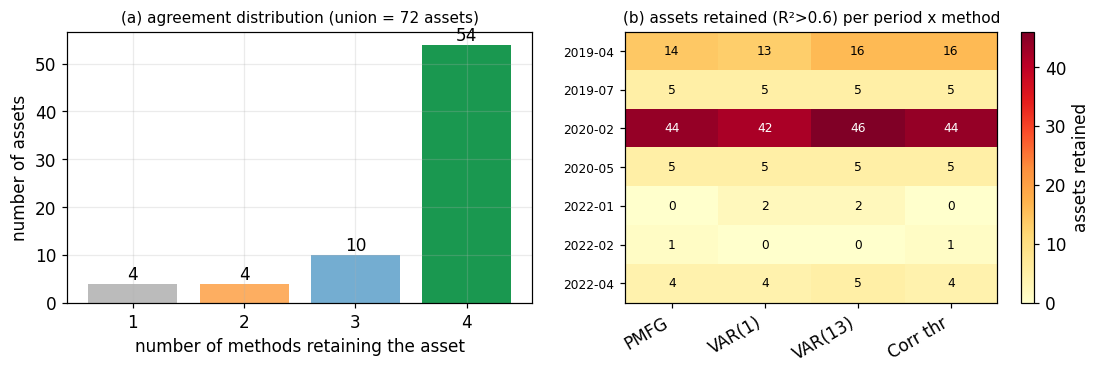

=== CAPTION [fig_4_5_method_agreement] ===
(a) Number of assets retained (SIS R²>0.6, at least one crisis) by exactly 1, 2, 3 or 4 of the contagion networks: 75% of the union is retained by all four methods. (b) Assets retained per crisis rise and method: the retained assets concentrate on the large collective crises (COVID Feb-Mar 2020, trade war Apr 2019).


In [26]:
# ── 4.5 · method x period table + agreement figure ────────────────────────────
from collections import Counter
sel_pm = {}
for (pa, pb) in peak_rises:
    sel_pm[(pa, pb)] = {m: {gi for gi, sl in peak_pd[(pa, pb)][1][m][1].items()
                            if sl['r2'] > config.R2_SEUIL}
                        for m in config.SIS_MODELS}
kept = [(pa, pb) for (pa, pb) in peak_rises if set().union(*sel_pm[(pa, pb)].values())]

rows = []
for (pa, pb) in kept:
    s = sel_pm[(pa, pb)]; union = set().union(*s.values())
    inter4 = set.intersection(*s.values())
    cnt = Counter(g for m in config.SIS_MODELS for g in s[m])
    ge3 = {g for g, c in cnt.items() if c >= 3}
    row = {'period': f'{str(all_days[pa])[:10]} - {str(all_days[pb])[:10]}'}
    for m in config.SIS_MODELS:
        row[m] = len(s[m])
    row['union'] = len(union); row['intersection'] = len(inter4)
    row['common >=3'] = len(ge3)
    row['% intersection'] = round(100 * len(inter4) / max(1, len(union)), 1)
    rows.append(row)
allsel = {m: set().union(*(sel_pm[w][m] for w in peak_rises)) for m in config.SIS_MODELS}
g_union = set().union(*allsel.values()); g_inter = set.intersection(*allsel.values())
row = {'period': 'GLOBAL (union of periods)'}
for m in config.SIS_MODELS:
    row[m] = len(allsel[m])
row['union'] = len(g_union); row['intersection'] = len(g_inter)
cnt_g = Counter(g for m in config.SIS_MODELS for g in allsel[m])
row['common >=3'] = sum(1 for c in cnt_g.values() if c >= 3)
row['% intersection'] = round(100 * len(g_inter) / max(1, len(g_union)), 1)
rows.append(row)
tab45 = pd.DataFrame(rows)
display(tab45)
save_table(tab45, 'tab_4_5_method_agreement')

dist = Counter(cnt_g.values())
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, max(3.2, 0.45 * len(kept))))
kk = [1, 2, 3, 4]; vv = [dist.get(k, 0) for k in kk]
bars = axA.bar(kk, vv, color=['#bbb', '#fdae61', '#74add1', '#1a9850'])
axA.bar_label(bars, fmt='%d'); axA.set_xticks(kk)
axA.set_xlabel('number of methods retaining the asset'); axA.set_ylabel('number of assets')
axA.set_title(f'(a) agreement distribution (union = {len(g_union)} assets)', fontsize=10)
axA.grid(alpha=0.25, axis='y')
M = np.array([[len(sel_pm[(pa, pb)][m]) for m in config.SIS_MODELS] for (pa, pb) in kept])
im = axB.imshow(M, cmap='YlOrRd', aspect='auto')
axB.set_xticks(range(len(config.SIS_MODELS))); axB.set_xticklabels(config.SIS_MODELS, rotation=30, ha='right')
axB.set_yticks(range(len(kept)))
axB.set_yticklabels([f'{str(all_days[pa])[:7]}' for (pa, pb) in kept], fontsize=8)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        axB.text(j, i, M[i, j], ha='center', va='center', fontsize=8,
                 color='black' if M[i, j] < M.max() * 0.6 else 'white')
fig.colorbar(im, ax=axB, label='assets retained')
axB.set_title('(b) assets retained (R²>0.6) per period x method', fontsize=10)
axB.grid(False)
save(fig, 'fig_4_5_method_agreement'); plt.show()
print('=== CAPTION [fig_4_5_method_agreement] ===')
print('(a) Number of assets retained (SIS R²>0.6, at least one crisis) by exactly 1, 2, 3 or 4 of the '
      f'contagion networks: {100*len(g_inter)/max(1,len(g_union)):.0f}% of the union is retained by all '
      'four methods. (b) Assets retained per crisis rise and method: the retained assets concentrate '
      'on the large collective crises (COVID Feb-Mar 2020, trade war Apr 2019).')

### 4.6 — Louvain communities: are crisis assets grouped together?

Period correlation network (`Corr thr`), Louvain communities (default resolution, size-1
communities dropped). Crisis assets = explained by the SIS (R² > 0.6, union of the 4 methods at
their optimal (B, R)). Metric: crisis ratio per community vs the random expectation.

In [27]:
# ── 4.6 · community definitions + summary table ───────────────────────────────
from networks import build_filtered_corr
_sec = pd.Series(sector_map)                     # ticker -> sector

def _period_graph(pa, pb):
    obs = (ctx.data.index >= all_days[pa]) & (ctx.data.index <= all_days[pb])
    C = np.abs(np.nan_to_num(np.corrcoef(arr[np.asarray(obs)].T))); np.fill_diagonal(C, 0)
    A = build_filtered_corr(C, config.CORR_THRESHOLD, ctx.mask_off)
    return nx.from_numpy_array(A)

def _graph_comms(pa, pb):
    """Louvain communities (default resolution) without size-1 communities (isolated assets)."""
    G = _period_graph(pa, pb)
    comm = nx.community.louvain_communities(G, weight='weight', seed=0)
    comm = [c for c in comm if len(c) > 1]
    G = G.subgraph(set().union(*comm) if comm else set()).copy()
    n2c = {n: ci for ci, c in enumerate(comm) for n in c}
    return G, comm, n2c

def _crisis_opt(pa, pb):
    return set().union(*(opt_sets_pm[(pa, pb)][m] for m in config.SIS_MODELS))

def _crisis_ratio(pa, pb):
    crisis = _crisis_opt(pa, pb)
    G, comm, _ = _graph_comms(pa, pb)
    mod = nx.community.modularity(G, comm, weight='weight') if comm else 0.0
    kept_n = set().union(*comm) if comm else set()
    base = len(crisis & kept_n) / len(kept_n) if kept_n else 0.0
    ratios = [(len(c), len(c & crisis), len(c & crisis) / len(c)) for c in comm]
    ratios.sort(key=lambda t: -t[2])
    return G, comm, mod, base, ratios

big = [(pa, pb) for (pa, pb) in peak_rises if len(peak_pd[(pa, pb)][0]) >= 20]
rows = []
for (pa, pb) in big:
    crisis = _crisis_opt(pa, pb)
    if len(crisis) < 2:
        continue
    _, comm, mod, base, ratios = _crisis_ratio(pa, pb)
    rmax = ratios[0][2] if ratios else 0.0
    n_hot = sum(1 for (_, ncx, p) in ratios if p > 2 * base and ncx >= 2)
    rows.append({'period': f'{str(all_days[pa])[:10]} - {str(all_days[pb])[:10]}',
                 'n crisis': len(crisis), 'n comm.': len(comm),
                 '% crisis assets': round(100 * base, 1),
                 'max crisis ratio %': round(100 * rmax, 1),
                 'max excess (pts)': round(100 * (rmax - base), 1),
                 'comm. >2x expected': n_hot})
tab46 = pd.DataFrame(rows)
display(tab46)
save_table(tab46, 'tab_4_6_communities')

,period,n crisis,n comm.,% crisis assets,max crisis ratio %,max excess (pts),comm. >2x expected
0,2019-04-01 - 2019-05-15,20,8,14.0,22.5,8.5,0
1,2019-07-22 - 2019-08-14,5,10,3.9,7.5,3.6,0
2,2020-02-11 - 2020-03-06,47,5,35.7,66.7,31.0,0
3,2020-05-29 - 2020-06-16,6,6,5.2,11.4,6.2,1
4,2022-01-03 - 2022-01-20,2,4,1.4,2.9,1.5,0
5,2022-04-08 - 2022-06-22,5,8,3.7,5.6,1.8,0


  done tab_4_6_communities.tex  +  tab_4_6_communities.csv


  done fig_4_6_community_crisis_ratio.pdf  +  fig_4_6_community_crisis_ratio.png


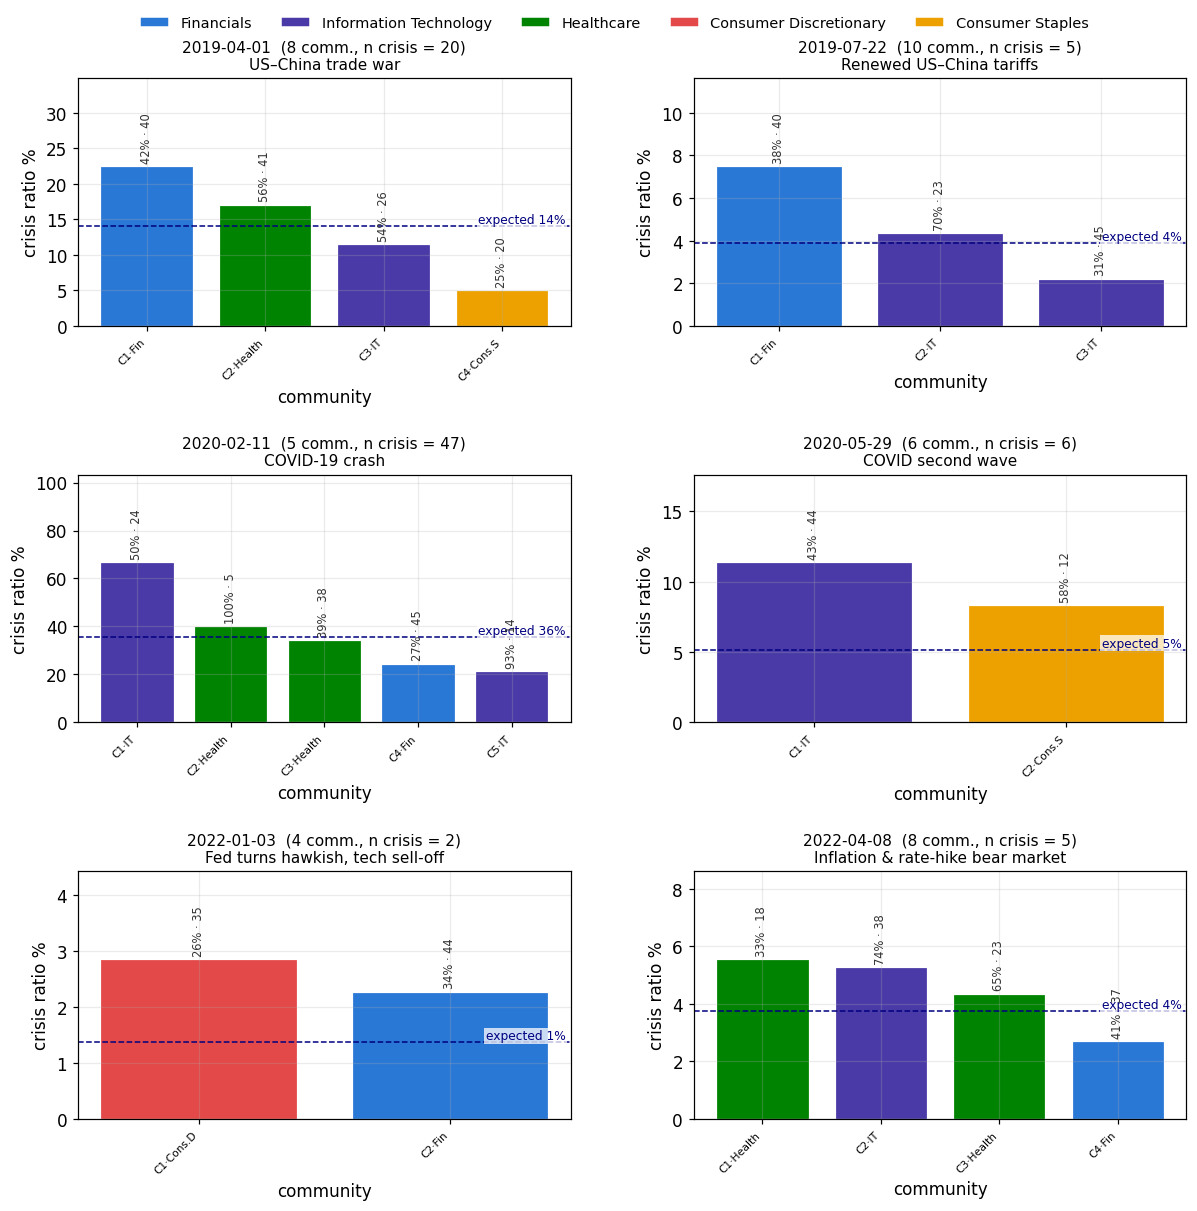

=== CAPTION [fig_4_6_community_crisis_ratio] ===
Crisis ratio per Louvain community (one bar = one community; height = crisis assets / community size) for the large collective crises; bar colour = dominant sector; the label above each bar gives the dominant-sector share and the community size; dashed line = random expectation. Crisis assets are spread over several communities: no single "crisis community" emerges, only a moderately enriched sub-community during COVID.


In [28]:
# ── 4.6 · crisis ratio per community (bar = community, colour = dominant sector) ──
from matplotlib.patches import Patch

SECTOR_COLOR = {
    'Financials':             '#2a78d6',
    'Information Technology': '#4a3aa7',
    'Healthcare':             '#008300',
    'Health Care':            '#008300',
    'Consumer Discretionary': '#e34948',
    'Consumer Staples':       '#eda100',
}
_SECTOR_ORDER = ['Financials', 'Information Technology', 'Healthcare',
                 'Consumer Discretionary', 'Consumer Staples']
_SECTOR_TAG = {
    'Financials':             'Fin',
    'Information Technology': 'IT',
    'Healthcare':             'Health',
    'Health Care':            'Health',
    'Consumer Discretionary': 'Cons.D',
    'Consumer Staples':       'Cons.S',
}
_OTHER = '#9a9a92'

PERIOD_TAGS = {
    '2019-04-01': 'US–China trade war',
    '2019-07-22': 'Renewed US–China tariffs',
    '2019-11-19': 'Trade truce, pre-COVID calm',
    '2020-02-11': 'COVID-19 crash',
    '2020-05-29': 'COVID second wave',
    '2020-08-24': 'Nasdaq tech correction',
    '2020-10-19': 'COVID wave, US election, vaccine',
    '2020-12-10': 'Reflation trade & GameStop',
    '2021-03-29': 'Spring inflation scare',
    '2021-08-05': 'Evergrande crisis & Fed tapering',
    '2021-11-09': 'Omicron variant',
    '2022-01-03': 'Fed turns hawkish, tech sell-off',
    '2022-02-08': 'Russia invades Ukraine',
    '2022-04-08': 'Inflation & rate-hike bear market',
    '2022-08-01': 'Jackson Hole speech, high inflation',
    '2022-12-02': 'Hawkish Fed, year-end sell-off',
    '2023-01-20': 'High inflation & jobs data',
}
def _tag(pa):
    return PERIOD_TAGS.get(str(all_days[pa])[:10], '?')

def _top_sector(c):
    cnt = Counter(_sec.get(real.columns[i], '?') for i in c)
    top, k = cnt.most_common(1)[0]
    return top, 100 * k / len(c)

viz = [(pa, pb) for (pa, pb) in big if len(_crisis_opt(pa, pb)) >= 2]
ncol = 2; nrow = int(np.ceil(len(viz) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(13, 3.8 * nrow), squeeze=False)
present = set()
for ax, (pa, pb) in zip(axes.ravel(), viz):
    _, comm, mod, base, _ = _crisis_ratio(pa, pb)
    crisis = _crisis_opt(pa, pb)
    items = []
    for c in comm:
        ncx = len(c & crisis); p = ncx / len(c)
        if p > 0:
            top, frac = _top_sector(c)
            items.append((p, len(c), top, frac)); present.add(top)
    items.sort(key=lambda t: -t[0])
    xs = np.arange(len(items))
    ymax = max(100 * it[0] for it in items)
    cols = [SECTOR_COLOR.get(top, _OTHER) for (_, _, top, _) in items]
    ax.bar(xs, [100 * it[0] for it in items], color=cols, edgecolor='white', linewidth=0.8, width=0.78)
    ax.axhline(100 * base, color='navy', ls='--', lw=1)
    ax.text(0.99, 100 * base, f'expected {100*base:.0f}%', transform=ax.get_yaxis_transform(),
            ha='right', va='bottom', fontsize=8, color='navy',
            bbox=dict(fc='white', ec='none', alpha=0.75, pad=1))
    for x, (p, sz, top, frac) in zip(xs, items):
        ax.text(x, 100 * p + 0.02 * ymax, f'{frac:.0f}% · {sz}', ha='center', va='bottom',
                rotation=90, fontsize=7.5, color='#333')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'C{i+1}·{_SECTOR_TAG.get(top, "Oth")}'
                        for i, (_, _, top, _) in enumerate(items)], fontsize=7, rotation=45, ha='right')
    ax.set_ylim(0, ymax * 1.55)
    ax.set_title(f'{str(all_days[pa])[:10]}  ({len(comm)} comm., n crisis = {len(crisis)})\n{_tag(pa)}', fontsize=10)
    ax.set_ylabel('crisis ratio %')
    ax.set_xlabel('community')
    ax.grid(alpha=0.25, axis='y')
for ax in axes.ravel()[len(viz):]:
    ax.axis('off')
handles = [Patch(facecolor=SECTOR_COLOR.get(s, _OTHER), edgecolor='white', label=s)
           for s in _SECTOR_ORDER if s in present]
if present - set(_SECTOR_ORDER):
    handles.append(Patch(facecolor=_OTHER, edgecolor='white', label='Other'))
fig.legend(handles=handles, loc='upper center', ncol=len(handles), frameon=False,
           fontsize=9.5, bbox_to_anchor=(0.5, 1.0))
fig.subplots_adjust(top=0.94, hspace=0.6, wspace=0.25)
save(fig, 'fig_4_6_community_crisis_ratio'); plt.show()
print('=== CAPTION [fig_4_6_community_crisis_ratio] ===')
print('Crisis ratio per Louvain community (one bar = one community; height = crisis assets / '
      'community size) for the large collective crises; bar colour = dominant sector; the label above '
      'each bar gives the dominant-sector share and the community size; dashed line = random expectation. Crisis assets are '
      'spread over several communities: no single "crisis community" emerges, only a moderately '
      'enriched sub-community during COVID.')

  done fig_4_7_community_graphs.pdf  +  fig_4_7_community_graphs.png


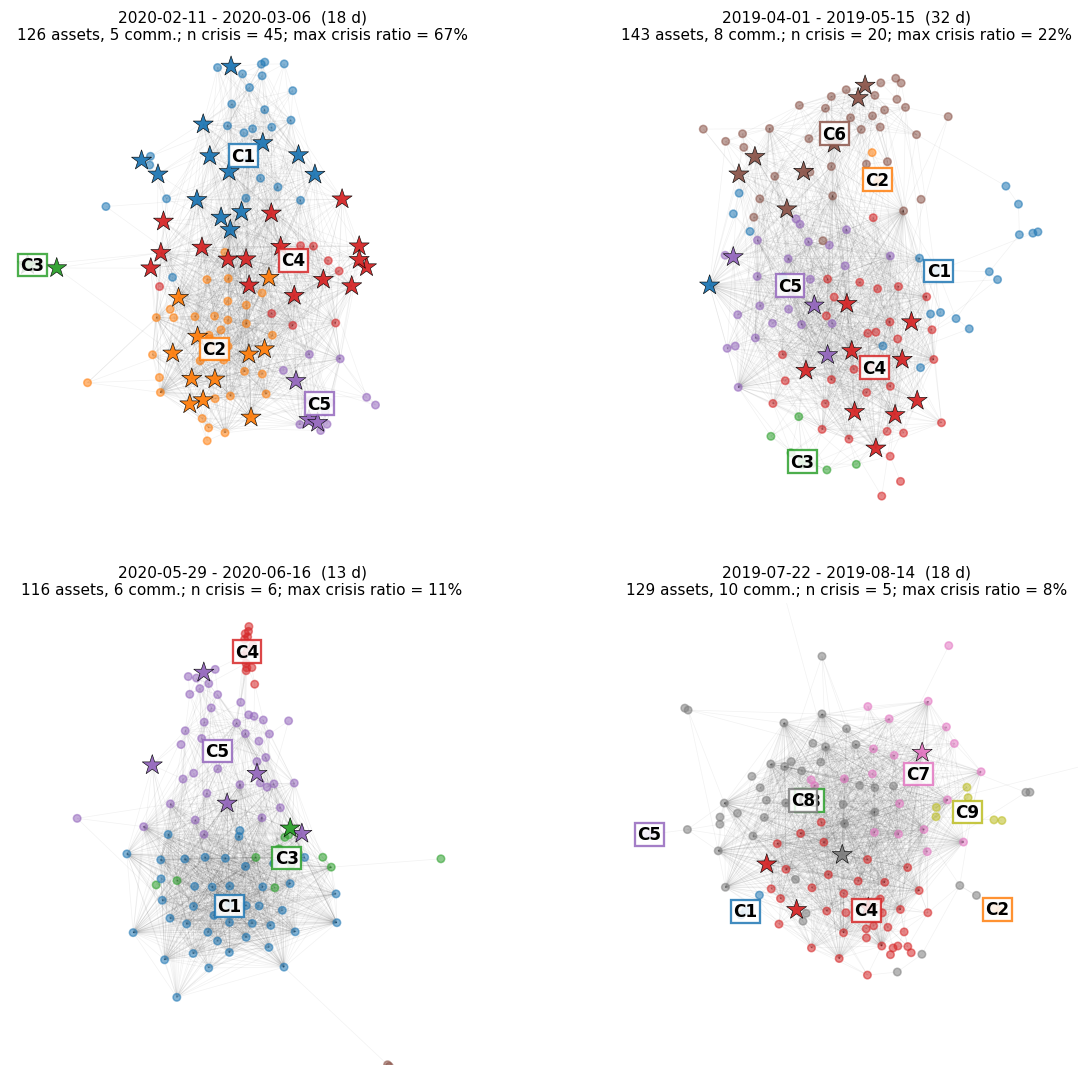

=== CAPTION [fig_4_7_community_graphs] ===
Period correlation networks (Corr thr, ForceAtlas2 layout) for the four largest collective crises. Node colour = Louvain community (size-1 communities dropped); stars = crisis assets (SIS R²>0.6 at their optimal (B, R), union of the four methods). Crisis assets scatter across communities rather than clustering in a single one.


In [29]:
# ── 4.6 · period networks (ForceAtlas2): colour = community, stars = crisis assets ──
from fa2_modified import ForceAtlas2

GRAVITY_G = 0.05
_fa2 = ForceAtlas2(scalingRatio=30.0, gravity=GRAVITY_G, edgeWeightInfluence=0.3,
                   strongGravityMode=False, outboundAttractionDistribution=True, verbose=False)
sel4 = sorted([w for w in big if len(_crisis_opt(*w)) >= 2], key=lambda w: -len(_crisis_opt(*w)))[:4]
cmap4 = plt.get_cmap('tab10')
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for ax, (pa, pb) in zip(axes.ravel(), sel4):
    crisis = _crisis_opt(pa, pb)
    G, comm, n2c = _graph_comms(pa, pb)
    crisis_in = crisis & set(G.nodes())
    rmax = max((len(c & crisis) / len(c) for c in comm), default=0.0)
    ndays = pb - pa + 1
    pos = _fa2.forceatlas2_networkx_layout(G, pos=None, iterations=2000)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.05, width=0.5)
    ncn = [n for n in G.nodes() if n not in crisis]
    ccn = [n for n in G.nodes() if n in crisis]
    nx.draw_networkx_nodes(G, pos, nodelist=ncn, node_color=[cmap4(n2c[n] % 10) for n in ncn],
                           node_size=24, ax=ax, alpha=0.55)
    nx.draw_networkx_nodes(G, pos, nodelist=ccn, node_color=[cmap4(n2c[n] % 10) for n in ccn],
                           node_shape='*', node_size=190, edgecolors='k', linewidths=0.4, ax=ax, alpha=0.95)
    xs = np.array([pos[n][0] for n in G.nodes()]); ys = np.array([pos[n][1] for n in G.nodes()])
    cx, cy = np.median(xs), np.median(ys)
    h = max(np.percentile(np.abs(xs - cx), 95), np.percentile(np.abs(ys - cy), 95)) * 1.15 + 1e-9
    ax.set_xlim(cx - h, cx + h); ax.set_ylim(cy - h, cy + h); ax.set_aspect('equal')
    for ci, c in enumerate(comm):
        cn = [n for n in c if n in pos]
        if not cn:
            continue
        mx = np.median([pos[n][0] for n in cn]); my = np.median([pos[n][1] for n in cn])
        if not (cx - h <= mx <= cx + h and cy - h <= my <= cy + h):
            continue
        ax.text(mx, my, f'C{ci+1}', fontsize=11, fontweight='bold', ha='center', va='center',
                clip_on=True, bbox=dict(fc='white', ec=cmap4(ci % 10), alpha=0.85, pad=1.5, lw=1.5))
    ax.set_title(f'{str(all_days[pa])[:10]} - {str(all_days[pb])[:10]}  ({ndays} d)\n'
                 f'{G.number_of_nodes()} assets, {len(comm)} comm.; '
                 f'n crisis = {len(crisis_in)}; max crisis ratio = {100*rmax:.0f}%', fontsize=10)
    ax.axis('off'); ax.grid(False)
save(fig, 'fig_4_7_community_graphs'); plt.show()
print('=== CAPTION [fig_4_7_community_graphs] ===')
print('Period correlation networks (Corr thr, ForceAtlas2 layout) for the four largest collective '
      'crises. Node colour = Louvain community (size-1 communities dropped); stars = crisis assets '
      '(SIS R²>0.6 at their optimal (B, R), union of the four methods). Crisis assets scatter across '
      'communities rather than clustering in a single one.')

### 4.7 — Endo/exo score per period (branching ratio)

Reproducible score on the 17 rises: n = 1 − 1/√(Var/Mean) of the daily counts of asset jumps
(|r| > 3× own median). n → 0: exogenous (Poissonian shocks); n → 1: endogenous cascade
(Filimonov & Sornette 2012; Hardiman & Bouchaud 2014). Compared with the SIS contamination (§4.5).

,period,event,n (endo/exo),% stocks R²>0.6
0,2019-04-01 - 2019-05-15,US–China trade war,0.80,13.7
1,2019-07-22 - 2019-08-14,Renewed US–China tariffs,0.85,3.4
2,2019-11-19 - 2020-02-04,"Trade truce, pre-COVID calm",0.79,0.0
3,2020-02-11 - 2020-03-06,COVID-19 crash,0.94,32.2
4,2020-05-29 - 2020-06-16,COVID second wave,0.90,4.1
5,2020-08-24 - 2020-09-14,Nasdaq tech correction,0.89,0.0
6,2020-10-19 - 2020-11-04,"COVID wave, US election, vaccine",0.84,0.0
7,2020-12-10 - 2021-03-04,Reflation trade & GameStop,0.89,0.0
8,2021-03-29 - 2021-05-13,Spring inflation scare,0.76,0.0
9,2021-08-05 - 2021-09-29,Evergrande crisis & Fed tapering,0.79,0.7


  done tab_4_8_endo_exo.tex  +  tab_4_8_endo_exo.csv
intra-bar (30-min) reflexivity ~ 0.85 (apparent criticality); Spearman(n, % SIS) = 0.25
  done fig_4_8_endo_exo.pdf  +  fig_4_8_endo_exo.png


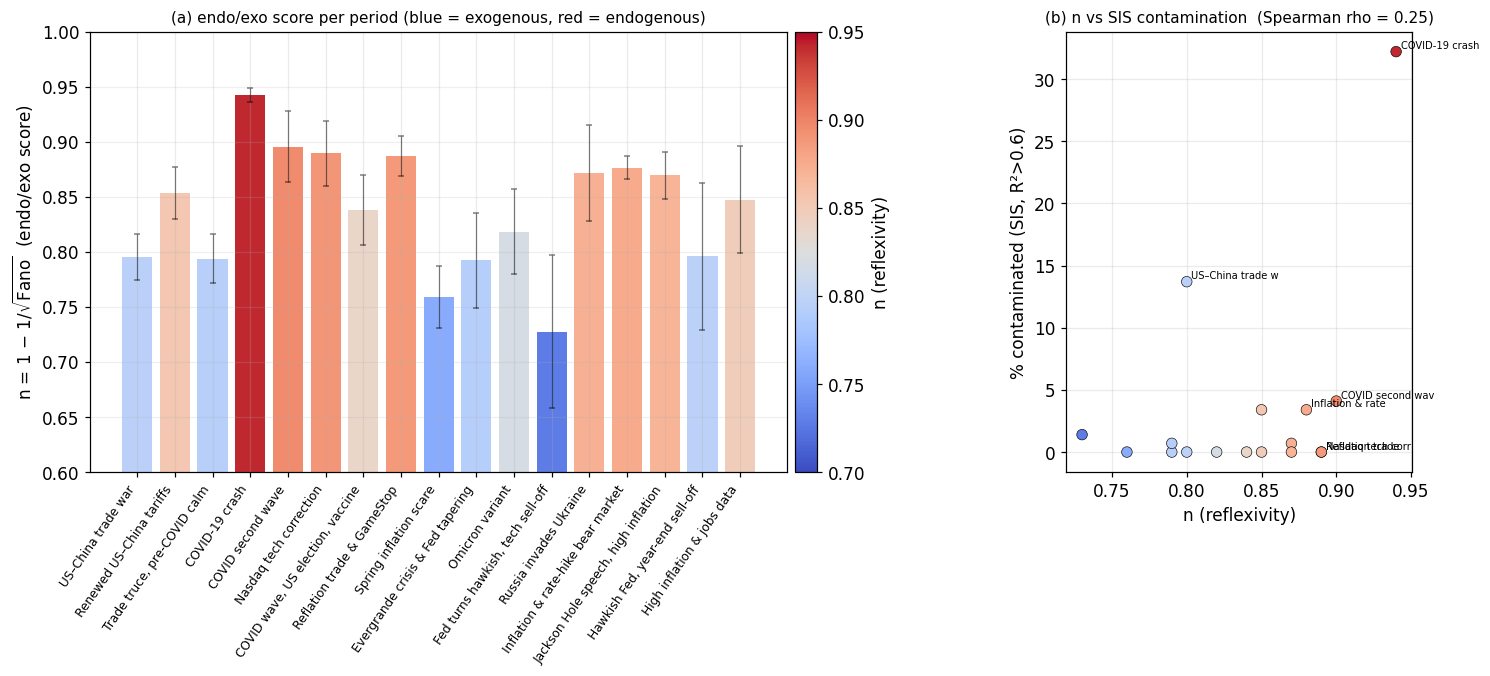

=== CAPTION [fig_4_8_endo_exo] ===
(a) Endo/exo score n (Hawkes branching ratio, daily jump counts) per crisis rise, with bootstrap +/-1 sd; colour encodes n (blue = more exogenous, red = more endogenous). All periods have a strong endogenous component (n = 0.73-0.94); the COVID crash is the most endogenous. (b) n vs the share of assets explained by the SIS: agreement at the top (COVID is both the most endogenous and the most contaminated), modest rank correlation elsewhere.


In [30]:
# ── 4.7 · endo/exo score n per period + comparison with SIS contamination ─────
import endo_exo
from scipy.stats import spearmanr
from matplotlib.cm import ScalarMappable

reflex = endo_exo.reflexivity_by_period(ctx, peak_rises)
n_intra = endo_exo.branching_ratio(endo_exo.market_jump_activity(ctx.data))

rows = []
for i, (pa, pb) in enumerate(peak_rises):
    detect = len(peak_pd[(pa, pb)][0])
    sis_opt = set().union(*(opt_sets_pm[(pa, pb)][m] for m in config.SIS_MODELS))
    r = reflex.iloc[i]
    rows.append({'period': f'{str(all_days[pa])[:10]} - {str(all_days[pb])[:10]}',
                 'event': _tag(pa),
                 'n (endo/exo)': round(float(r['n']), 2),
                 'detected': detect, '% detected': round(100 * detect / N, 1),
                 'SIS@opt': len(sis_opt), '% stocks R²>0.6': round(100 * len(sis_opt) / N, 1)})
contam = pd.DataFrame(rows)
tab48 = contam[['period', 'event', 'n (endo/exo)', '% stocks R²>0.6']]
display(tab48)
save_table(tab48, 'tab_4_8_endo_exo')
rho = spearmanr(contam['n (endo/exo)'], contam['% stocks R²>0.6']).correlation
print(f'intra-bar (30-min) reflexivity ~ {n_intra:.2f} (apparent criticality); '
      f'Spearman(n, % SIS) = {rho:.2f}')

cmapn = plt.get_cmap('coolwarm')
norm = plt.Normalize(0.70, 0.95)
cols = cmapn(norm(reflex['n'].values))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15.5, 5.2),
                               gridspec_kw={'width_ratios': [2.4, 1]})
x = np.arange(len(peak_rises))
ax1.bar(x, reflex['n'], color=cols, yerr=reflex['n_sd'].values, capsize=2,
        error_kw=dict(lw=0.8, alpha=0.5))
ax1.set_xticks(x)
ax1.set_xticklabels([_tag(pa) for (pa, pb) in peak_rises], rotation=55, ha='right', fontsize=8)
ax1.set_ylabel(r'n = 1 − 1/$\sqrt{\mathrm{Fano}}$  (endo/exo score)')
ax1.set_ylim(0.6, 1.0)
ax1.set_title('(a) endo/exo score per period (blue = exogenous, red = endogenous)', fontsize=10)
sm = ScalarMappable(norm=norm, cmap=cmapn); sm.set_array([])
fig.colorbar(sm, ax=ax1, pad=0.01).set_label('n (reflexivity)')
ax1.grid(alpha=0.2, axis='y')
nq75 = reflex['n'].quantile(0.75)
ax2.scatter(contam['n (endo/exo)'], contam['% stocks R²>0.6'], c=cols, s=48,
            edgecolor='k', lw=0.4, zorder=3)
for _, rr in contam.iterrows():
    if rr['% stocks R²>0.6'] > 8 or rr['n (endo/exo)'] >= nq75:
        ax2.annotate(rr['event'][:16], (rr['n (endo/exo)'], rr['% stocks R²>0.6']), fontsize=6.5,
                     xytext=(3, 2), textcoords='offset points')
ax2.set_xlabel('n (reflexivity)')
ax2.set_ylabel('% contaminated (SIS, R²>0.6)')
ax2.set_title(f'(b) n vs SIS contamination  (Spearman rho = {rho:.2f})', fontsize=10)
ax2.grid(alpha=0.25)
fig.subplots_adjust(wspace=0.25)
save(fig, 'fig_4_8_endo_exo'); plt.show()
print('=== CAPTION [fig_4_8_endo_exo] ===')
print('(a) Endo/exo score n (Hawkes branching ratio, daily jump counts) per crisis rise, with '
      'bootstrap +/-1 sd; colour encodes n (blue = more exogenous, red = more endogenous). All periods '
      'have a strong endogenous component (n = 0.73-0.94); the COVID crash is the most endogenous. '
      '(b) n vs the share of assets explained by the SIS: agreement at the top (COVID is both the most '
      'endogenous and the most contaminated), modest rank correlation elsewhere.')

  done fig_4_8c_n_vs_sis_crisis.pdf  +  fig_4_8c_n_vs_sis_crisis.png


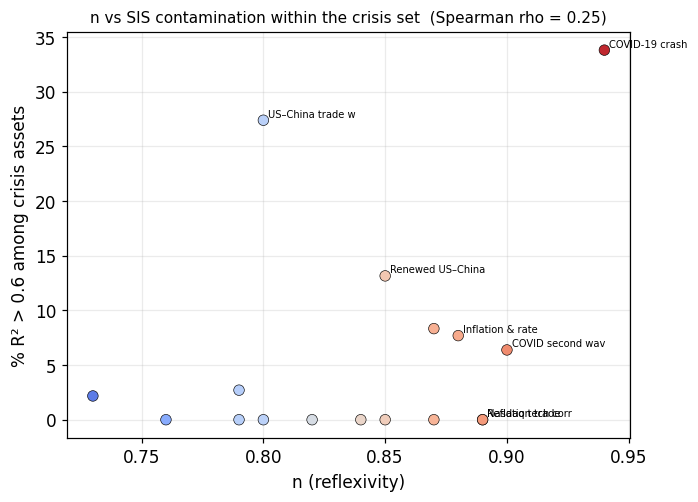

=== CAPTION [fig_4_8c_n_vs_sis_crisis] ===
Endo/exo score n vs the share of well-fitted stocks (R² > 0.6) measured within the crisis set of each window (rather than the whole universe as in panel (b) of fig_4_8_endo_exo); colour encodes n (blue = exogenous, red = endogenous).


In [31]:
# ── 4.7 · (c) % R² among the CRISIS assets vs reflexivity n (standalone) ─────
# Same scatter as panel (b) but the SIS contamination is measured within the
# crisis set of each window: 100 * |SIS@opt| / |detected|.
pc_crisis = 100 * contam['SIS@opt'] / contam['detected']
rho_c = spearmanr(contam['n (endo/exo)'], pc_crisis).correlation
fig, ax = plt.subplots(figsize=(6.6, 4.8))
ax.scatter(contam['n (endo/exo)'], pc_crisis, c=cols, s=48,
           edgecolor='k', lw=0.4, zorder=3)
for k, rr in contam.iterrows():
    if pc_crisis[k] > 10 or rr['n (endo/exo)'] >= nq75:
        ax.annotate(rr['event'][:16], (rr['n (endo/exo)'], pc_crisis[k]), fontsize=6.5,
                    xytext=(3, 2), textcoords='offset points')
ax.set_xlabel('n (reflexivity)')
ax.set_ylabel('% R² > 0.6 among crisis assets')
ax.set_title(f'n vs SIS contamination within the crisis set  (Spearman rho = {rho_c:.2f})',
             fontsize=10)
ax.grid(alpha=0.25)
save(fig, 'fig_4_8c_n_vs_sis_crisis'); plt.show()
print('=== CAPTION [fig_4_8c_n_vs_sis_crisis] ===')
print('Endo/exo score n vs the share of well-fitted stocks (R² > 0.6) measured within the '
      'crisis set of each window (rather than the whole universe as in panel (b) of '
      'fig_4_8_endo_exo); colour encodes n (blue = exogenous, red = endogenous).')


### 4.8 — Falsifiability tests

**Test A** — refit the well-fitted assets with matrices that destroy the topology at constant
spectral radius (relabelled P·A·Pᵀ, rank-1 common factor, uniform). If the fit rate is unchanged,
the R² cannot falsify the model.
**Test B** — nested logistic regression of the daily ignition s_i: 0→1: M0 global fraction f(t)
only; M1 adds the neighbour fraction g_i(t) weighted by A. Contagion predicts b > 0 after
controlling for f, judged against an identity-permutation null.
**Test C** — restrict the system to the crisis assets only (A → A[S,S]): if the fit came from
contagion between crisis assets, the reduction should preserve or improve it.

[cache] OK  fal_testA


,method,n fits,% R²>0.6 (real A),% (relabelled),% (common factor),% (uniform),mean R² (real),mean R² (relabelled),mean R² (common factor),mean R² (uniform)
0,PMFG,73,91.78,91.78,91.78,94.52,0.70,0.70,0.70,0.72
1,VAR(1),71,98.59,92.96,95.77,97.18,0.70,0.70,0.71,0.72
2,VAR(13),79,97.47,94.94,97.47,98.73,0.70,0.70,0.70,0.71
3,Corr thr,75,85.33,78.67,86.67,92.00,0.69,0.68,0.69,0.70


  done tab_4_9_testA.tex  +  tab_4_9_testA.csv
  done fig_4_9_falsifiability_testA.pdf  +  fig_4_9_falsifiability_testA.png


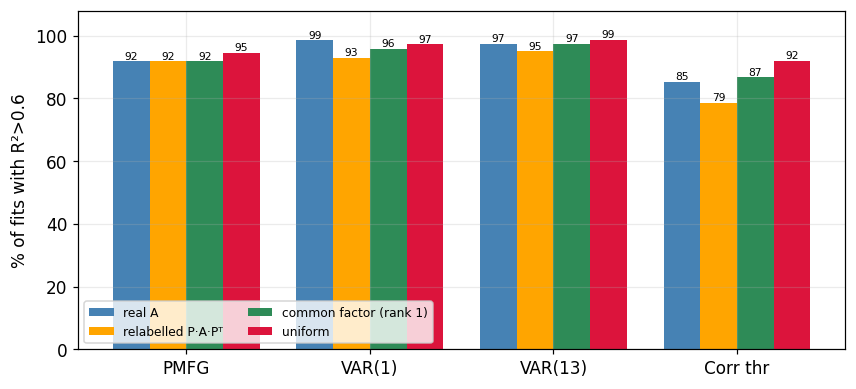

=== CAPTION [fig_4_9_falsifiability_testA] ===
Test A - the SIS fit is blind to the topology. For the well-fitted assets (R²>0.6), share of good fits when A is replaced by nulls that destroy the topology at constant spectral radius: node relabelling P.A.P^T, rank-1 common factor, uniform coupling. The rates are nearly identical to the real A for all four networks: the R² alone cannot falsify the model, hence cannot prove contagion.


In [32]:
# ── 4.8 · Test A — is the SIS fit blind to the topology? (cached: fal_testA) ──
K_REL = 5
def _spec_rad(M):
    return float(np.max(np.abs(np.linalg.eigvals(M))))

def _fal_test_A():
    _rng = np.random.default_rng(0)
    rows = []
    for m in config.SIS_MODELS:
        A = ctx.A_sis[m]; lamA = _spec_rad(A); s = A.sum(1)
        Acf = np.outer(s, s); np.fill_diagonal(Acf, 0.0); Acf *= lamA / _spec_rad(Acf)
        Au = np.ones((N, N)) - np.eye(N); Au *= lamA / _spec_rad(Au)
        perms = [_rng.permutation(N) for _ in range(K_REL)]
        def _r2(A_use, gi, d, E_i, ok):
            xt = sis.integrate_xscan(d, gi, A_use)
            return linregress(E_i[ok], xt[ok]).rvalue ** 2
        acc = {'real': [], 'relabel': [], 'cf': [], 'uni': []}
        for (pa, pb) in peak_rises:
            cache = peak_pd[(pa, pb)][0]; sl = peak_pd[(pa, pb)][1][m][1]
            for gi, d in cache.items():
                if sl.get(gi, {}).get('r2', 0.0) <= config.R2_SEUIL:
                    continue
                E_i = d['E_i']; ok = ~np.isnan(E_i)
                if ok.sum() < 3:
                    continue
                acc['real'].append(_r2(A, gi, d, E_i, ok))
                acc['cf'].append(_r2(Acf, gi, d, E_i, ok))
                acc['uni'].append(_r2(Au, gi, d, E_i, ok))
                acc['relabel'].append(np.mean([_r2(A[p][:, p], gi, d, E_i, ok) for p in perms]))
        a = {k: np.array(v) for k, v in acc.items()}; thr = config.R2_SEUIL
        rows.append(dict(methode=m, n=len(a['real']),
                         pc_reel=100 * np.mean(a['real'] > thr),
                         pc_reetiquete=100 * np.mean(a['relabel'] > thr),
                         pc_facteur_commun=100 * np.mean(a['cf'] > thr),
                         pc_uniforme=100 * np.mean(a['uni'] > thr),
                         R2moy_reel=np.mean(a['real']), R2moy_reetiq=np.mean(a['relabel']),
                         R2moy_fcommun=np.mean(a['cf']), R2moy_uniforme=np.mean(a['uni'])))
    return pd.DataFrame(rows)

sigA = sig_of(repr(peak_rises), config.R2_SEUIL, K_REL, config.T_LONG, 'fal_testA_v1')
tabA = disk_cache('fal_testA', sigA, _fal_test_A)
tabA_out = tabA.rename(columns={
    'methode': 'method', 'n': 'n fits',
    'pc_reel': '% R²>0.6 (real A)', 'pc_reetiquete': '% (relabelled)',
    'pc_facteur_commun': '% (common factor)', 'pc_uniforme': '% (uniform)',
    'R2moy_reel': 'mean R² (real)', 'R2moy_reetiq': 'mean R² (relabelled)',
    'R2moy_fcommun': 'mean R² (common factor)', 'R2moy_uniforme': 'mean R² (uniform)'}).round(2)
display(tabA_out)
save_table(tabA_out, 'tab_4_9_testA')

_cols = [('pc_reel', 'real A', 'steelblue'), ('pc_reetiquete', 'relabelled P·A·Pᵀ', 'orange'),
         ('pc_facteur_commun', 'common factor (rank 1)', 'seagreen'), ('pc_uniforme', 'uniform', 'crimson')]
x = np.arange(len(tabA)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 4))
for j, (col, lab, c) in enumerate(_cols):
    bb = ax.bar(x + (j - 1.5) * w, tabA[col], w, label=lab, color=c)
    ax.bar_label(bb, fmt='%.0f', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(tabA['methode']); ax.set_ylabel('% of fits with R²>0.6')
ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.25, axis='y'); ax.set_ylim(0, 108)
save(fig, 'fig_4_9_falsifiability_testA'); plt.show()
print('=== CAPTION [fig_4_9_falsifiability_testA] ===')
print('Test A - the SIS fit is blind to the topology. For the well-fitted assets (R²>0.6), share of '
      'good fits when A is replaced by nulls that destroy the topology at constant spectral radius: '
      'node relabelling P.A.P^T, rank-1 common factor, uniform coupling. The rates are nearly '
      'identical to the real A for all four networks: the R² alone cannot falsify the model, hence '
      'cannot prove contagion.')

[cache] OK  fal_testC
--- B=R=1 (canonical) ---


,method,n fits,% R²>0.6 (full),% R²>0.6 (reduced),mean R² (full),mean R² (reduced),mean ΔR²,median ΔR²,frac. improved
0,PMFG,712,9.270,11.096,0.271,0.285,0.015,0.002,0.673
1,VAR(1),712,9.831,9.831,0.267,0.288,0.020,0.003,0.621
2,VAR(13),712,10.815,11.376,0.272,0.286,0.014,0.000,0.539
3,Corr thr,712,9.129,9.972,0.261,0.269,0.008,0.002,0.642


  done tab_4_11_testC.tex  +  tab_4_11_testC.csv
reduced-A sizes per collective crisis: [25, 34, 37, 37, 38, 65, 73, 78, 92, 94, 139]
  done fig_4_11_testC_counts.pdf  +  fig_4_11_testC_counts.png


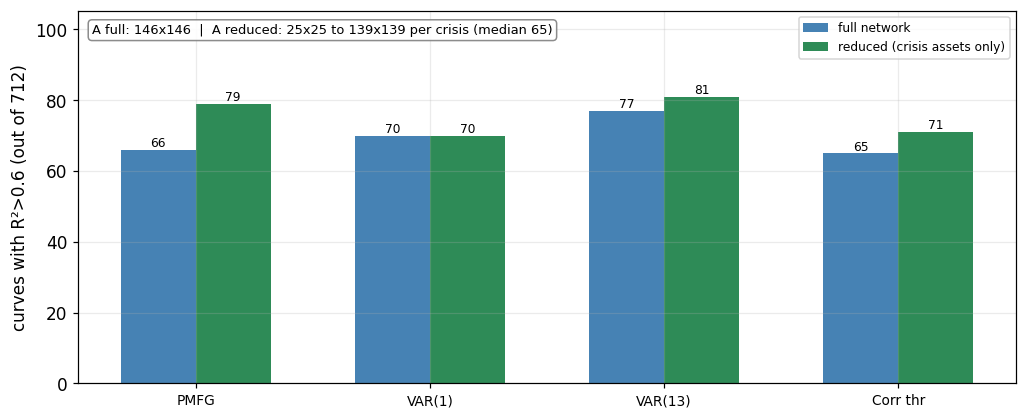

=== CAPTION [fig_4_11_testC_counts] ===
Test C - number of well-fitted curves (R²>0.6) out of 712 fits per method over the 11 collective crises, full network vs network reduced to the crisis assets only, at B=R=1. The reduced matrix A[S,S] keeps only the crisis assets of the period: 25x25 to 139x139 (median 65) against 146x146 for the full A. The reduction shifts the count by a few curves at most: the fit is blind to the size of the network.
  done fig_4_11_testC_meanR2.pdf  +  fig_4_11_testC_meanR2.png


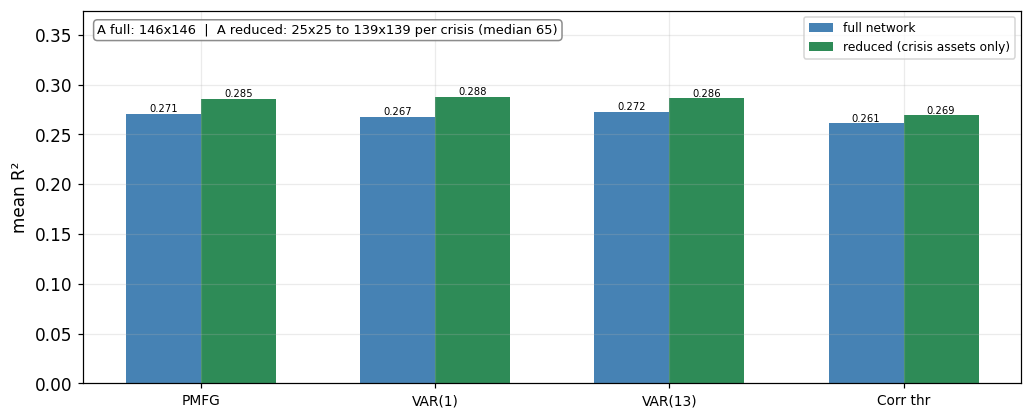

=== CAPTION [fig_4_11_testC_meanR2] ===
Test C - mean R² of the SIS fits, full vs reduced network, at B=R=1. Reduced A[S,S]: 25x25 to 139x139 per crisis (median 65) vs 146x146 full. The gain from the reduction is at most +0.02: consistent with co-movement rather than asset-to-asset contagion.


In [33]:
# ── 4.8 · Test C — reduced network (crisis assets only), cached ───────────────
# Canonical regime B=R=1 only: does restricting A to the crisis assets change the fit?
def _fit_reduced_at(br):
    def _r2(cache_gi, gi_idx, A, E, B, R):
        ok = ~np.isnan(E)
        if ok.sum() < 3:
            return None
        return linregress(E[ok], sis.integrate_xscan(cache_gi, gi_idx, A, B=B, R=R)[ok]).rvalue ** 2
    big_c = [w for w in peak_rises if len(peak_pd[w][0]) >= 20]
    rows = []
    for m in config.SIS_MODELS:
        A = ctx.A_sis[m]; B, R = br[m]; base, red = [], []
        for (pa, pb) in big_c:
            cache = peak_pd[(pa, pb)][0]
            S = sorted(cache.keys()); idxS = {gi: k for k, gi in enumerate(S)}
            A_S = A[np.ix_(S, S)]
            for gi, d in cache.items():
                E = d['E_i']; rb = _r2(d, gi, A, E, B, R)
                if rb is None:
                    continue
                rf = _r2({'x0': d['x0'][S], 'n_days': d['n_days']}, idxS[gi], A_S, E, B, R)
                base.append(rb); red.append(rf)
        base, red = np.array(base), np.array(red); thr = config.R2_SEUIL
        rows.append(dict(methode=m, B=B, R=R, n=len(base),
                         pc_complet=100 * np.mean(base > thr), pc_reduit=100 * np.mean(red > thr),
                         R2moy_complet=np.mean(base), R2moy_reduit=np.mean(red),
                         dR2_moyen=np.mean(red - base), dR2_median=np.median(red - base),
                         frac_amelioration=np.mean(red > base)))
    return pd.DataFrame(rows)

sigC = sig_of(repr(peak_rises), 'fal_testC_reduit_v1', config.R2_SEUIL)
tabC = disk_cache('fal_testC', sigC,
                  lambda: _fit_reduced_at({m: (1.0, 1.0) for m in config.SIS_MODELS}))

_ren = {'methode': 'method', 'n': 'n fits',
        'pc_complet': '% R²>0.6 (full)', 'pc_reduit': '% R²>0.6 (reduced)',
        'R2moy_complet': 'mean R² (full)', 'R2moy_reduit': 'mean R² (reduced)',
        'dR2_moyen': 'mean ΔR²', 'dR2_median': 'median ΔR²',
        'frac_amelioration': 'frac. improved'}
tabC_out = tabC.rename(columns=_ren).round(3)
print('--- B=R=1 (canonical) ---'); display(tabC_out)
save_table(tabC_out, 'tab_4_11_testC')

# Size of the reduced matrix A[S,S] per collective crisis (S = crisis assets of the period)
big_c = [w for w in peak_rises if len(peak_pd[w][0]) >= 20]
Nc = np.array([len(peak_pd[w][0]) for w in big_c])
size_note = (f'A full: {N}x{N}  |  A reduced: {Nc.min()}x{Nc.min()} to {Nc.max()}x{Nc.max()} '
             f'per crisis (median {int(np.median(Nc))})')
print('reduced-A sizes per collective crisis:', sorted(Nc.tolist()))

def _counts(t):
    return ((t['pc_complet'] * t['n'] / 100).round().astype(int),
            (t['pc_reduit'] * t['n'] / 100).round().astype(int))
n1_full, n1_red = _counts(tabC)
xt = list(tabC['methode'])
x = np.arange(len(tabC)); w = 0.32

def _two_bars(ax, vf, vr, fmt, fs):
    bars = [ax.bar(x - 0.5 * w, vf, w, color='steelblue', label='full network'),
            ax.bar(x + 0.5 * w, vr, w, color='seagreen', label='reduced (crisis assets only)')]
    for b in bars:
        ax.bar_label(b, fmt=fmt, fontsize=fs)
    ax.set_xticks(x); ax.set_xticklabels(xt, fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.25, axis='y')

# (1) number of well-fitted curves (R²>0.6)
fig, ax = plt.subplots(figsize=(11, 4.4))
_two_bars(ax, n1_full, n1_red, '%d', 8)
ax.set_ylabel(f'curves with R²>0.6 (out of {int(tabC["n"].iloc[0])})')
ax.set_ylim(0, max(n1_full.max(), n1_red.max()) * 1.3)
ax.text(0.015, 0.965, size_note, transform=ax.transAxes, ha='left', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))
save(fig, 'fig_4_11_testC_counts'); plt.show()
print('=== CAPTION [fig_4_11_testC_counts] ===')
print('Test C - number of well-fitted curves (R²>0.6) out of '
      f'{int(tabC["n"].iloc[0])} fits per method over the {len(big_c)} collective crises, full network '
      'vs network reduced to the crisis assets only, at B=R=1. The reduced matrix A[S,S] keeps only '
      f'the crisis assets of the period: {Nc.min()}x{Nc.min()} to {Nc.max()}x{Nc.max()} '
      f'(median {int(np.median(Nc))}) against {N}x{N} for the full A. The reduction shifts the count '
      'by a few curves at most: the fit is blind to the size of the network.')

# (2) mean R²
fig, ax = plt.subplots(figsize=(11, 4.4))
_two_bars(ax, tabC['R2moy_complet'], tabC['R2moy_reduit'], '%.3f', 6.5)
ax.set_ylabel('mean R²')
ax.set_ylim(0, max(tabC['R2moy_complet'].max(), tabC['R2moy_reduit'].max()) * 1.3)
ax.text(0.015, 0.965, size_note, transform=ax.transAxes, ha='left', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))
save(fig, 'fig_4_11_testC_meanR2'); plt.show()
print('=== CAPTION [fig_4_11_testC_meanR2] ===')
print('Test C - mean R² of the SIS fits, full vs reduced network, at B=R=1. Reduced A[S,S]: '
      f'{Nc.min()}x{Nc.min()} to {Nc.max()}x{Nc.max()} per crisis (median {int(np.median(Nc))}) vs '
      f'{N}x{N} full. The gain from the reduction is at most +0.02: consistent with co-movement '
      'rather than asset-to-asset contagion.')


### 4.9 — Null: swapping the crisis assets (derangement)

Each empirical curve E_i (crisis asset) is re-paired with the SIS trajectory x_j of **another**
crisis asset (derangement: permutation with no fixed point, within groups of curves of equal
length; non-swappable singletons excluded on both sides). Both E_i and x_i are increasing,
so any rising curve can trivially match any other — if the real pairing does not beat this null,
the per-asset R² carries no asset-specific information.


  method  n_swappable  real  null_mean  null_std    z  p_perm
    PMFG          773    73       64.9      3.10 2.61  0.0115
  VAR(1)          773    71       63.9      3.09 2.29  0.0190
 VAR(13)          773    79       66.3      3.08 4.11  0.0005
Corr thr          773    75       65.6      3.23 2.92  0.0040
  done tab_4_12_null_swap.tex  +  tab_4_12_null_swap.csv
  done fig_4_12_null_swap.pdf  +  fig_4_12_null_swap.png


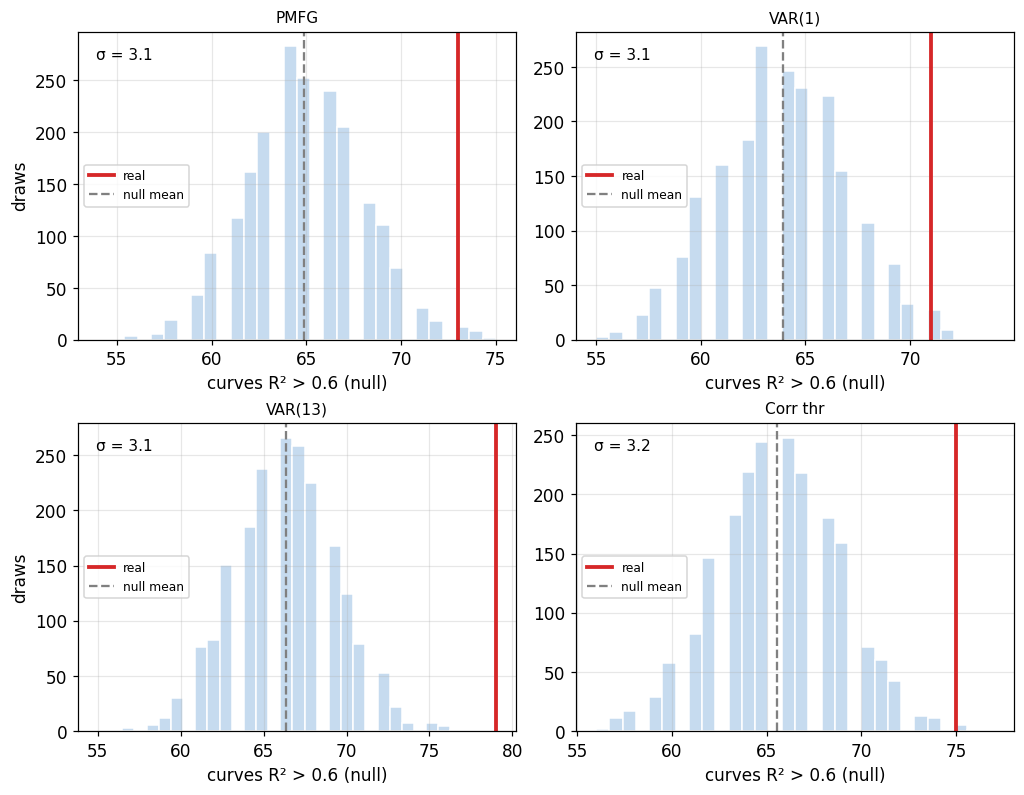

=== CAPTION [fig_4_12_null_swap] ===
Crisis-asset swap null: each E_i re-paired with the SIS trajectory of another crisis asset (derangement, 2000 draws); histogram = null count of curves with R² above threshold, red line = real pairing


In [34]:
# ── 4.9 · Null : swap des actifs en crise (dérangement des appariements) ──────
# Porté de monthly_correlations (null #3) sur le contexte rapport (peak_pd/peak_rises).
from collections import defaultdict
_NPERM = 2000
_rng_swap = np.random.default_rng(0)

def _derange(idxs):                      # permutation sans point fixe (rejet)
    idxs = np.asarray(idxs)
    while True:
        pp = _rng_swap.permutation(len(idxs))
        if not np.any(pp == np.arange(len(idxs))):
            return idxs[pp]

rows = []
fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.2),
                         squeeze=False, constrained_layout=True)
for j, m in enumerate(config.SIS_MODELS):
    curves = []
    for (pa, pb) in peak_rises:
        cache, fits = peak_pd[(pa, pb)]
        for gi in cache:
            t = fits[m][0].get(gi)
            if t is None:
                continue
            E_i, x_traj = t; ok = ~np.isnan(E_i)
            if ok.sum() >= 3 and len(E_i) == len(x_traj):
                curves.append((E_i, x_traj, ok))
    n = len(curves)
    byL = defaultdict(list)
    for idx, (E_i, x, ok) in enumerate(curves):
        byL[len(E_i)].append(idx)
    R2 = np.full((n, n), np.nan)             # R2[i, j] = fit de E_i sur x_j
    for L, idxs in byL.items():
        for i2 in idxs:
            E_i, _xi, ok = curves[i2]
            for jj in idxs:
                R2[i2, jj] = linregress(E_i[ok], curves[jj][1][ok]).rvalue ** 2
    permutable = np.array([i2 for i2 in range(n) if len(byL[len(curves[i2][0])]) > 1])
    real_count = int(np.sum(np.diag(R2)[permutable] > config.R2_SEUIL))
    null_count = np.empty(_NPERM)
    for b in range(_NPERM):
        perm = np.arange(n)
        for L, idxs in byL.items():
            if len(idxs) > 1:
                perm[idxs] = _derange(idxs)
        null_count[b] = np.sum(R2[permutable, perm[permutable]] > config.R2_SEUIL)
    mu, sd = null_count.mean(), null_count.std()
    z = (real_count - mu) / (sd + 1e-12)
    pval = (1 + np.sum(null_count >= real_count)) / (_NPERM + 1)
    rows.append(dict(method=m, n_swappable=len(permutable), real=real_count,
                     null_mean=round(mu, 1), null_std=round(sd, 2),
                     z=round(z, 2), p_perm=round(pval, 4)))
    ax = axes.flat[j]
    ax.hist(null_count, bins=30, color='#c6dbef', edgecolor='white')
    ax.axvline(real_count, color='#d62728', lw=2.5, label='real')
    ax.axvline(mu, color='gray', lw=1.5, ls='--', label='null mean')
    ax.set_title(m, fontsize=10)
    ax.text(0.04, 0.95, f'σ = {sd:.1f}', transform=ax.transAxes, ha='left', va='top',
            fontsize=10)
    ax.set_xlabel(f'curves R² > {config.R2_SEUIL} (null)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
for _a in axes[:, 0]:
    _a.set_ylabel('draws')

df_swap = pd.DataFrame(rows)
print(df_swap.to_string(index=False))
tab_swap = pd.DataFrame({
    'method': df_swap['method'],
    'real':   df_swap['real'],
    'null (mean ± sd)': [f'{mu:.1f} ± {sd:.1f}'
                         for mu, sd in zip(df_swap['null_mean'], df_swap['null_std'])],
    'z': df_swap['z']})
save_table(tab_swap, 'tab_4_12_null_swap')

fig.suptitle('Crisis-asset swap null: each E_i re-paired with the SIS trajectory of another '
             'crisis asset (derangement, 2000 draws); histogram = null count of curves with '
             'R² above threshold, red line = real pairing', fontsize=12)
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_4_12_null_swap'); plt.show()
if _capt:
    print('=== CAPTION [fig_4_12_null_swap] ==='); print('\n'.join(_capt))


## 5 — Stabilité des rôles par actif : moyenner par nœud fait apparaître la persistance

Complément de la section 2.2 ter. Les coefficients individuels du VAR(13) sont dominés par le
bruit d'estimation (corr split-half intra-période ≈ 0.02) et le support des liens est re-tiré à
chaque période (`fig_2_8`). Mais en **agrégeant par actif** — force entrante Σᵢ|A[i,j]| (à quel
point j est prédit) et sortante Σⱼ|A[i,j]| (à quel point i prédit les autres) — le bruit se
moyenne sur 145 entrées et un signal stable apparaît : **les rôles des nœuds persistent d'une
période à l'autre** (corr inter-périodes ≈ 0.7 pour la force entrante, stabilité corrigée du
bruit inter/intra ≈ 0.85), alors que le câblage précis change. *Les hubs restent des hubs.*

,quantity,within-period r (noise ceiling),between-period r,stability inter/intra
0,raw coefficients,0.022,0.007,NaN
1,out-strength,0.507,0.433,0.86
2,in-strength,0.825,0.716,0.87
3,out-degree (top-10% bin.),0.414,0.340,0.82
4,in-degree (top-10% bin.),0.810,0.696,0.86


  done tab_2_10_stabilite_roles.tex  +  .csv
  done fig_2_10_stabilite_roles.pdf  +  fig_2_10_stabilite_roles.png


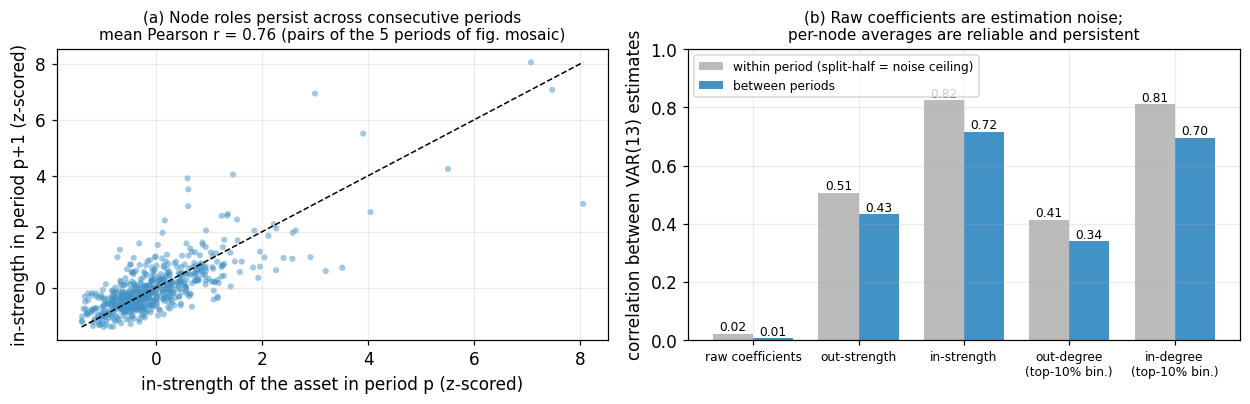

=== CAPTION [fig_2_10_stabilite_roles] ===
Per-asset stability of the VAR(13): the precise wiring is redrawn every period, but node-level roles (in/out-strength) persist


In [35]:
# ── Stabilité des rôles par actif (VAR(13), 10 demi-périodes + 5 périodes) ────
K_ROLES, LAG_ROLES = 5, 13
off = ~np.eye(N, dtype=bool)

def _fit_var_full(a, lag):
    X, Y = a[:-lag], a[lag:]
    Xc = np.column_stack([np.ones(len(X)), X])
    B, *_ = np.linalg.lstsq(Xc, Y, rcond=None)
    return B[1:]

# 10 demi-périodes : 2 par période -> corr intra (= plafond de bruit) vs inter
halves = np.array_split(real.values, 2 * K_ROLES)
A_h = [_fit_var_full(h, LAG_ROLES) for h in halves]

def _corr_wa(vecs):
    C = np.corrcoef(np.stack(vecs))
    intra = np.mean([C[2 * i, 2 * i + 1] for i in range(K_ROLES)])
    inter = np.mean([C[i, j] for i in range(2 * K_ROLES) for j in range(i + 1, 2 * K_ROLES)
                     if i // 2 != j // 2])
    return intra, inter

def _bin(A):
    M = np.where(off, np.abs(A), 0)
    return M > np.quantile(M[off], 0.9)

_quants = {
    'raw coefficients':          [A[off] for A in A_h],
    'out-strength':              [np.where(off, np.abs(A), 0).sum(1) for A in A_h],
    'in-strength':               [np.where(off, np.abs(A), 0).sum(0) for A in A_h],
    'out-degree (top-10% bin.)': [_bin(A).sum(1).astype(float) for A in A_h],
    'in-degree (top-10% bin.)':  [_bin(A).sum(0).astype(float) for A in A_h],
}
rows = []
for name, vecs in _quants.items():
    intra, inter = _corr_wa(vecs)
    rows.append({'quantity': name,
                 'within-period r (noise ceiling)': round(intra, 3),
                 'between-period r': round(inter, 3),
                 'stability inter/intra': round(inter / intra, 2) if intra > 0.05 else np.nan})
tab_roles = pd.DataFrame(rows)
display(tab_roles)
(RAPPORT_DIR / 'tab_2_10_stabilite_roles.csv').write_text(tab_roles.to_csv(index=False))
(RAPPORT_DIR / 'tab_2_10_stabilite_roles.tex').write_text(
    tab_roles.to_latex(index=False, escape=True, float_format=lambda v: f'{v:g}'))
print('  done tab_2_10_stabilite_roles.tex  +  .csv')

# 5 périodes pleines pour le scatter (mêmes bornes que la mosaïque fig_2_9)
bounds = np.linspace(0, len(real), K_ROLES + 1).astype(int)
A_p = [_fit_var_full(real.values[a:b], LAG_ROLES) for a, b in zip(bounds[:-1], bounds[1:])]
S_in = np.stack([np.where(off, np.abs(A), 0).sum(0) for A in A_p])
rs = [np.corrcoef(S_in[p], S_in[p + 1])[0, 1] for p in range(K_ROLES - 1)]

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.5, 4.4))

# (a) scatter : force entrante période p vs p+1 (z-scorée par période)
Z = (S_in - S_in.mean(1, keepdims=True)) / S_in.std(1, keepdims=True)
for p in range(K_ROLES - 1):
    axA.scatter(Z[p], Z[p + 1], s=16, alpha=0.5, color='#4292c6', edgecolors='none')
_l = [Z.min(), Z.max()]
axA.plot(_l, _l, 'k--', lw=1)
axA.set_xlabel('in-strength of the asset in period p (z-scored)')
axA.set_ylabel('in-strength in period p+1 (z-scored)')
axA.set_title(f'(a) Node roles persist across consecutive periods\n'
              f'mean Pearson r = {np.mean(rs):.2f} (pairs of the {K_ROLES} periods of fig. mosaic)',
              fontsize=10)

# (b) intra vs inter par quantité : seul l'agrégat par noeud sort du bruit
x = np.arange(len(tab_roles)); w = 0.38
b1 = axB.bar(x - w / 2, tab_roles['within-period r (noise ceiling)'], w,
             color='#bbbbbb', label='within period (split-half = noise ceiling)')
b2 = axB.bar(x + w / 2, tab_roles['between-period r'], w,
             color='#4292c6', label='between periods')
axB.bar_label(b1, fmt='%.2f', fontsize=8); axB.bar_label(b2, fmt='%.2f', fontsize=8)
axB.set_xticks(x)
axB.set_xticklabels([q.replace(' (top-10% bin.)', '\n(top-10% bin.)') for q in tab_roles['quantity']],
                    fontsize=8)
axB.set_ylabel('correlation between VAR(13) estimates')
axB.set_ylim(0, 1)
axB.set_title('(b) Raw coefficients are estimation noise;\nper-node averages are reliable and persistent', fontsize=10)
axB.legend(fontsize=8)

fig.suptitle('Per-asset stability of the VAR(13): the precise wiring is redrawn every period, '
             'but node-level roles (in/out-strength) persist', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.94])
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_2_10_stabilite_roles'); plt.show()
if _capt:
    print('=== CAPTION [fig_2_10_stabilite_roles] ==='); print(' | '.join(_capt))

## Annexe — Sparse VAR: stability of the active edges across chunks

The series is split into `n_chunks` consecutive chunks; on each chunk a **sparse lagged VAR**
(lag = 13) is fitted: only the entries whose lagged correlation |C_ij| exceeds the quantile `q`
are used as predictors. For each edge we measure its **activation frequency F** = fraction of
chunks where it is selected. Each panel shows the distribution of F (log scale) with the mean
in-sample R² and its white-noise expectation E[R²] = k/(n-1). The black curve is the count
expected **under pure chance** (each chunk drawing its active edges at random: F ~ Bin(n_chunks, p_sel)/n_chunks):
the observed distributions are essentially indistinguishable from random turnover — contagion
links do **not** persist from one period to the next, apart from a handful of same-sector pairs
(META–AMZN, HD–LOW, …).

  done fig_A1_sparse_var_activation.pdf  +  fig_A1_sparse_var_activation.png


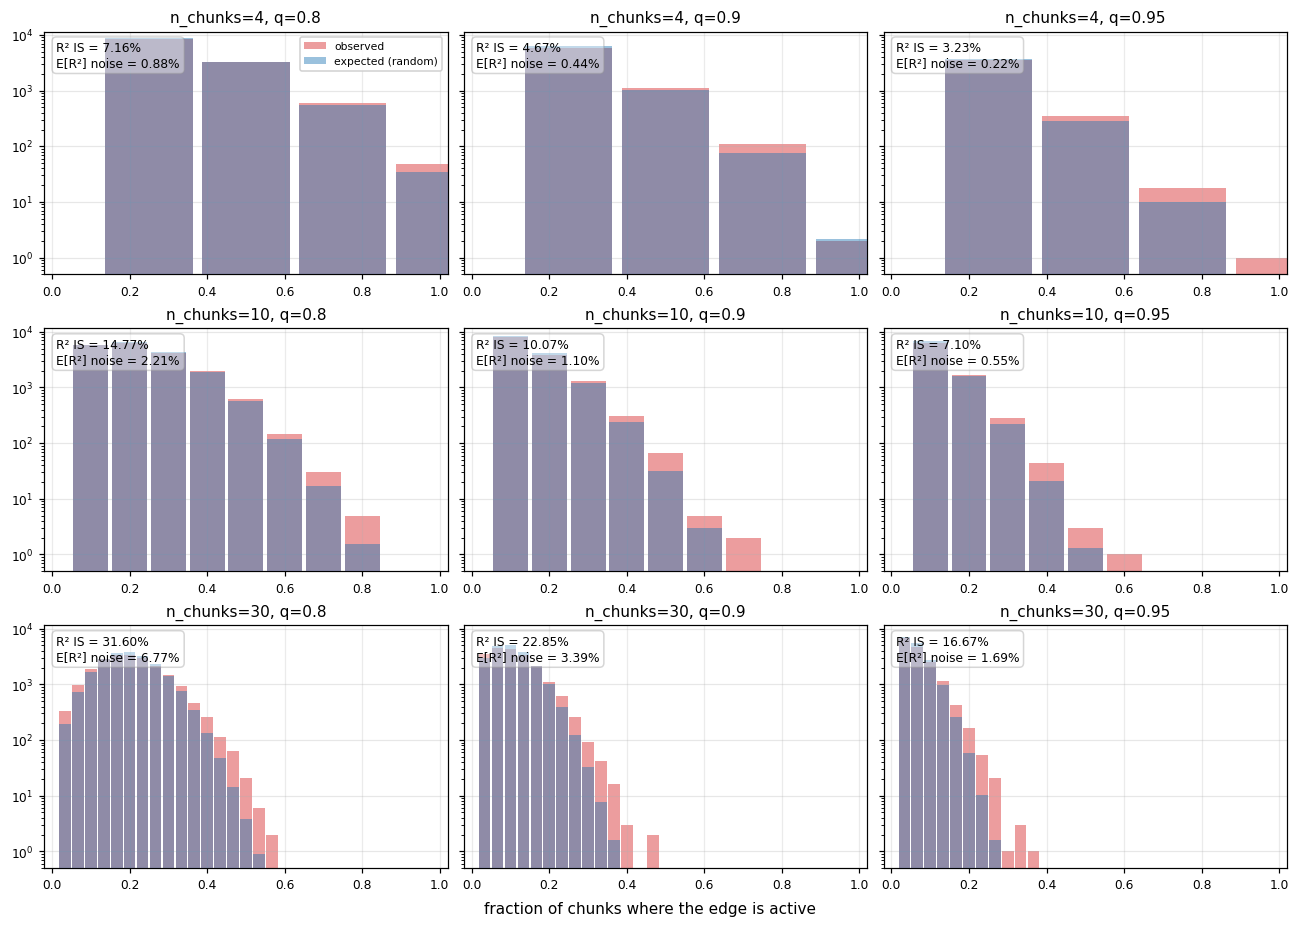

=== CAPTION [fig_A1_sparse_var_activation] ===
Sparse VAR: distribution of the edge activation frequency F, per (n_chunks, q)


In [36]:
from networks import correlation
from scipy.stats import binom

def fit_sparse_chunk(arr, lag, q):
    """Mask top-(1-q) on |C_lag|, OLS on the selected predictors only.
    Returns (A_cst, mask, r2_per_target, r2_null_per_target).
    """
    T_, N_ = arr.shape
    n = T_ - lag
    X_lag, Y_now = arr[:-lag], arr[lag:]
    C = correlation(arr, lag=lag)
    thr = np.quantile(np.abs(C), q)
    mask = np.abs(C) > thr
    A_cst = np.zeros((N_, N_))
    resid = np.empty((n, N_))
    n_active = mask.sum(axis=0)        # number of predictors per target
    for j in range(N_):
        active = np.where(mask[:, j])[0]
        if active.size == 0:
            resid[:, j] = Y_now[:, j] - Y_now[:, j].mean()
            continue
        X_j = np.column_stack([np.ones(n), X_lag[:, active]])
        b, *_ = np.linalg.lstsq(X_j, Y_now[:, j], rcond=None)
        A_cst[active, j] = b[1:]
        resid[:, j] = Y_now[:, j] - X_j @ b
    ss_res = (resid**2).sum(0)
    ss_tot = ((Y_now - Y_now.mean(0))**2).sum(0)
    r2 = 1 - ss_res / np.where(ss_tot > 0, ss_tot, 1)
    # E[R² | white noise] = (k-1)/(T-1)  with k = n_active + 1
    r2_null = n_active / (n - 1)
    return A_cst, mask, r2, r2_null

LAG_SPARSE    = 13
N_CHUNKS_LIST = [4, 10, 30]
Q_LIST        = [0.80, 0.90, 0.95]

sweep = {}
for n_c in N_CHUNKS_LIST:
    chunks = np.array_split(real.values, n_c)
    for q in Q_LIST:
        r2s, r2_nulls, masks_list = [], [], []
        for ch in chunks:
            A_cst, mask, r2, r2_null = fit_sparse_chunk(ch, LAG_SPARSE, q)
            r2s.append(r2.mean()); r2_nulls.append(r2_null.mean())
            masks_list.append((A_cst != 0).astype(int))
        F = np.stack(masks_list, axis=0).mean(0)
        p_sel = float(np.mean([m.mean() for m in masks_list]))   # selection probability per chunk
        sweep[(n_c, q)] = {'F': F, 'r2': np.mean(r2s), 'r2_null': np.mean(r2_nulls),
                           'p_sel': p_sel}

# Grid of the F distributions (in-sample R² and white-noise baseline in the box)
fig, axes = plt.subplots(len(N_CHUNKS_LIST), len(Q_LIST),
                         figsize=(3.9*len(Q_LIST), 2.8*len(N_CHUNKS_LIST)),
                         constrained_layout=True, sharey=True)
for i, n_c in enumerate(N_CHUNKS_LIST):
    for j, q in enumerate(Q_LIST):
        ax = axes[i, j]
        s = sweep[(n_c, q)]
        F_vu = s['F'][s['F'] > 0]
        xs = np.arange(1, n_c + 1) / n_c
        counts = [int(np.isclose(F_vu, x).sum()) for x in xs]
        bar_label = (f'R² IS = {s["r2"]*100:.2f}%\n'
                     f'E[R²] noise = {s["r2_null"]*100:.2f}%')
        ax.bar(xs, counts, width=0.9/n_c, color='#d62728', alpha=0.45,
               edgecolor='none', label='observed' if (i == 0 and j == 0) else None)
        # expected under pure chance: each chunk draws its edges at random → F ~ Bin(n_c, p_sel)
        ks = np.arange(1, n_c + 1)
        attendu = N * N * binom.pmf(ks, n_c, s['p_sel'])
        ax.bar(xs, attendu, width=0.9/n_c, color='#1f77b4', alpha=0.45,
               edgecolor='none', zorder=3, label='expected (random)')
        ax.set_yscale('log')
        ax.set_ylim(bottom=0.5)
        if i == 0 and j == 0:
            ax.legend(fontsize=7, loc='upper right', framealpha=0.9)
        ax.set_title(f'n_chunks={n_c}, q={q}', fontsize=10)
        ax.text(0.03, 0.96, bar_label, transform=ax.transAxes, ha='left', va='top',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.35', fc='white',
                                      ec='0.6', alpha=0.4))
        ax.grid(alpha=0.3, axis='y')
        ax.set_xlim(-0.02, 1.02)
        ticks = np.linspace(0, 1, 6)
        ax.set_xticks(ticks)
        ax.set_xticklabels([f'{t:.1f}' for t in ticks])
        ax.tick_params(labelsize=8)

fig.suptitle('Sparse VAR: distribution of the edge activation frequency F, per (n_chunks, q)',
             fontsize=12)
fig.supxlabel('fraction of chunks where the edge is active', fontsize=10)
_sup = getattr(fig, '_suptitle', None)
_capt = [_sup.get_text()] if _sup and _sup.get_text() else []
if _sup: _sup.set_text('')
save(fig, 'fig_A1_sparse_var_activation'); plt.show()
if _capt:
    print('=== CAPTION [fig_A1_sparse_var_activation] ==='); print('\n'.join(_capt))

## Summary of generated files

In [37]:
print(f'{len(_saved)} figures saved into {RAPPORT_DIR.resolve()} (PDF + PNG 300 dpi):\n')
for n in _saved:
    print(f'  - {n}.pdf / .png')


if _saved_tables:
    print(f'\n{len(_saved_tables)} tables saved (LaTeX + CSV):\n')
    for n in _saved_tables:
        print(f'  - {n}.tex / .csv')


31 figures saved into /home/farmachidi/projects/contagion_stock_markets/Fig/rapport (PDF + PNG 300 dpi):

  - fig_1_1_heatmap_correlations.pdf / .png
  - fig_1_1_heatmap_correlations_multi.pdf / .png
  - fig_1_2_scalefree_degres.pdf / .png
  - fig_2_1_matrices_var.pdf / .png
  - fig_2_1_eigenvalues.pdf / .png
  - fig_2_1_R2_modeles.pdf / .png
  - fig_2_2_bic_lag.pdf / .png
  - fig_2_6_liens_recurrents.pdf / .png
  - fig_2_7_liens_recurrents_lag1.pdf / .png
  - fig_2_8_stabilite_var.pdf / .png
  - fig_2_9_matrices_var_chunks.pdf / .png
  - fig_3_sis_scatter.pdf / .png
  - fig_2_0_crisis_detection.pdf / .png
  - fig_3_sis_trajectoires.pdf / .png
  - fig_3_br_scan_r2agg.pdf / .png
  - fig_4_1_clustering_crises.pdf / .png
  - fig_4_2_network_signals.pdf / .png
  - fig_4_3_br_grid_methods.pdf / .png
  - fig_4_4_sis_off_crisis.pdf / .png
  - fig_4_4b_r2_hist_offcrisis.pdf / .png
  - fig_4_5_method_agreement.pdf / .png
  - fig_4_6_community_crisis_ratio.pdf / .png
  - fig_4_7_community_graphs